# Documentation

This Jupyter Notebook analyzes electrophysiological and biophysical features of neuronal data. It includes data loading, preprocessing, clustering, visualization, and statistical testing. Key variables and color palettes are defined for consistent plotting. The workflow covers waveform analysis, feature extraction, clustering (UMAP + Louvain), significance tests, and advanced dimensionality reduction (PCA, CCA, MANOVA). Results are visualized using violin plots, radar plots, heatmaps, and joint plots. All figures are saved to the specified `savepath`.

In [ ]:
#@title imports 
import os
import pickle
# from jedi import settings
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler
# import umap.plot as uplot
import sys  

sys.path.append('C:/Users/Nishant Joshi/Downloads/Old_code/repo/single_cell_analysis/scripts')
from utils import *
sys.path.append(os.getcwd()+'/../scripts/')
from UMAP_utils import *
sys.path.append('C:/Users/Nishant Joshi/Model_fitting/GIFFittingToolbox/src/examples/')
from cluster_stability import *

c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:

def binarize_EI_labels(labels, e_vals):
    temp_labels = labels
    for idx,vals in enumerate(labels):
        if vals in e_vals:
            temp_labels[idx] =1
        else:
            temp_labels[idx] =0 

    return temp_labels



In [3]:
savepath = 'D:/Data For Publication/figures/part2/'

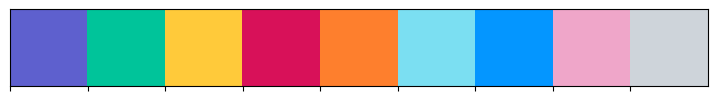

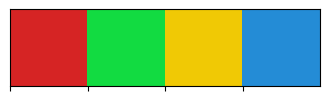

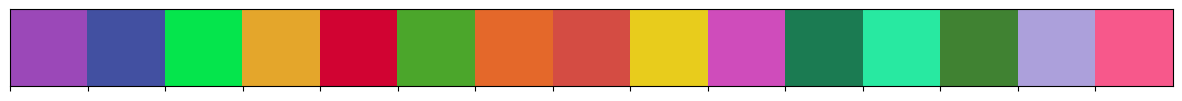

In [4]:
pal = ["#00202e","#003f5c","#2c4875","#8a508f","#bc5090","#ff6361","#ff8531","#ffa600","#ffd380",[0.969,	0.349, 0.549]]
CUSTOM_PAL_SORT_3 = ['#5e60ce','#00c49a','#ffca3a','#D81159','#fe7f2d','#7bdff2','#0496ff','#efa6c9','#ced4da']
GMM_PAL = ['#d62424','#12db41','#f0c905','#248cd6']

# In RGB form
coherence_colors = [[0.609, 0.283, 0.724],
                    [0.259,	0.314, 0.635],
                    [0.02,	0.9, 0.3],
                    [0.898,	0.654, 0.169],
                    [0.821, 0.012, 0.198],
                    [0.298,	0.654, 0.169],
                    [0.898,	0.41 , 0.165],  
                    [0.834,	0.3 , 0.265],
                    [0.912,	0.8 , 0.112],
                    [0.812,	0.3 , 0.734],
                    [0.109, 0.483, 0.324],
                    [0.159,	0.914, 0.635],
                    [0.251,	0.512, 0.198],
                    [0.676,	0.631, 0.859],
                    [0.969,	0.349, 0.549],]
sns.palplot(CUSTOM_PAL_SORT_3)
sns.palplot(GMM_PAL)
sns.palplot(coherence_colors)

# Waveforms

In [5]:
discarded_exps = ['xuan_151118_E1',
'xuan_15319_E1' ,
'xuan_20919_E2',
'xuan_27919_E1',
'xuan_27919_E2',
'xuan_27919_E3',
'NC_20717_E5' ,
'NC_25717_E2',
'payam_31019_E5',
'payam_101019_E5',
'NC_24717_E1']

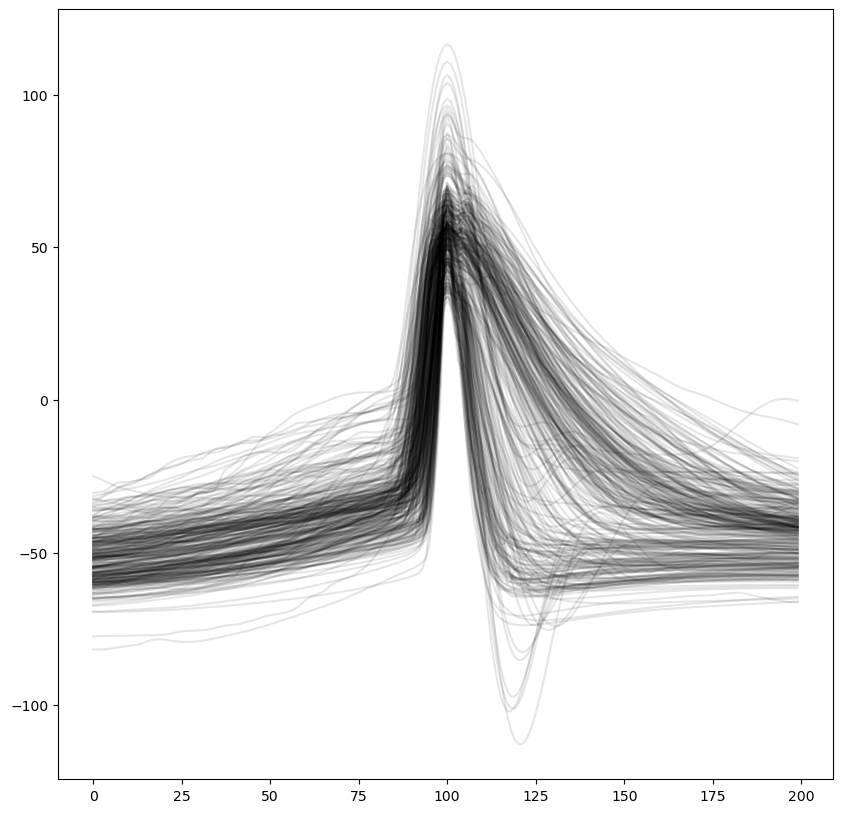

In [6]:
# %matplotlib widget
# feature_path = "D:/FN_analysed_feat_set/"
feature_path = "G:/My Drive/Data For Publication/FN_analysed_feat_set/"   
ephys = pd.read_pickle(feature_path+"Ephys_collection_all_exps_all_conds_spikes_calculated_5ms.pkl")
ephys = ephys[~ephys.exp_name.isin(discarded_exps)]


data_ephys_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][ephys.columns[1:]]
data_ephys_FN_acsf = data_ephys_FN_acsf[data_ephys_FN_acsf.trialnr==0]

data_wave_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][['waveform','tau', 'exp_name', 'cond', 'trialnr']]
data_wave_FN_acsf=data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]
# data_wave_FN_acsf.drop_duplicates('exp_name')

# exps_with_double_trials = np.array(data_wave_FN_acsf.exp_name)[list(np.where(np.unique(data_wave_FN_acsf.exp_name,return_counts=True)[1]>1)[0])]
# data_wave_FN_acsf = data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]

fig,ax = plt.subplots(figsize=[10,10])
# plt.ion
plt.plot(np.vstack(data_wave_FN_acsf['waveform']).T,c='k',alpha=0.1)
# plt.xticks([])
# plt.yticks([]) 
# plt.savefig(savepath+'waves_all_entire_trial.pdf',dpi=200)
plt.show()

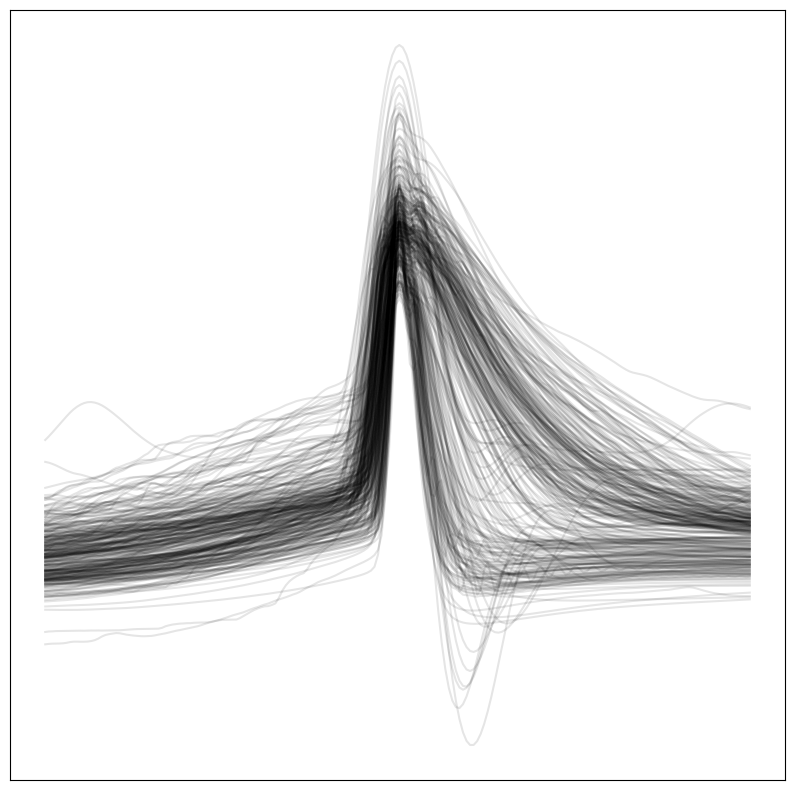

In [13]:
data_first = pd.read_pickle(feature_path+'Ephys_collection_all_exps_all_conds_first_spks_calculated.pkl')
data_second = pd.read_pickle(feature_path+'Ephys_collection_all_exps_all_conds_second_spks_calculated.pkl')


data_first = data_first[~data_first.exp_name.isin(discarded_exps)]
data_second = data_second[~data_second.exp_name.isin(discarded_exps)]


data_ephys_FN_acsf_first = data_first[data_first.cond.isin(['acsf','acsf_bic'])][data_first.columns[1:]]
data_ephys_FN_acsf_first = data_ephys_FN_acsf_first[data_ephys_FN_acsf_first.trialnr==0]
data_wave_FN_acsf_first  = data_first[data_first.cond.isin(['acsf','acsf_bic'])][['waveform','tau', 'exp_name', 'cond', 'trialnr']]
data_wave_FN_acsf_first  = data_wave_FN_acsf_first[data_wave_FN_acsf_first.trialnr==0]
data_wave_FN_acsf_first.drop_duplicates('exp_name')

fig,ax = plt.subplots(figsize=[10,10])
# plt.ion
plt.plot(np.vstack(data_wave_FN_acsf_first['waveform']).T,c='k',alpha=0.1)
plt.xticks([])
plt.yticks([])
# plt.savefig(savepath+'waves_all_first_half.pdf',dpi=200)

plt.show()


c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


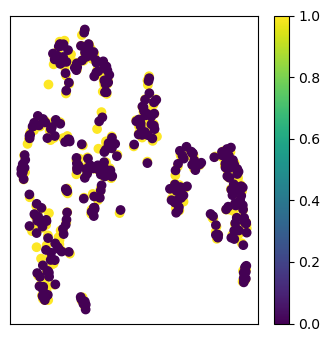

In [16]:
fn_numpy1 = normalize(np.vstack(data_wave_FN_acsf_first['waveform'].to_numpy()))
fn_numpy2 = normalize(np.vstack(data_wave_FN_acsf['waveform'].to_numpy()))

all = np.vstack([fn_numpy1,fn_numpy2]) 
# all_vert = np.hstack([fn_numpy1,fn_numpy2]) 
plot_UMAP_values(all,np.hstack([np.ones(len(fn_numpy1)),np.zeros(len(fn_numpy2))]),random_state=42,savepath=savepath+'wave_firstHalf_vs_entire.pdf',save=False)

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


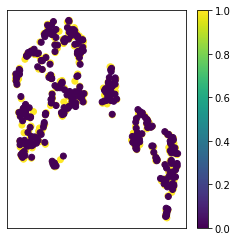

In [10]:
fn_numpy1 = normalize(np.vstack(data_wave_FN_acsf_first['waveform'].to_numpy()))
fn_numpy2 = normalize(np.vstack(data_wave_FN_acsf['waveform'].to_numpy()))

all = np.vstack([fn_numpy1,fn_numpy2]) 
# all_vert = np.hstack([fn_numpy1,fn_numpy2]) 
plot_UMAP_values(all,np.hstack([np.ones(len(fn_numpy1)),np.zeros(len(fn_numpy2))]),random_state=42,savepath=savepath+'wave_firstHalf_vs_entire.pdf',save=True)

c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


8


c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


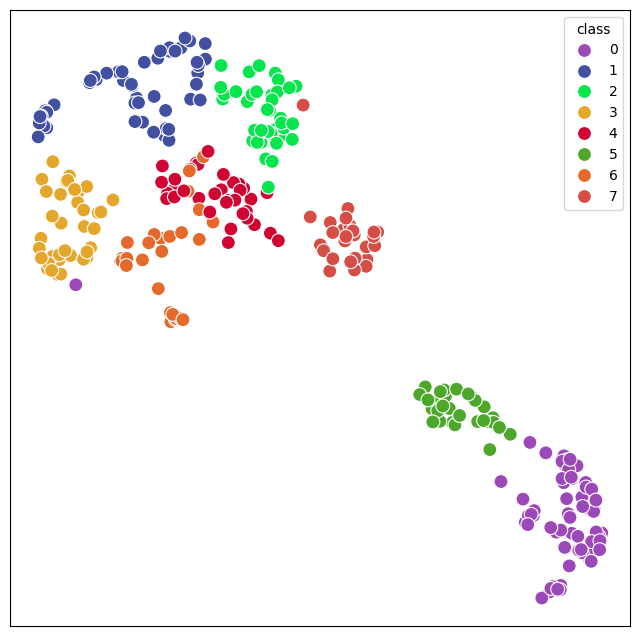

C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_27524\3016627158.py:15: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data_wave_FN_acsf_first.labels_wave = labels_wave


In [19]:
waves_first = normalize(np.vstack(data_wave_FN_acsf_first['waveform']))

labels_wave,mapper,reducer = plot_UMAP_clusters_single(waves_first,
                          20,
                          0.1,
                          random_state =42,
                          res_louvain = 1.,
                          c_list =coherence_colors,
                          norm=False,
                          size=100,
                          save= False,
                          savepath = savepath+'wave_cluster_first_half.pdf')

# waves_second = normalize(np.vstack(data_wave_FN_acsf_second['waveform']))
data_wave_FN_acsf_first.labels_wave = labels_wave



c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


8


c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


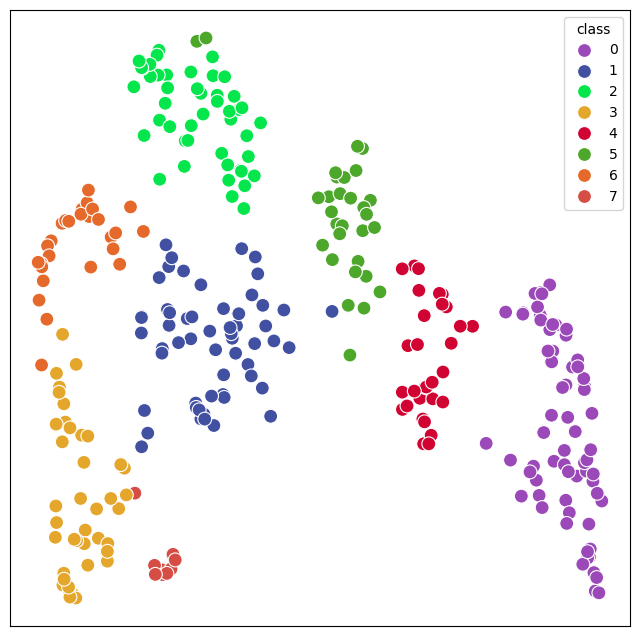

In [20]:
waves = normalize(np.vstack(data_wave_FN_acsf['waveform']))

labels_wave,mapper,reducer = plot_UMAP_clusters_single(waves,
                          20,
                          0.1,
                          random_state =42,
                          res_louvain = 1.,
                          c_list =coherence_colors,
                          norm=False,
                          save=False,
                          savepath = savepath+'wave_cluster.pdf',
                          size=100
                          )
data_wave_FN_acsf['labels_wave'] = labels_wave

In [21]:
waves_scaler = StandardScaler()
# find_optimum_res(waves_scaler.fit_transform(waves),save=True,savepath=savepath+'waves_cluster_stability.pdf')

0


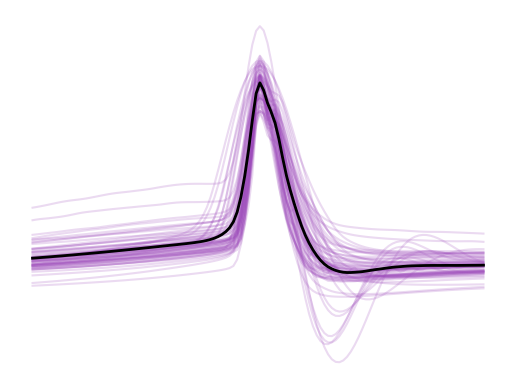

1


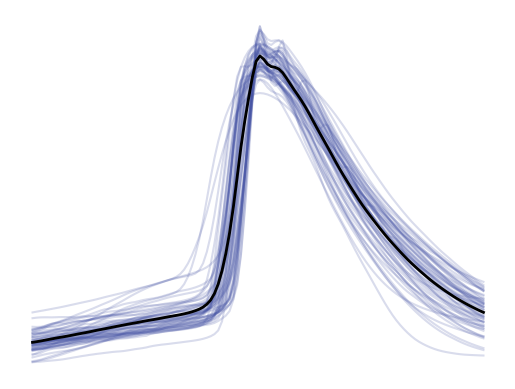

2


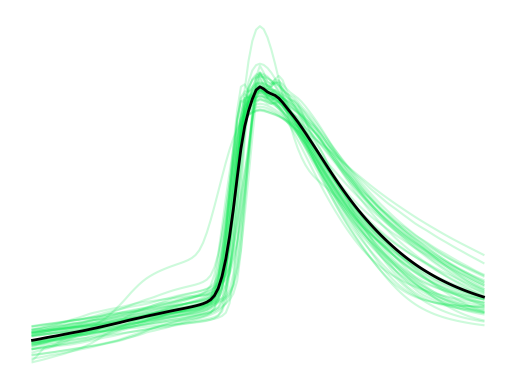

3


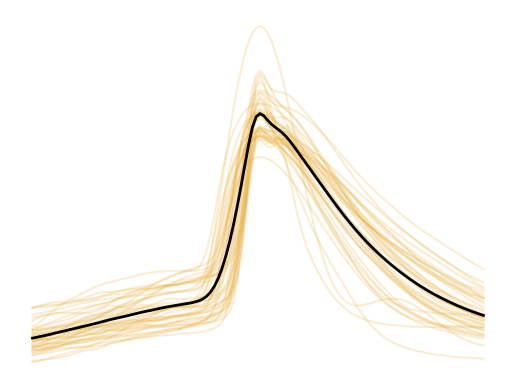

4


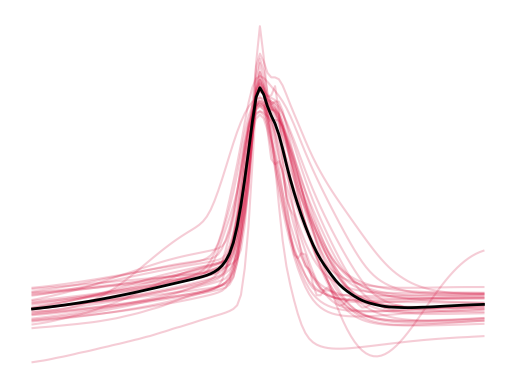

5


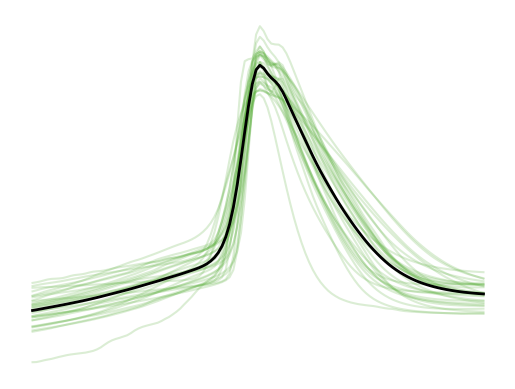

6


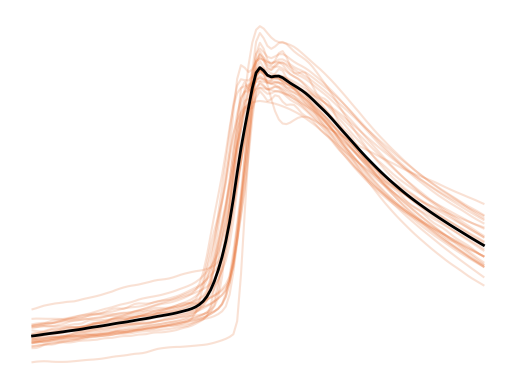

7


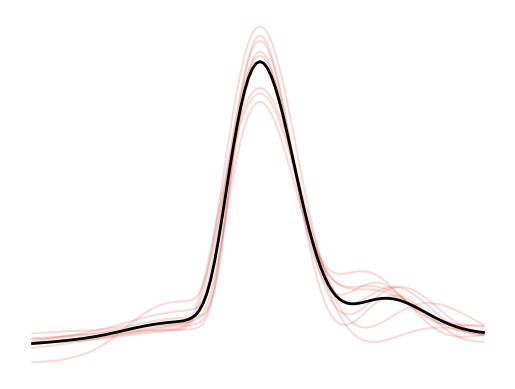

In [22]:
for i in set(labels_wave):
    print(i)
    t = np.arange(0,6,1/20)
    fig,ax = plt.subplots()
    fig.patch.set_visible(False)
    ax.axis('off')
    # data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==i]['half_width']
    wave_i = np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==i]['waveform']).T
    plt.plot(t,wave_i[-int(8*20):int(-2*20),:],c=coherence_colors[i],alpha=0.2)
    plt.plot(t,np.mean(wave_i,axis=1)[-int(8*20):int(-2*20)],c='black',linewidth=2,label=i)
    plt.xticks([])
    plt.yticks([])
    # plt.savefig(savepath+'wave_'+str(i)+'.pdf',dpi=200)
    plt.show()
# plt.legend()

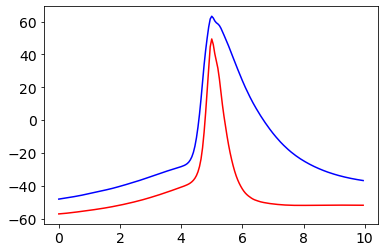

In [72]:
plt.plot(np.arange(0,10,1/20),np.mean(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave.isin([0,4,5])]['waveform']).T,axis=1),c='red')
plt.plot(np.arange(0,10,1/20),np.mean(np.vstack(data_wave_FN_acsf[~data_wave_FN_acsf.labels_wave.isin([0,4,5])]['waveform']).T,axis=1),c='blue')
plt.savefig(savepath+'average_waveform.pdf',dpi=200)

## Significance test

<Axes: >

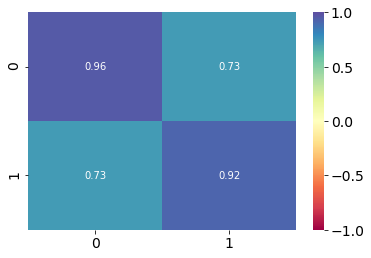

In [379]:
from sklearn.metrics.pairwise import cosine_similarity

data_wave_FN_acsf.labels_wave = binarize_EI_labels(np.array(data_wave_FN_acsf.labels_wave),[1,2,3,6,7])
wave_exc = data_wave_FN_acsf[data_wave_FN_acsf.labels_wave.isin([1,2,3,6,7])]
wave_inh = data_wave_FN_acsf[data_wave_FN_acsf.labels_wave.isin([0,5,4])]

cosine_mat = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        cosine_mat[i,j] = np.mean(cosine_similarity(normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==i]['waveform'].to_numpy())),
                  normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==j]['waveform'].to_numpy()))))

sns.heatmap(cosine_mat,vmax=1,vmin=-1,annot=True,cmap = 'Spectral')
# plt.savefig(savepath+'EI_similarity.pdf',dpi=200)

In [380]:
from statsmodels.stats.libqsturng import qsturng, psturng
# from hypothetical.descriptive import var
from itertools import combinations
def games_howell(*args,alpha=0.05):
    alpha = 0.05
    k = len(args)

    group_means =    [np.mean(i) for i in args]
    group_obs =      [len(i) for i in args]
    group_variance = [np.var(i) for i in args]

    combs = list(combinations(np.arange(3),2))

    group_comps = []
    mean_differences = []
    degrees_freedom = []
    t_values = []
    p_values = []
    std_err = []
    up_conf = []
    low_conf = []

    for comb in combs:
        # Mean differences of each group combination
        diff = group_means[comb[1]] - group_means[comb[0]]
        
        # t-value of each group combination
        t_val = np.abs(diff) / np.sqrt((group_variance[comb[0]] / group_obs[comb[0]]) + 
                                    (group_variance[comb[1]] / group_obs[comb[1]]))
        
        # Numerator of the Welch-Satterthwaite equation
        df_num = (group_variance[comb[0]] / group_obs[comb[0]] + group_variance[comb[1]] / group_obs[comb[1]]) ** 2
        
        # Denominator of the Welch-Satterthwaite equation
        df_denom = ((group_variance[comb[0]] / group_obs[comb[0]]) ** 2 / (group_obs[comb[0]] - 1) +
                    (group_variance[comb[1]] / group_obs[comb[1]]) ** 2 / (group_obs[comb[1]] - 1))
        
        # Degrees of freedom
        df = df_num / df_denom
        
        # p-value of the group comparison
        p_val = psturng(t_val * np.sqrt(2), k, df)

        # Standard error of each group combination
        se = np.sqrt(0.5 * (group_variance[comb[0]] / group_obs[comb[0]] + 
                            group_variance[comb[1]] / group_obs[comb[1]]))
        
        # Upper and lower confidence intervals
        upper_conf = diff + qsturng(1 - alpha, k, df)
        lower_conf = diff - qsturng(1 - alpha, k, df)
        
        # Append the computed values to their respective lists.
        mean_differences.append(diff)
        degrees_freedom.append(df)
        t_values.append(t_val)
        p_values.append(p_val)
        std_err.append(se)
        up_conf.append(upper_conf)
        low_conf.append(lower_conf)
        group_comps.append(str(comb[0]) + ' : ' + str(comb[1]))
    return pd.DataFrame({'mean_differences':mean_differences,'degrees_freedom':degrees_freedom,'t_values':t_values,'p_values':p_values,'std_err':std_err,'up_conf':up_conf,'low_conf':low_conf,'group_comps':group_comps})

In [383]:
import numpy as np
from scipy.stats import f_oneway
import statsmodels.api as sm
def calcualte_cosine_sig(data1,data2,data3):
    return sm.stats.anova_oneway([data1,data2,data3])

data1 = cosine_similarity(normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==0]['waveform'].to_numpy())),
                  normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==0]['waveform'].to_numpy())))
data1 = data1[np.tril_indices_from(data1,k=1)]
data2 = cosine_similarity(normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==1]['waveform'].to_numpy())),
                  normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==1]['waveform'].to_numpy())))
data2 = data2[np.tril_indices_from(data2,k=1)]
data3 = cosine_similarity(normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==1]['waveform'].to_numpy())),
                  normalize(np.vstack(data_wave_FN_acsf[data_wave_FN_acsf.labels_wave==0]['waveform'].to_numpy())))
data3 = data3.reshape(1,-1)[0]


print(calcualte_cosine_sig(data1,data2,data3))

statistic = 19148.005542600265
pvalue = 0.0
df = (2.0, 32096.94365369221)
df_num = 2.0
df_denom = 32096.94365369221
nobs_t = 49138.0
n_groups = 3
means = [0.95994265 0.91641193 0.7311218 ]
nobs = [ 8126. 17576. 23436.]
vars_ = [0.00158343 0.00561306 0.02768931]
use_var = unequal
welch_correction = True
tuple = (19148.005542600265, 0.0)


In [384]:
games_howell(data1,data2,data3)


,mean_differences,degrees_freedom,t_values,p_values,std_err,up_conf,low_conf,group_comps
0,-0.043531,25239.880467,60.707122,0.001,0.000507,3.271166,-3.358227,0 : 1
1,-0.228821,29488.685313,195.048921,0.001,0.000830,3.085847,-3.543489,0 : 2
2,-0.185290,34459.036546,151.249598,0.001,0.000866,3.129353,-3.499933,1 : 2


# Electrophysiology

In [60]:
data_ephys_FN_acsf['labels_wave'] = np.int16(labels_wave)

In [12]:
data_ephys_FN_acsf.to_pickle("D:/Data For Publication/CCA/ephys_with_labels.p")

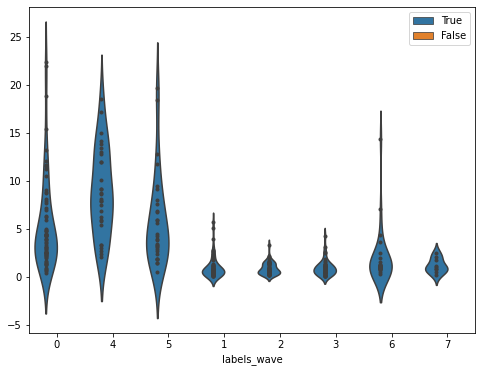

In [13]:
fig,ax = plt.subplots(figsize = [8,6])
# sns.violinplot(x=data_ephys_FN_acsf["labels_wave"], y=np.array(data_ephys_FN_acsf["fr"],dtype=np.float32),
#                order=[0,4,5,1,2,3,6,7],
#                width=1.5,
#                split=True,
#                inner="point")

ax = sns.violinplot(x=data_ephys_FN_acsf["labels_wave"], y=np.array(data_ephys_FN_acsf["fr"],dtype=np.float32), 
                    hue=True,
                    order=[0,4,5,1,2,3,6,7],
                    hue_order=[True, False], 
                    # split=True,
                    inner="point",
                    )
plt.savefig(savepath+'fr_vs_cluster.pdf',dpi=200)

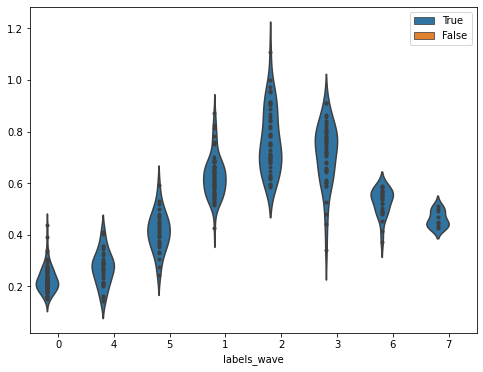

In [14]:
fig,ax = plt.subplots(figsize = [8,6])

ax = sns.violinplot(x=data_ephys_FN_acsf["labels_wave"], y=np.array(data_ephys_FN_acsf["mean_width"],dtype=np.float32), 
                    hue=True,
                    order=[0,4,5,1,2,3,6,7],
                    hue_order=[True, False], 
                    # split=True,
                    inner="point",
                    )
plt.savefig(savepath+'ap_widths.pdf',dpi=200)

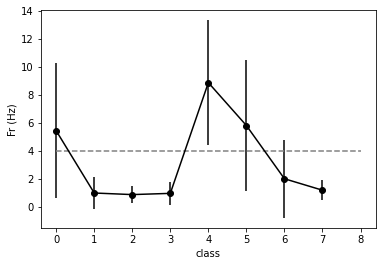

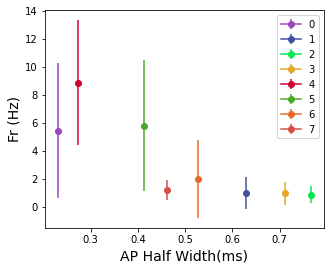

In [15]:
frs = []
ap_width = []  
frs_std = []
ap_width_std = []

for i in set(data_ephys_FN_acsf['labels_wave']):
    frs.append(np.mean(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==i]['fr']))
    frs_std.append(np.std(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==i]['fr']))

    ap_width.append(np.mean(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==i]['mean_width']))
    ap_width_std.append(np.std(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==i]['mean_width']))

plt.errorbar(list(set(data_ephys_FN_acsf['labels_wave'])),frs,yerr=frs_std,marker='o',c='black')
plt.hlines(4,0,8,linestyles='dashed',color='grey')
plt.ylabel('Fr (Hz)')
plt.xlabel('class')
plt.show()
fig,ax = plt.subplots(figsize = [5,4])
for i in range(len(ap_width)):
    ax.errorbar(ap_width[i],frs[i],marker='o',yerr=frs_std[i],c=coherence_colors[i],label = list(set(data_ephys_FN_acsf['labels_wave']))[i])
    ax.set_ylabel('Fr (Hz)',fontsize=14)
    
    ax.set_xlabel('AP Half Width(ms)',fontsize=14)
    ax.legend()

# plt.savefig(savepath+'AP_width_vs_FR.pdf')
# plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


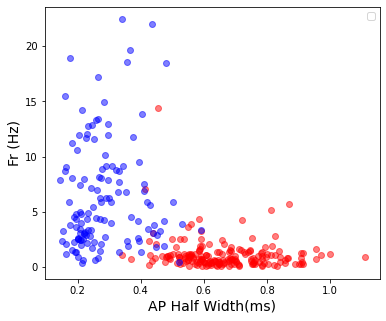

In [16]:
# plt.scatter(frs_inh,ap_width_inh)

plt.rcParams.fontsize=14
frs_inh = data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave.isin([0,4,5])]['fr']
ap_width_inh = data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave.isin([0,4,5])]['mean_width']

frs_exc = data_ephys_FN_acsf[~data_ephys_FN_acsf.labels_wave.isin([0,4,5])]['fr']
ap_width_exc = data_ephys_FN_acsf[~data_ephys_FN_acsf.labels_wave.isin([0,4,5])]['mean_width']
fig,ax = plt.subplots(figsize=[6,5])
ax.scatter(ap_width_exc,frs_exc,c='red',alpha=0.5)
ax.scatter(ap_width_inh,frs_inh,c='blue',alpha=0.5)

ax.set_ylabel('Fr (Hz)',fontsize=14)

ax.set_xlabel('AP Half Width(ms)',fontsize=14)
ax.legend()
plt.savefig(savepath+'fr_ap_scatter.pdf',dpi=200)

<Axes: >

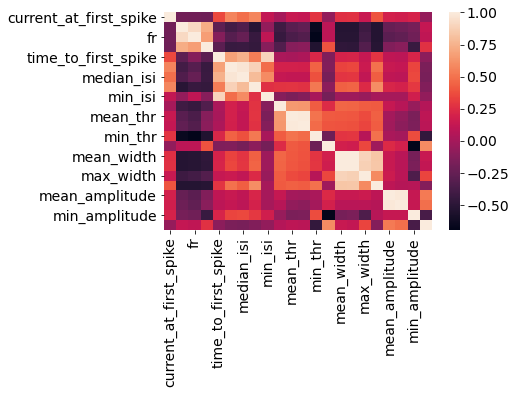

In [74]:
sns.heatmap(data_ephys_FN_acsf[['current_at_first_spike', 'ap_count', 'fr', 'inst_fr',
       'time_to_first_spike', 'mean_isi', 'median_isi', 'max_isi', 'min_isi',
       'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
       'mean_width', 'median_width', 'max_width', 'min_width',
       'mean_amplitude', 'median_amplitude', 'min_amplitude', 'max_amplitude',]].corr())


In [61]:

ephys_exc  = data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave.isin([1,2,3,6,7])]
ephys_inh  = data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave.isin([0,5,4])]
print(len(ephys_exc),len(ephys_inh))



186 126


In [402]:
[print(i,len(ephys_exc[ephys_exc.labels_wave == i])) for i in set(ephys_exc.labels_wave)]

[print(i, len(ephys_inh[ephys_inh.labels_wave == i])) for i in set(ephys_inh.labels_wave)]

1 58
2 48
3 44
6 27
7 9
0 66
4 30
5 30


[None, None, None]

In [ ]:
cols =  data_ephys_FN_acsf.columns[:-6]
data_umap_scaler = StandardScaler()

find_optimum_res(data_umap_scaler.fit_transform(normalize(ephys_exc[cols].to_numpy())),save=True,savepath=savepath+'exc_ephys_cluster_stability.pdf')
find_optimum_res(data_umap_scaler.fit_transform(normalize(ephys_inh[cols].to_numpy())),save=True,savepath=savepath+'inh_ephys_cluster_stability.pdf')

In [64]:
cols_temp = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr','time_to_first_spike',
             'mean_isi', 'median_isi', 'max_isi', 'min_isi',
             'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
             'mean_width', 'median_width', 'max_width', 'min_width',
             'mean_amplitude', 'median_amplitude', 'min_amplitude']

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


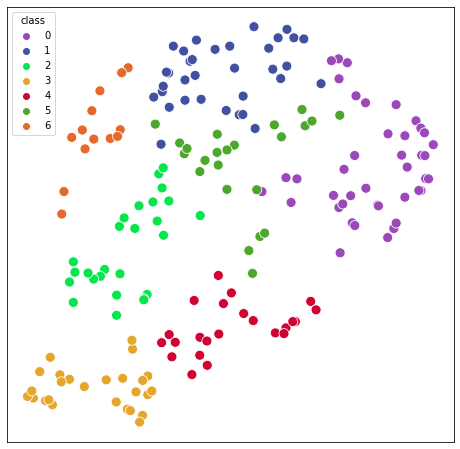

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


6


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


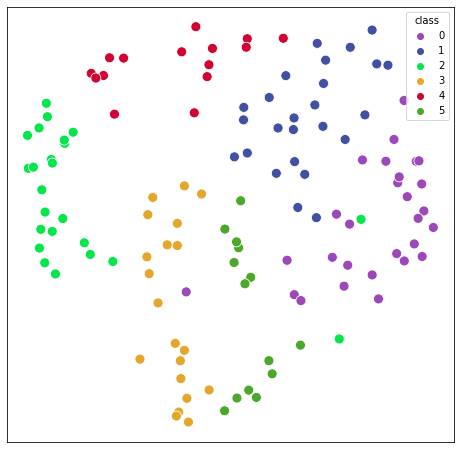

<ipython-input-65-26105392d31f>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ephys_exc['labels_ephys'] = lables_ephys_exc
<ipython-input-65-26105392d31f>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ephys_inh['labels_ephys'] = lables_ephys_inh


In [65]:
cols =  data_ephys_FN_acsf.columns[:-6]
ephys_data = normalize(np.vstack(ephys_exc[cols_temp].to_numpy()),axis=0)

lables_ephys_exc,mapper,reducer = plot_UMAP_clusters_single(ephys_data,
                                                            20,
                                                            0.1,
                                                            random_state =42,
                                                            res_louvain = 1.,
                                                            c_list =coherence_colors,
                                                            norm=False,
                                                            size=100,
                                                            save = False,
                                                            savepath = savepath+'exc_ephys_cluster.pdf'
                                                            )

ephys_data = normalize(np.vstack(ephys_inh[cols_temp].to_numpy()),axis=0)
# rows_to_keep = list(set(random.sample(set(np.arange(0,len(ephys_data))),int(0.8*len(ephys_data)))))

lables_ephys_inh,mapper,reducer = plot_UMAP_clusters_single(ephys_data,
                                                            20,
                                                            0.1,
                                                            random_state =42,
                                                            res_louvain = 1.,
                                                            c_list =coherence_colors,
                                                            norm=False,
                                                            size=100,
                                                            save = False,
                                                            savepath = savepath+'inh_ephys_cluster.pdf'
                                                            )
ephys_exc['labels_ephys'] = lables_ephys_exc
ephys_inh['labels_ephys'] = lables_ephys_inh 

In [430]:
import paxplot
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import normalize

def pax_plot_data(data,cols,labels,pallete,savepath, save= False):
    # # Import data

    scaler_min = MinMaxScaler()
    scaler_std = StandardScaler()
    # scaler_norm = normalize()
    data_to_plot = data
    cols = cols
    labels =  labels
    # Create figure
    paxfig = paxplot.pax_parallel(n_axes=len(cols))
    paxfig.set_figheight(10)
    paxfig.set_figwidth(30)

    scaled_min = scaler_min.fit_transform(data_to_plot.to_numpy())

    scaled_std = scaler_std.fit_transform(data_to_plot.to_numpy())

    scaled_norm = normalize(data_to_plot.to_numpy(),axis=0)

    for i in list(set(labels)):
        idx = np.where(labels==i)
        paxfig.plot(
            scaled_min[idx[0],:], 
            line_kwargs={'alpha': 0.1, 'color': pallete[i], 'zorder': 1}
        )

        paxfig.plot(
            [np.mean(scaled_min[idx[0],:],axis=0)], 
            line_kwargs={'alpha': 1., 'color': pallete[i],'linewidth':2, 'zorder': 1}
        )

    for  ax in paxfig.axes:   
        ax.set_yticks([0,0.5,1])
        ax.tick_params(axis='x', labelsize=20,rotation=90)
        ax.tick_params(axis='y', labelsize=10)
    # # Add labels
    paxfig.set_labels(cols)
    # paxfig.legend()
    if save: 
        plt.savefig(savepath,dpi=300)

    plt.show()

def plot_radar(data,cols,labels,palette=None,figsize=(6, 6),lims=None, logscale=True,plot_neg_log=False,save=False,savepath=None,):
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))

    cols_ = cols
    data_norm = normalize(data[cols_].to_numpy(),axis=0)
    # Data
    categories = cols_
    for i in list(set(labels)):
        idx = labels==i
        values_1 = data_norm[idx,:]

        # Number of variables we're plotting.
        num_vars = len(cols_)

        # Compute angle of each axis.
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

        # The plot is a circle, so we need to "complete the loop".
        # Append the start value to the end.
        values_1 = np.insert(values_1,[values_1.shape[1]],values_1[:,:1],axis=1)
        angles += angles[:1]

        # Create the figure.

        # Draw one axe per variable and add labels.
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        plt.xticks(angles[:-1], categories,fontsize=12,)
        for label, angle in zip(ax.get_xticklabels(), angles):
            x, y = label.get_position()
            label.set_position((x, y-0.2 ))  # Adjust the value to move labels further out

        # Draw ylabels.
        if logscale:
            ax.set_rscale('log')
            ax.plot(angles, values_1.T, linewidth=1,c=palette[i], linestyle='solid',alpha=0.1 )

            ax.plot(angles, np.mean(values_1.T,axis=1), linewidth=3,c=palette[i], linestyle='solid',alpha=.8 )
            ax.set_ylim(lims)
        elif plot_neg_log:
            ax.set_rscale('log')

            ax.plot(angles, values_1.T*-1, linewidth=1,c=palette[i], linestyle='solid',alpha=0.1 )

            ax.plot(angles, np.mean(values_1.T*-1,axis=1), linewidth=3,c=palette[i], linestyle='solid',alpha=.8 )
            ax.set_ylim(lims)
        else:
            # ax.set_rscale('log')

            ax.plot(angles, values_1.T, linewidth=1,c=palette[i], linestyle='solid',alpha=0.1 )

            ax.plot(angles, np.mean(values_1.T,axis=1), linewidth=3,c=palette[i], linestyle='solid',alpha=.8 )
            ax.set_ylim(lims)
    if save:
        plt.savefig(savepath,dpi=200)
    else:
        plt.show()    

In [404]:
cols_spikes   = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr', 'mean_isi', 'median_isi', 'max_isi', 'min_isi',]
cols_thrs     = ['first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',]
cols_wf       = ['mean_width', 'median_width', 'max_width', 'min_width','mean_amplitude', 'median_amplitude', 'min_amplitude', 'max_amplitude',]

## polar exc

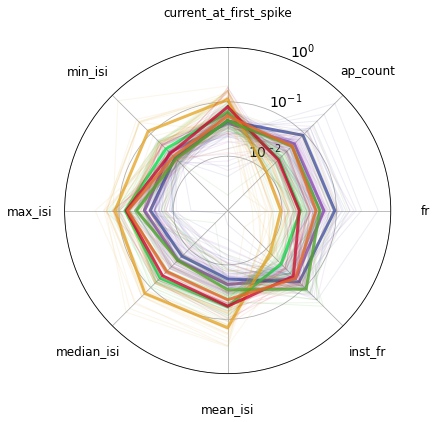

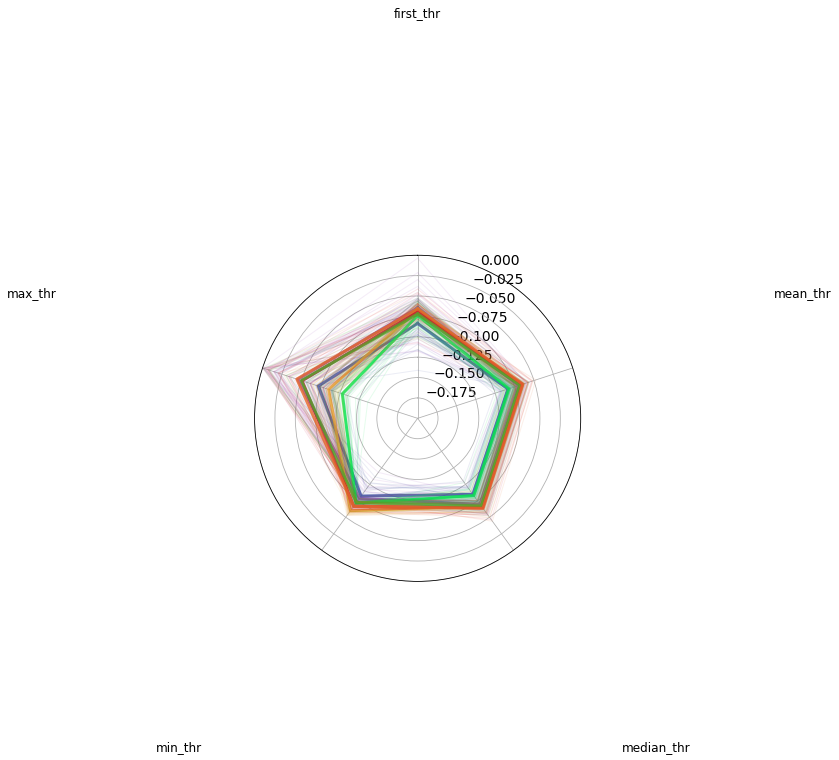

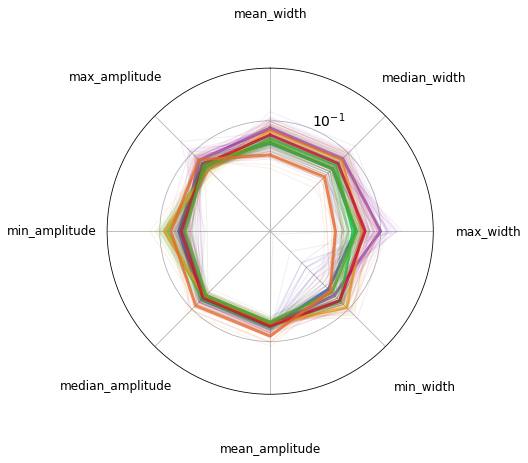

In [431]:
plot_radar(ephys_exc[ephys_exc.columns[:-6]],cols_spikes,ephys_exc['labels_ephys'],lims = (1e-3,1e0) ,palette=coherence_colors,save=False,savepath=savepath+'Exc_FN_spikes_radar.pdf')
plot_radar(ephys_exc[ephys_exc.columns[:-6]],cols_thrs,ephys_exc['labels_ephys']  ,lims = (-0.2,0.0) ,palette=coherence_colors,logscale = False,plot_neg_log=False,save=False,savepath=savepath+'Exc_FN_thrs_radar.pdf')
plot_radar(ephys_exc[ephys_exc.columns[:-6]],cols_wf,ephys_exc['labels_ephys']    ,lims = (1e-2,3e-1),palette=coherence_colors,save=False,savepath=savepath+'Exc_FN_wave_radar.pdf')

## polar inhibitory

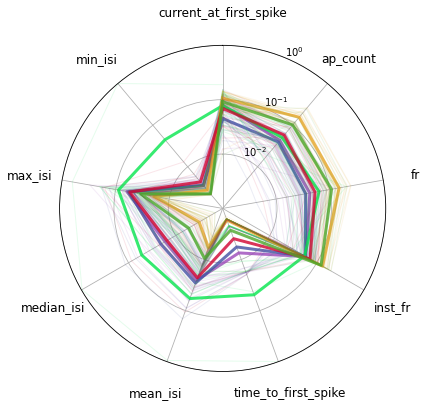

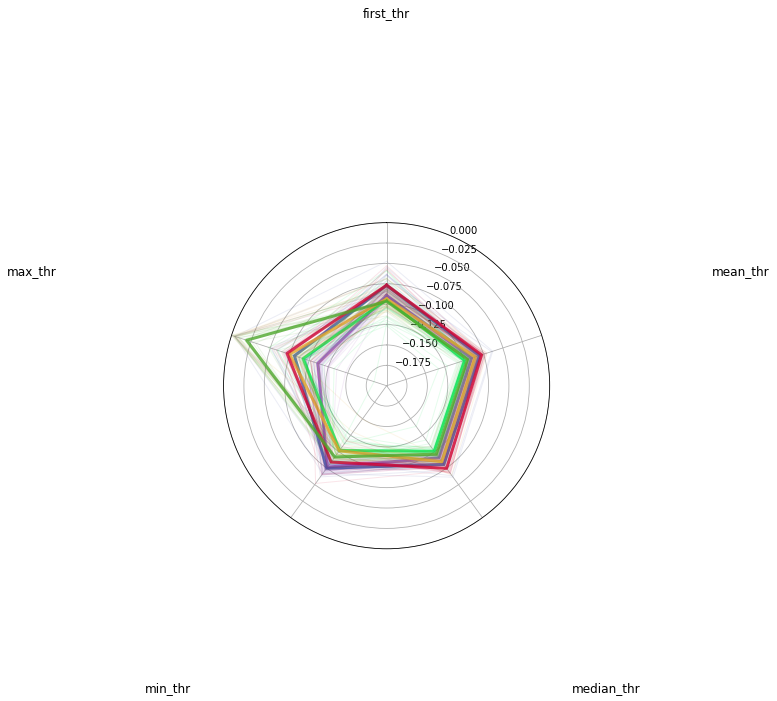

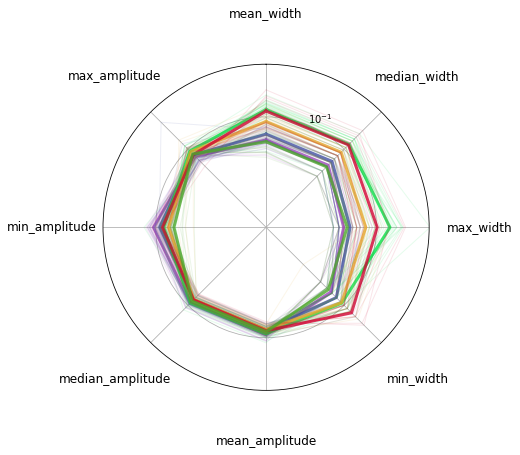

In [35]:
plot_radar(ephys_inh[ephys_inh.columns[:-6]],cols_spikes,ephys_inh['labels_ephys'],palette=coherence_colors,lims = (1e-3,1e0),save=True,savepath=savepath+'INH_FN_spikes_radar.pdf')
plot_radar(ephys_inh[ephys_inh.columns[:-6]],cols_thrs,ephys_inh['labels_ephys']  ,palette=coherence_colors,lims = (-0.2,0.0),logscale = False,plot_neg_log=False,save=True,savepath=savepath+'INH_FN_thrs_radar.pdf')
plot_radar(ephys_inh[ephys_inh.columns[:-6]],cols_wf,ephys_inh['labels_ephys']    ,palette=coherence_colors,lims = (1e-2,3e-1),save=True,savepath=savepath+'INH_FN_wave_radar.pdf')

## PCA subsets

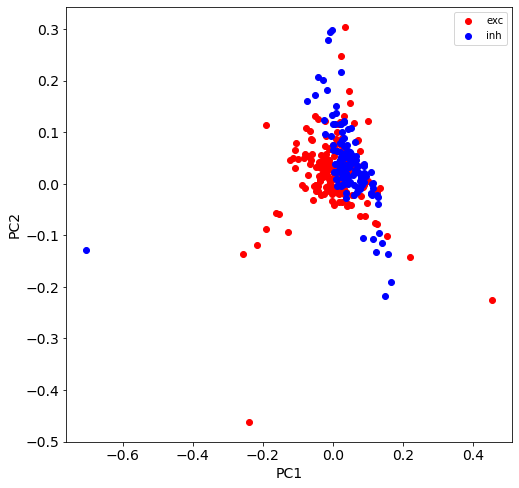

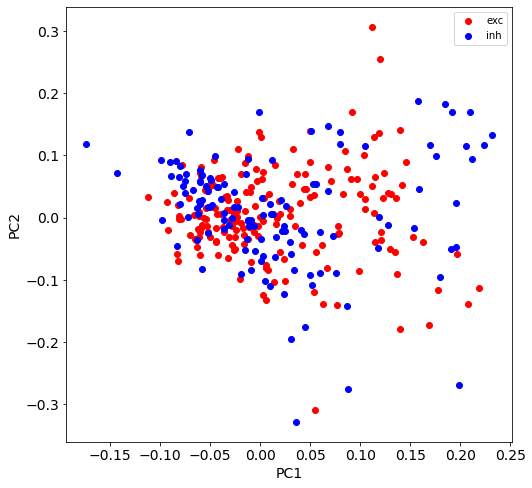

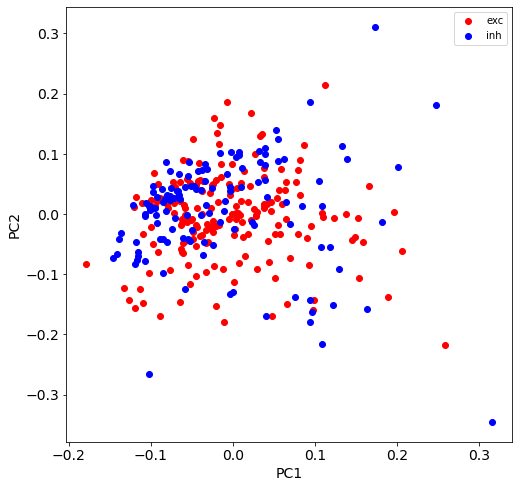

In [437]:
# %matplotlib ipympl =False



import numpy as np
from sklearn.decomposition import PCA
scaler = StandardScaler()
for sets in [cols_spikes, cols_thrs, cols_wf]:
    fig = plt.figure(figsize=[8,8])
    ax = fig.add_subplot()
    X1 = normalize(ephys_exc[sets].to_numpy().T)
    pca1 = PCA(n_components=2)
    pca1.fit_transform(X1)

    X2 = normalize(ephys_inh[sets].to_numpy().T)
    pca2 = PCA(n_components=2)
    pca2.fit_transform(X2)

    ax.scatter(pca1.components_[0],pca1.components_[1],label = 'exc',c = 'red')
    ax.scatter(pca2.components_[0],pca2.components_[1],label = 'inh',c = 'blue')

    ax.tight_layout=True
    ax.set_xlabel('PC1',fontsize=14)
    ax.set_ylabel('PC2',fontsize=14)
    plt.legend()
    # ax.set_zlabel('min_amplitude',fontsize=14)
    plt.show()



## MANOVA

In [789]:
data_manova = data_ephys_FN_acsf
data_manova['type'] = data_manova['labels_wave'].map({0:'inh',1:'exc'})


In [790]:
from statsmodels.multivariate.manova import MANOVA
# data_temp = data_manova[cols_ephys]
cols = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr',
       'time_to_first_spike', 'mean_isi', 'median_isi', 'max_isi', 'min_isi',
       'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
       'mean_width', 'median_width', 'max_width', 'min_width',
       'mean_amplitude', 'median_amplitude', 'min_amplitude', 'max_amplitude']
data_manova[cols] = normalize(data_manova[cols])
# Apply MANOVA with the renamed columns
manova = MANOVA.from_formula('current_at_first_spike + ap_count + fr + inst_fr + time_to_first_spike+ mean_isi+ median_isi + max_isi + min_isi + first_thr + mean_thr + median_thr + min_thr + max_thr + mean_width + median_width + max_width + min_width + mean_amplitude + median_amplitude + min_amplitude + max_amplitude ~ type',data = data_manova)
result = manova.mv_test()
print(result)

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
       Intercept         Value    Num DF  Den DF   F Value   Pr > F
-------------------------------------------------------------------
          Wilks' lambda   0.0013 21.0000 290.0000 10413.7278 0.0000
         Pillai's trace   0.9987 21.0000 290.0000 10413.7278 0.0000
 Hotelling-Lawley trace 754.0975 21.0000 290.0000 10413.7278 0.0000
    Roy's greatest root 754.0975 21.0000 290.0000 10413.7278 0.0000
-------------------------------------------------------------------
                                                                   
--------------------------------------------------------------------
           type           Value    Num DF   Den DF   F Value  Pr > F
--------------------------------------------------------------------
           Wilks' lambda  0.2819  21.0000  290.0000  35.1841  0.00

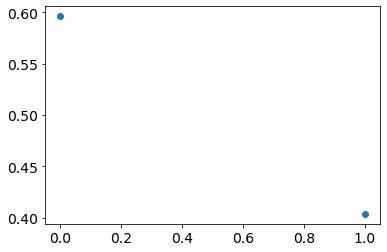

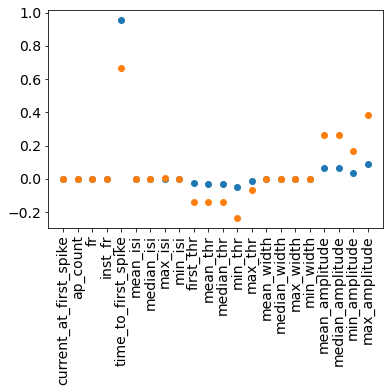

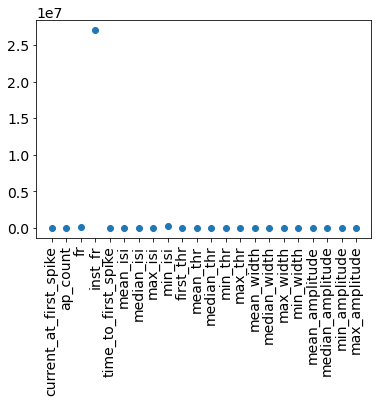

In [791]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda
X = data_manova[cols]
y = data_manova['type']
post_hoc = lda().fit(X=X, y=y)

# get Prior probabilities of groups:
plt.scatter(np.arange(len(post_hoc.priors_)),post_hoc.priors_)
plt.show()

# get group means
plt.scatter(data_manova.columns[:22],post_hoc.means_[0])
plt.scatter(data_manova.columns[:22],post_hoc.means_[1])
plt.xticks(rotation=90)
plt.show()

# get Coefficients of linear discriminants
plt.scatter(data_manova.columns[:22],post_hoc.scalings_)
plt.xticks(rotation=90)

plt.show()
# get Proportion of trace (variance explained by each of the selected components)



## CCA

CCA score:  -28.29486629351265
CCA score:  -18.88534589067473
CCA score:  -15.3374702068862
CCA score:  -10.204337185770932
CCA score:  -14.945876171181839
CCA score:  -10.569101764248977
CCA score:  -10.040523590839754
CCA score:  -43.823657517280346
CCA score:  -7.134473247441874
CCA score:  -5.80826665815995
-0.30410538899245987 0.30410538899245987


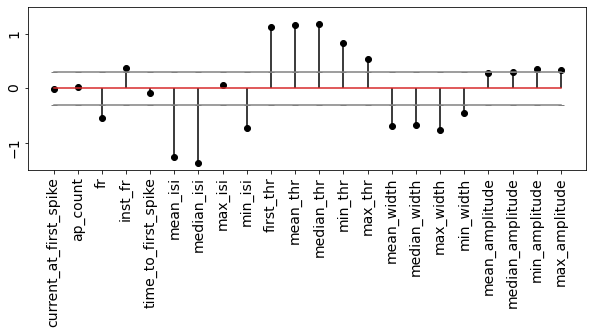

-0.2052726225856284 0.2052726225856284


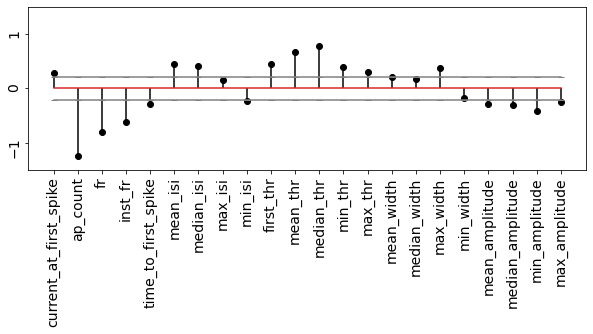

In [800]:

import numpy as np
from sklearn.cross_decomposition import CCA
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
scale = StandardScaler()
X_inh = data_manova[data_manova.type=='inh'][data_manova.columns[:22]].to_numpy()
X_exc = data_manova[data_manova.type=='exc'][data_manova.columns[:22]].to_numpy()

def perform_CCA(X,y,n_components=10):
    ca = CCA(n_components=n_components)
    ca.fit(X, y)
    X_c, Y_c = ca.transform(X,y)
    x_weights = ca.x_weights_
    score = ca.score(X , y)
    print('CCA score: ',score)
    return X_c,Y_c,ca

def return_ci(data,alpha):
    loadings  = data
    mean = np.mean(loadings)
    n = len(loadings)
    std = np.std(loadings)
    ci = (1.96)*(std/np.sqrt(n)) 
    print(mean - ci, mean + ci)
    return mean - ci, mean + ci

all_loadings_exc = []
all_loadings_inh = []

for i in range(10):

    _,_,ca_all_E_S = perform_CCA(X_inh,X_exc[np.random.randint(0,len(X_exc),len(X_inh))],n_components=22)

    all_loadings_exc.append(ca_all_E_S.x_loadings_[:,1])
    all_loadings_inh.append(ca_all_E_S.x_loadings_[:,0])

loadings_exc = np.mean(np.vstack(all_loadings_exc),axis=0)
loadings_exc = loadings_exc - np.mean(loadings_exc)

loadings_inh = np.mean(np.vstack(all_loadings_inh),axis=0)
loadings_inh = loadings_inh - np.mean(loadings_inh)


ci_neg, ci_pos = return_ci(loadings_exc, alpha=0.05)

plt.figure(figsize=[10,3])
plt.stem(data_manova.columns[:22],loadings_exc,'black')
plt.tick_params(rotation=90)
plt.plot(np.repeat(ci_neg,22), c='grey', marker = '_')
plt.plot(np.repeat(ci_pos,22), c='grey', marker = '_')
plt.ylim(-1.5,1.5)
plt.savefig(savepath+'stem_ephys_exc.pdf',dpi=200)
plt.show()

plt.figure(figsize=[10,3])

ci_neg, ci_pos = return_ci(loadings_inh, alpha=0.05)
plt.stem(data_manova.columns[:22], loadings_inh,'black')
plt.tick_params(rotation=90)
plt.plot(np.repeat(ci_neg,22),c='grey',marker = '_')
plt.plot(np.repeat(ci_pos,22),c='grey',marker = '_')
plt.ylim(-1.5,1.5)
plt.savefig(savepath+'stem_ephys_inh.pdf',dpi=200)
plt.show()


-0.3526641935609164 1.1272198360941985


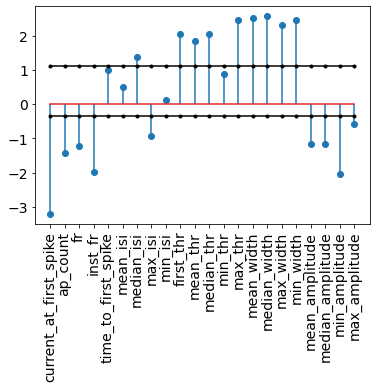

-1.5735164838386133 3.5354079927069915


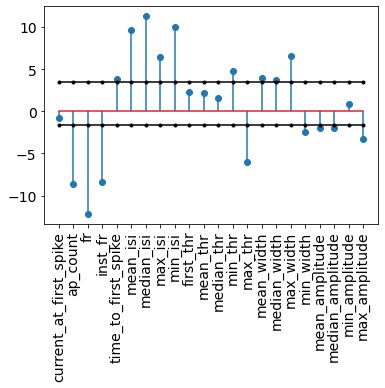

In [606]:

ci_neg, ci_pos = return_ci(ca_all_E_S.x_loadings_[:,1], alpha=0.05)
plt.stem(data_manova.columns[:22], ca_all_E_S.x_loadings_[:,1])
plt.xticks(rotation=90)
plt.plot(np.repeat(ci_neg,22), c='black', marker = '.')
plt.plot(np.repeat(ci_pos,22), c='black', marker = '.')
plt.savefig('D:/Data For Publication/figures/part2/')
plt.show()

ci_neg, ci_pos = return_ci(ca_all_E_S.x_loadings_[:,0], alpha=0.05)
plt.stem(data_manova.columns[:22], ca_all_E_S.x_loadings_[:,0])
plt.xticks(rotation=90)
plt.plot(np.repeat(ci_neg,22),c='black',marker = '.')
plt.plot(np.repeat(ci_pos,22),c='black',marker = '.')
plt.show()

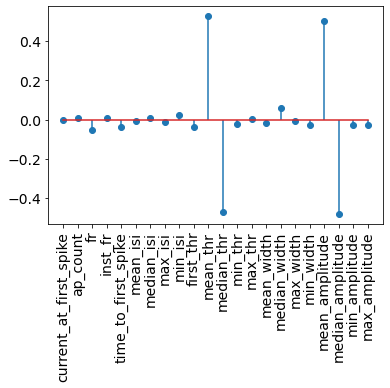

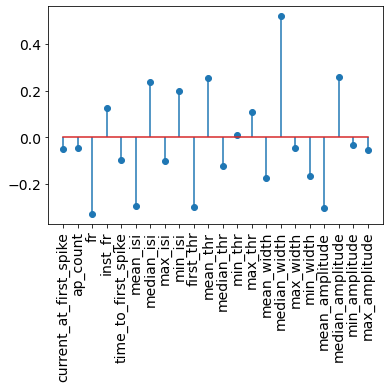

In [571]:

plt.stem(data_manova.columns[:22], ca_all_E_S.x_weights_[:,0])
plt.xticks(rotation=90)
plt.show()

plt.stem(data_manova.columns[:22], ca_all_E_S.x_weights_[:,1])
plt.xticks(rotation=90)
plt.show()


## plot waveforms for each cluster

In [37]:
waves_exc = data_wave_FN_acsf[data_wave_FN_acsf.exp_name.isin(ephys_exc.exp_name)]
waves_exc = waves_exc.drop_duplicates('exp_name')
waves_exc['labels_ephys'] = np.array(ephys_exc.labels_ephys)
waves_inh = data_wave_FN_acsf[data_wave_FN_acsf.exp_name.isin(ephys_inh.exp_name)]
waves_inh = waves_inh.drop_duplicates('exp_name')
waves_inh['labels_ephys'] = np.array(ephys_inh.labels_ephys)


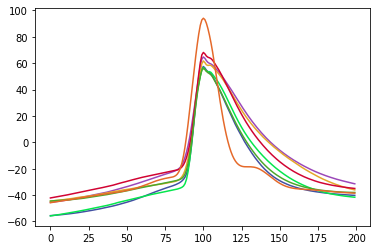

In [38]:
for i in set(waves_exc.labels_ephys):
    plt.plot(np.mean(np.vstack(waves_exc[waves_exc.labels_ephys==i]['waveform'].to_numpy()),axis=0),c=coherence_colors[i])
    # plt.show()
plt.savefig(savepath+'exc_waves_mean.pdf',dpi=200)

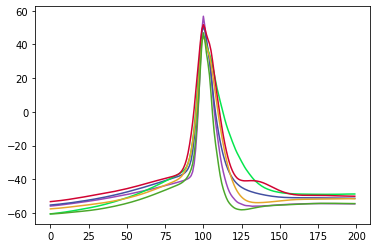

In [39]:
for i in set(waves_inh.labels_ephys):
    plt.plot(np.mean(np.vstack(waves_inh[waves_inh.labels_ephys==i]['waveform'].to_numpy()),axis=0),c=coherence_colors[i])
    # plt.show()
plt.savefig(savepath+'inh_waves_mean.pdf',dpi=200)    

## Significance test 

<Axes: >

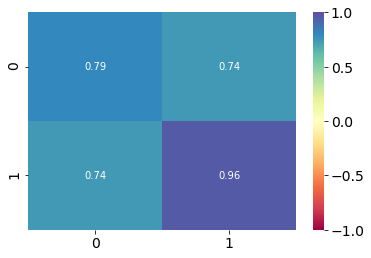

In [363]:
data_ephys_FN_acsf.labels_wave = binarize_EI_labels(np.array(data_ephys_FN_acsf.labels_wave),[1,2,3,6,7])
# wave_exc = data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave.isin([1,2,3,6,7])]
# wave_inh = data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave.isin([0,5,4])]

cosine_mat = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        cosine_mat[i,j] = np.mean(cosine_similarity(normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==i][cols_temp].to_numpy())),
                  normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==j][cols_temp].to_numpy()))))

sns.heatmap(cosine_mat,vmax=1,vmin=-1,annot=True,cmap = 'Spectral')

In [364]:
import numpy as np
from scipy.stats import f_oneway
data1 = cosine_similarity(normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==0][cols_temp].to_numpy())),
                  normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==0][cols_temp].to_numpy())))
data1 = data1[np.tril_indices_from(data1)]
data2 = cosine_similarity(normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==1][cols_temp].to_numpy())),
                  normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==1][cols_temp].to_numpy())))
data2 = data2[np.tril_indices_from(data2)]
data3 = cosine_similarity(normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==1][cols_temp].to_numpy())),
                  normalize(np.vstack(data_ephys_FN_acsf[data_ephys_FN_acsf.labels_wave==0][cols_temp].to_numpy())))

data3 = data3.reshape(1,-1)[0]
import statsmodels.api as sm
def calcualte_cosine_sig(data1,data2,data3):
    return sm.stats.anova_oneway([data1,data2,data3])

print(calcualte_cosine_sig(data1,data2,data3))

statistic = 8772.354118364967
pvalue = 0.0
df = (2.0, 18308.226898897734)
df_num = 2.0
df_denom = 18308.226898897734
nobs_t = 48828.0
n_groups = 3
means = [0.79407431 0.95701047 0.7391163 ]
nobs = [ 8001. 17391. 23436.]
vars_ = [0.04648135 0.00721223 0.06657426]
use_var = unequal
welch_correction = True
tuple = (8772.354118364967, 0.0)


In [365]:
games_howell(data1,data2,data3)

,mean_differences,degrees_freedom,t_values,p_values,std_err,up_conf,low_conf,group_comps
0,0.162936,9161.539599,65.313586,0.001,0.001764,3.477981,-3.152109,0 : 1
1,-0.054958,16398.682442,18.687064,0.001,0.002080,3.259845,-3.369761,0 : 2
2,-0.217894,29917.632997,120.768449,0.001,0.001276,3.096771,-3.532560,1 : 2


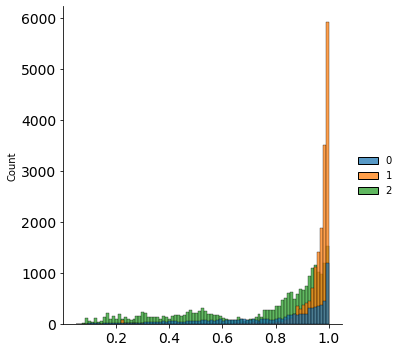

In [305]:
sns.displot([data1,data2,data3])

In [ ]:

for i in ['C', 'gl', 'El', 'Vr', 'Vt', 'DV',]:
    sns.boxplot(data = df_temp,x='type',y=i)
    plt.show()
    rvs1 = df_temp[df_temp.type=='exc'][i]
    rvs2 = df_temp[df_temp.type=='inh'][i]

    print(stats.ttest_ind(rvs1, rvs2, equal_var=False))

# Biophysical

In [10]:
def return_name_date_exp_fn(string):

  if 'NC' in string:
    string_broken = string.split('_')
    name = string_broken[0]
    date = string_broken[1]
    exp = string_broken[-1]
    year = date[:2]
    month = date[2:4]

    if month[0] =='0':
      month = month[1]
    day = date[4:]
    if day[0] =='0':
      day = day[1]
    date = day+month+year  
    return name+'_'+date+'_'+exp 
  elif 'xuan' in string:
    broken_str = string.split('_')
    name = broken_str[0]
    date = broken_str[1].replace('-','')
    exp =  broken_str[2]
    return name+'_'+date+'_'+exp
  elif 'asli' in string:
    broken_str = string.split('_')
    name = broken_str[0]
    date = broken_str[1]
    date = date.replace('-','')
    exp =  broken_str[2]
    return name+'_'+date+'_'+exp    
  elif 'Payam' in string or 'payam' in string :
    broken_str = string.split('_')
    name = broken_str[0].lower()
    date = broken_str[1].split('-')
    exp =  broken_str[2]
    day = date[0]
    month = date[1]
    year = date[2]
    if day[0] =='0':
      day=day[1]
    date = day+month+year  
    return name+'_'+date+'_'+exp

In [11]:
df = pd.read_pickle("D:/Biophysical_cluster/rect_bio_all_feats.pkl")
# df.exp_name = df.exp_name.apply(return_name_date_exp_fn)

df = df[~df.exp_name.isin(discarded_exps)]
# df = df[df.columns[1:]]
df_acsf = df[df.cond.isin(['acsf','acsf_bic'])]
df_acsf = df_acsf[df_acsf.trial==0]
df_acsf['labels_wave']=binarize_EI_labels(labels_wave,[1,2,3,6,7])

# np.unique(df_acsf.labels_wave,return_counts=True)

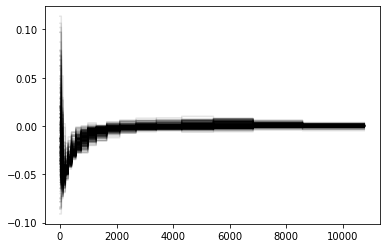

In [12]:
plt.plot(normalize(np.vstack(df_acsf[df_acsf.r_squared_V>0.7]['eta'])).T,c='black',alpha=0.1)
plt.show()

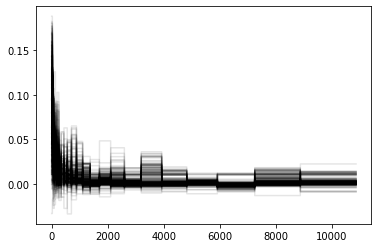

In [15]:
plt.plot(normalize(np.vstack(df_acsf[df_acsf.r_squared_V>0.7]['gamma_threshold'])).T,c='black',alpha=0.1)
plt.show()

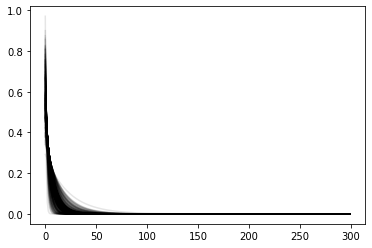

In [16]:
plt.plot(normalize(np.vstack(df_acsf[df_acsf.r_squared_V>0.7]['K'])).T,c='black',alpha=0.1)
plt.show()

In [18]:
def return_lower(data):
    return data.lower()

<Axes: >

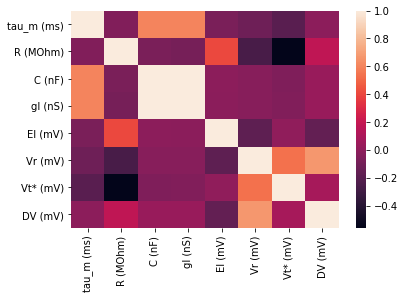

In [47]:
sns.heatmap(df[[ 'tau_m (ms)', 'R (MOhm)','C (nF)', 'gl (nS)', 'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)',]].corr())

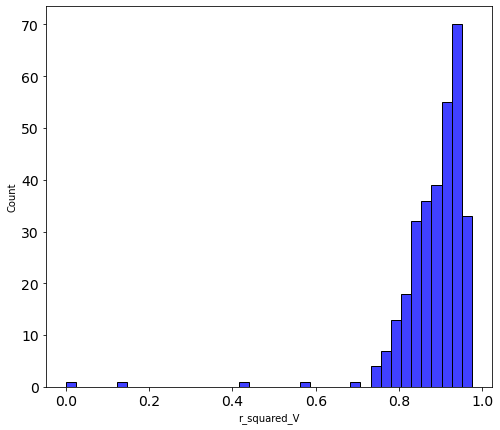

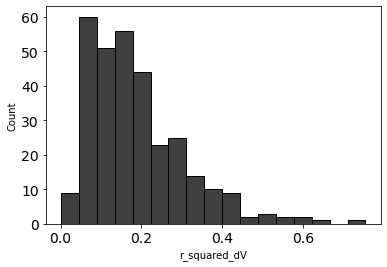

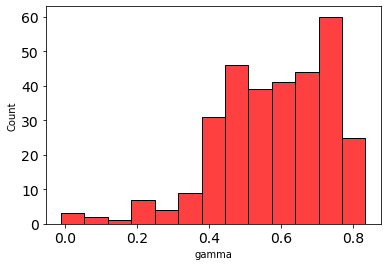

In [93]:
plt.rcParams['xtick.labelsize']=14
plt.rcParams['ytick.labelsize']=14
fig,ax = plt.subplots(figsize=[8,7])
sns.histplot(df_acsf['r_squared_V'],color='blue')
plt.show()
# plt.savefig(savepath+'rsquaredV_dist.pdf',dpi=200)
sns.histplot(df_acsf['r_squared_dV'],color='black')
plt.show()
# plt.savefig(savepath+'rsquareddV_dist.pdf',dpi=200)
sns.histplot(df_acsf['gamma'],color='red',)
plt.show()
# plt.savefig(savepath+'gamma_dist.pdf',dpi=200)


In [13]:
df_biophys_exc = df_acsf[df_acsf.labels_wave == 1]
df_biophys_inh = df_acsf[df_acsf.labels_wave == 0]


In [14]:
df_biophys_exc = df_biophys_exc[df_biophys_exc.r_squared_V>0.7]
df_biophys_inh = df_biophys_inh[df_biophys_inh.r_squared_V>0.7]


feat_cols_bio =  df_biophys_inh.columns[:-7]

In [96]:
len(df_biophys_exc)+len(df_biophys_inh)

307

In [15]:
cols_bio = [ 'gl (nS)','C (nF)',  'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)',]

In [ ]:

data_umap_scaler = StandardScaler()

find_optimum_res(data_umap_scaler.fit_transform(normalize(df_biophys_inh[cols_bio])),save=True,savepath=savepath+'cluster_stability_bio_inh.pdf')
find_optimum_res(data_umap_scaler.fit_transform(normalize(df_biophys_exc[cols_bio])),save=True,savepath=savepath+'cluster_stability_bio_exc.pdf')


## passive params

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


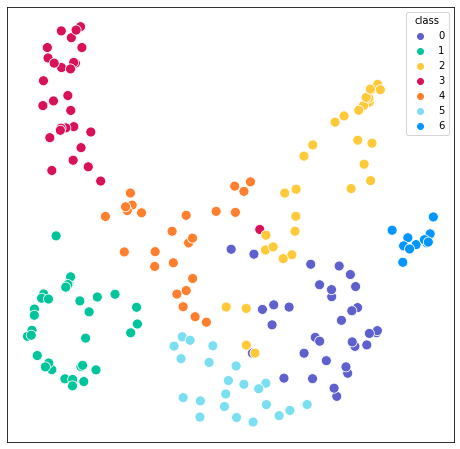

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


6


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


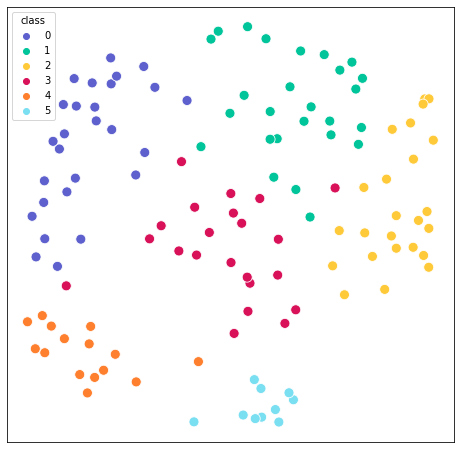

In [16]:
cols_bio = [ 'gl (nS)','C (nF)',  'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)',]
bio_phys_exc = normalize(np.vstack(df_biophys_exc[cols_bio].to_numpy()),axis=0)
lables_bio_exc,mapper,reducer = plot_UMAP_clusters_single(bio_phys_exc,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =False,
                          savepath = savepath+'exc_bio_cluster.pdf'
                        #   title='UMAP+Louvain for biophysics'
                          )

bio_phys_inh = normalize(np.vstack(df_biophys_inh[cols_bio].to_numpy()),axis=0)
lables_bio_inh,mapper,reducer = plot_UMAP_clusters_single(bio_phys_inh,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =False,
                          savepath = savepath+'inh_bio_cluster.pdf'
                          )
df_biophys_exc['lables_bio'] = lables_bio_exc
df_biophys_inh['lables_bio'] = lables_bio_inh

## eta

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


6


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


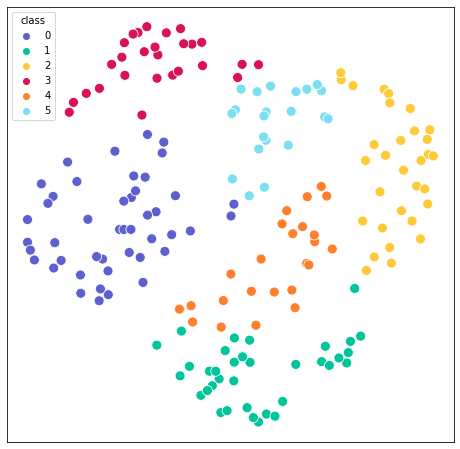

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


6


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


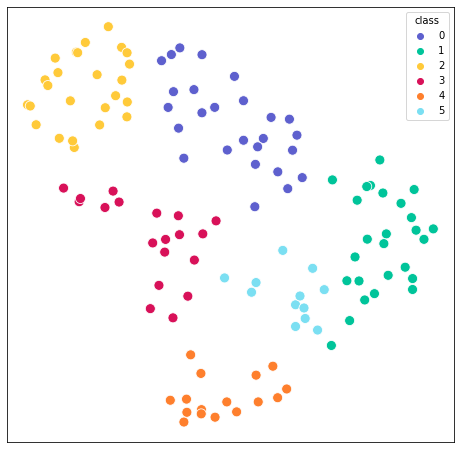

In [53]:
cols_bio = ['gl (nS)','C (nF)','El (mV)','Vr (mV)','Vt* (mV)','DV (mV)']
bio_phys_exc = normalize(np.vstack(df_biophys_exc['eta'].to_numpy()),axis=0)
lables_bio_exc,mapper,reducer = plot_UMAP_clusters_single(bio_phys_exc,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =True,
                          savepath = savepath+'exc_eta_cluster.pdf'
                        #   title='UMAP+Louvain for biophysics'
                          )

bio_phys_inh = normalize(np.vstack(df_biophys_inh['eta'].to_numpy()),axis=0)
lables_bio_inh,mapper,reducer = plot_UMAP_clusters_single(bio_phys_inh,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =True,
                          savepath = savepath+'inh_eta_cluster.pdf'
                          )
df_biophys_exc['lables_eta'] = lables_bio_exc
df_biophys_inh['lables_eta'] = lables_bio_inh

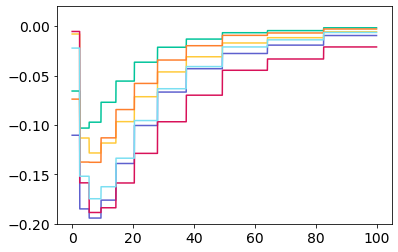

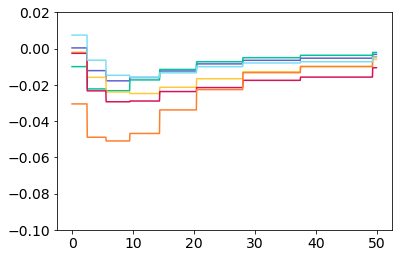

In [54]:
for i in set(df_biophys_exc['lables_eta']):
    plt.plot(np.arange(0,100,1/20),np.mean((df_biophys_exc[df_biophys_exc['lables_eta']==i]['eta']),axis=0).T[:100*20],c=CUSTOM_PAL_SORT_3[i])
    plt.ylim(-0.2,0.02)
# plt.savefig(savepath+'eta_shapes_exc.pdf',dpi=200)
plt.show()
for i in set(df_biophys_inh['lables_eta']):
    plt.plot(np.arange(0,50,1/20) , np.mean(df_biophys_inh[df_biophys_inh['lables_eta']==i]['eta'],axis=0).T[:50*20],c=CUSTOM_PAL_SORT_3[i])
    plt.ylim(-0.1,0.02)

# plt.savefig(savepath+'eta_shapes_inh_inset.pdf',dpi=200)

In [55]:
np.mean(cosine_similarity(np.vstack(df_biophys_exc['eta']),np.vstack(df_biophys_exc['eta'])))

0.9033044260516858

## gamma

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


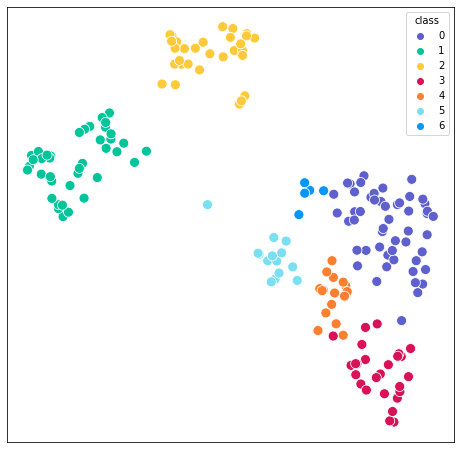

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


5


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


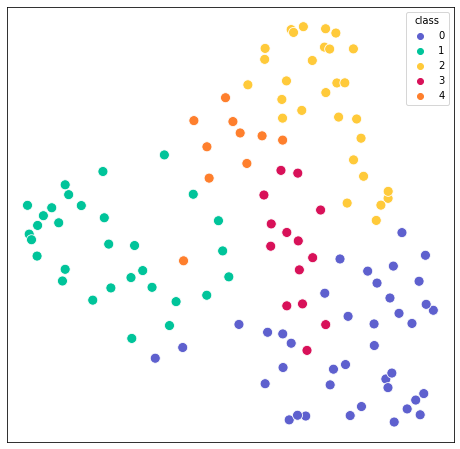

In [56]:
cols_bio = [ 'gl (nS)','C (nF)',  'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)',]
bio_phys_exc = normalize(np.vstack(df_biophys_exc['gamma_threshold'].to_numpy()),axis=0)
lables_bio_exc,mapper,reducer = plot_UMAP_clusters_single(bio_phys_exc,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =False,
                          savepath = savepath+'exc_bio_cluster.pdf'
                        #   title='UMAP+Louvain for biophysics'
                          )

bio_phys_inh = normalize(np.vstack(df_biophys_inh['gamma_threshold'].to_numpy()),axis=0)
lables_bio_inh,mapper,reducer = plot_UMAP_clusters_single(bio_phys_inh,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =False,
                          savepath = savepath+'inh_bio_cluster.pdf'
                          )
df_biophys_exc['lables_gamma'] = lables_bio_exc
df_biophys_inh['lables_gamma'] = lables_bio_inh

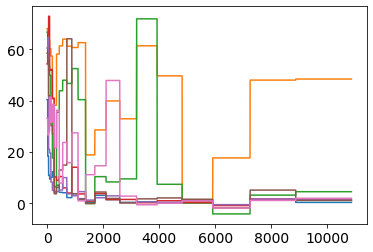

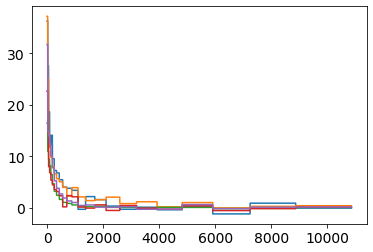

In [57]:
for i in set(df_biophys_exc['lables_gamma']):
    plt.plot(np.mean(df_biophys_exc[df_biophys_exc['lables_gamma']==i]['gamma_threshold'],axis=0).T)
plt.show()

for i in set(df_biophys_inh['lables_gamma']):
    plt.plot(np.mean(df_biophys_inh[df_biophys_inh['lables_gamma']==i]['gamma_threshold'],axis=0).T)
plt.show()

## passive+eta

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


6


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


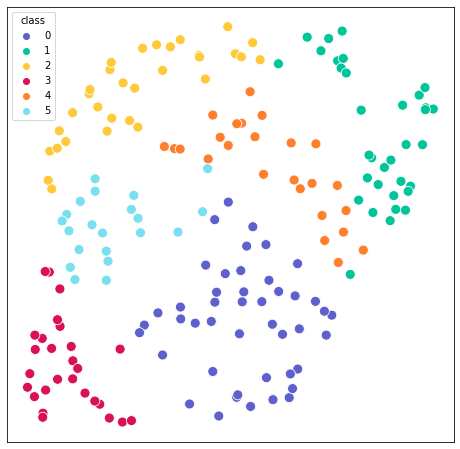

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


6


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


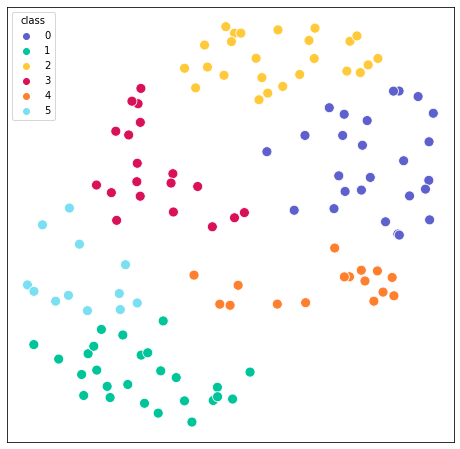

In [58]:
cols_bio_ = [ 'gl (nS)','C (nF)',  'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)','eta']
bio_phys_exc = normalize(np.vstack([np.hstack(i) for i in df_biophys_exc[cols_bio_].to_numpy()]),axis=0)
lables_bio_exc,mapper,reducer = plot_UMAP_clusters_single(bio_phys_exc,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =False,
                          savepath = savepath+'exc_bio_cluster.pdf'
                        #   title='UMAP+Louvain for biophysics'
                          )

bio_phys_inh = normalize(np.vstack([np.hstack(i) for i in df_biophys_inh[cols_bio_].to_numpy()]),axis=0)
lables_bio_inh,mapper,reducer = plot_UMAP_clusters_single(bio_phys_inh,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                          size=100,
                          norm=False,
                          save =False,
                          savepath = savepath+'inh_bio_cluster.pdf'
                          )
df_biophys_exc['lables_bio_eta'] = lables_bio_exc
df_biophys_inh['lables_bio_eta'] = lables_bio_inh

In [59]:
with open("C:/Users/Nishant Joshi/Model_fitting/GIFFittingToolbox/src/examples/cluster_stability/cluster_stablity_biophys_E1.pkl",'rb') as f:
    clust_biophys_E = pickle.load(f) 

with open("C:/Users/Nishant Joshi/Model_fitting/GIFFittingToolbox/src/examples/cluster_stability/cluster_stablity_biophys_I1.pkl",'rb') as f:
    clust_biophys_I = pickle.load(f) 

with open("C:/Users/Nishant Joshi/Model_fitting/GIFFittingToolbox/src/examples/cluster_stability/cluster_stablity_ephys_E1.pkl",'rb') as f:
    clust_ephys_E = pickle.load(f)     

with open("C:/Users/Nishant Joshi/Model_fitting/GIFFittingToolbox/src/examples/cluster_stability/cluster_stablity_ephys_I1.pkl",'rb') as f:
    clust_ephys_I = pickle.load(f)     


        

In [60]:

def plot_clust_res_temp(all_data,pallete,save=True,savepath=None):
    f, ax1 = plt.subplots(figsize=[10,8])
    cols = list(all_data.keys())
    for num, feat in enumerate(all_data.keys()):
        modularity_dict, n_clusts_dict = all_data[feat].values()
        resolution_list = np.linspace(0,5,11)

        avg_n_clusts = []
        for k in list(n_clusts_dict.keys()):
            avg_n_clusts.append(np.mean(n_clusts_dict[k]))
            
        std_n_clusts = []
        for k in list(n_clusts_dict.keys()):
            std_n_clusts.append(np.std(n_clusts_dict[k]))
            
        std_modularity = []
        for k in list(modularity_dict.keys()):
            std_modularity.append(np.std(modularity_dict[k]))
            
        avg_modularity = []
        for k in list(modularity_dict.keys()):
            avg_modularity.append(np.mean(modularity_dict[k]))


        ax1.errorbar(resolution_list,avg_modularity,yerr=std_modularity,
                    marker='o', fillstyle='full', markerfacecolor='w', 
                    linewidth=1, markeredgewidth=1,c=pallete[num])
        ax1.set_ylabel('Modularity Score')
        ax1.set_xlabel('Resolution Parameter',fontsize=12)
        ax1.set_xlim([0,5])
        ax1.set_xticks([0,2,4,6])
        ax1.yaxis.label.set_color('#5c95ff')
        ax1.tick_params(axis='y',colors='#5c95ff')
        ax1.set_ylim(0,1.0)
        ax1.set_yticks([0,0.2,0.4,0.6,0.8,1.0])
        # ax1.set_yticklabels([0.0,'',0.2,'',0.4,'',0.6,'',0.8,'',1.0],fontsize=12)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_color('#f87575')
        ax1.spines['left'].set_color('#5c95ff')

        ax2 = ax1.twinx()
        ax2.errorbar(resolution_list[1:],avg_n_clusts[1:],yerr=std_n_clusts[1:],c=pallete[num], marker='o', fillstyle='full', markerfacecolor='w', linewidth=1, markeredgewidth=1)
        ax2.set_ylabel('Number of Clusters',fontsize=12,c='#f87575')
        # ax2.spines['left'].set_color('b')
        ax2.tick_params(axis='y',colors='#f87575')
        ax2.set_ylim([0,22])
        ax2.set_yticks([0,4,8,12,16,18,20]);
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_color('#f87575')
        ax2.spines['left'].set_color('#5c95ff')

    box = ax1.get_position()
    ax1.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    # Put a legend to the right of the current ax1is
    ax1.legend(cols,loc='center left', bbox_to_anchor=(1.1, 0.5),fontsize=12)

    if save:
        plt.savefig(savepath,dpi=200)
    else:
        plt.show()


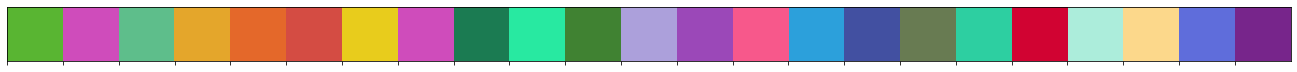

In [61]:
coherence_colors_temp = [
 [0.351, 0.712, 0.198],
 [0.812, 0.3, 0.734],
 [0.369, 0.749, 0.549],
 [0.898, 0.654, 0.169],
 [0.898, 0.41, 0.165],
 [0.834, 0.3, 0.265],
 [0.912, 0.8, 0.112],
 [0.812, 0.3, 0.734],
 [0.109, 0.483, 0.324],
 [0.159, 0.914, 0.635],
 [0.251, 0.512, 0.198],
 [0.676, 0.631, 0.859],
 [0.609, 0.283, 0.724],
 [0.969, 0.349, 0.549],
 [0.176, 0.631, 0.859],
 [0.259, 0.314, 0.635],
 [0.409, 0.483, 0.324],
 [0.179, 0.814, 0.635],
 [0.821, 0.012, 0.198],
 [0.676, 0.931, 0.859],
 [0.989, 0.849, 0.549],
 [0.376, 0.431, 0.859],
 [0.469, 0.149, 0.549]]
 
sns.palplot(coherence_colors_temp)

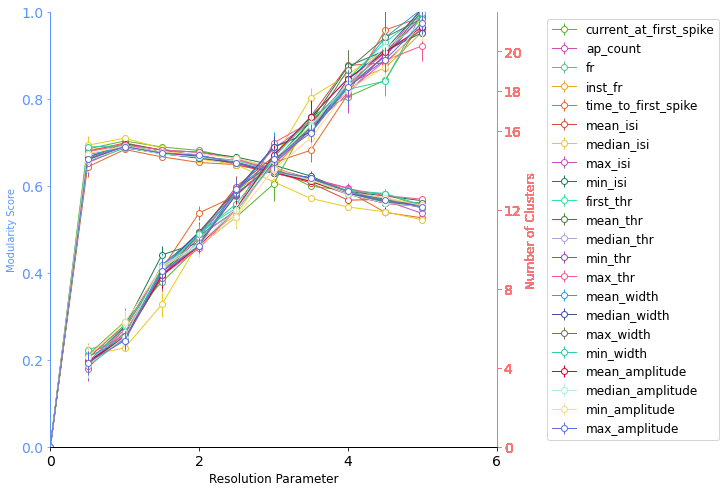

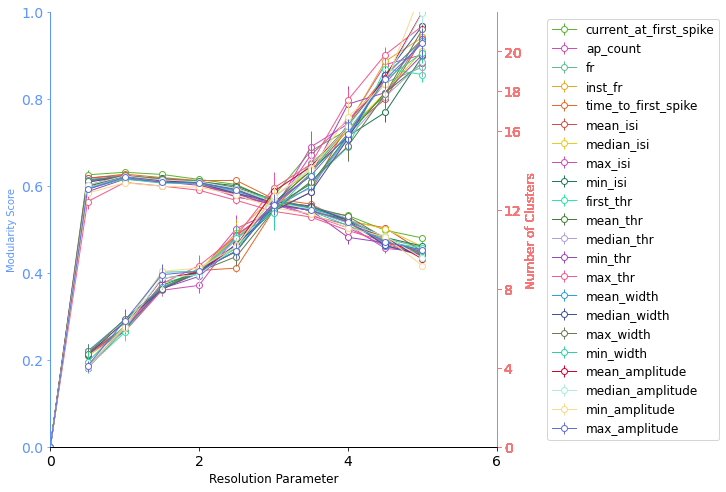

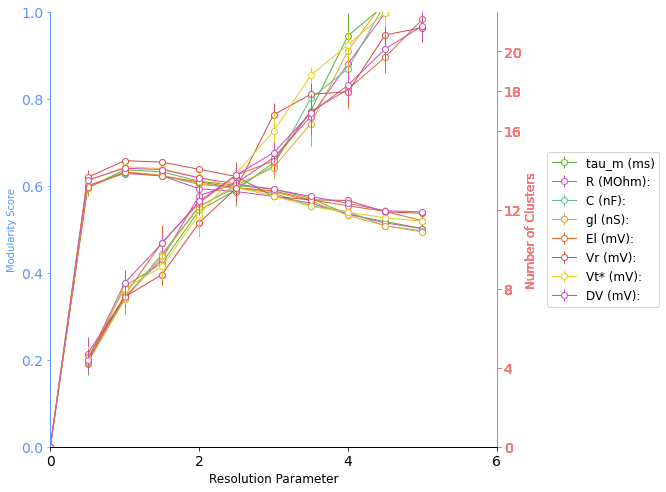

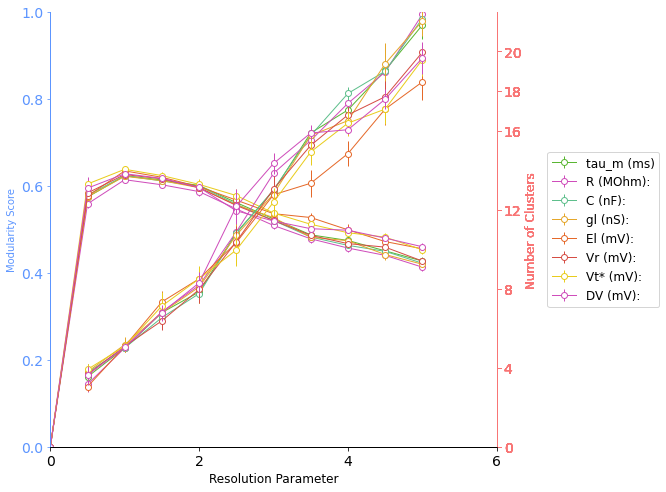

In [62]:
# clust_ephys_E
plot_clust_res_temp(clust_ephys_E,  coherence_colors_temp,save=True,savepath=savepath+'exc_ephys_cluster_stability_exclustion.pdf')
plot_clust_res_temp(clust_ephys_I,  coherence_colors_temp,save=True,savepath=savepath+'inh_ephys_cluster_stability_exclustion.pdf')
plot_clust_res_temp(clust_biophys_E,coherence_colors_temp,save=True,savepath=savepath+'exc_bio_cluster_stability_exclustion.pdf')
plot_clust_res_temp(clust_biophys_I,coherence_colors_temp,save=True,savepath=savepath+'inh_bio_cluster_stability_exclustion.pdf')


## radar plot

In [63]:
cols_bio= [ 'gl (nS)','C (nF)',  'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)']


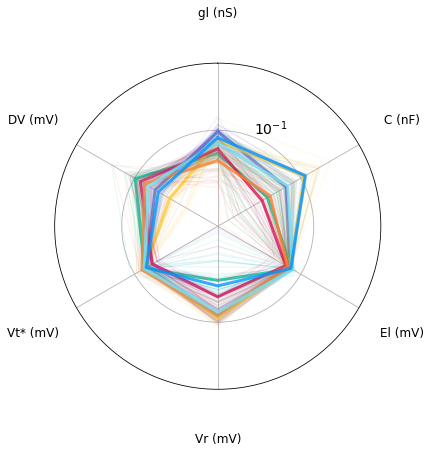

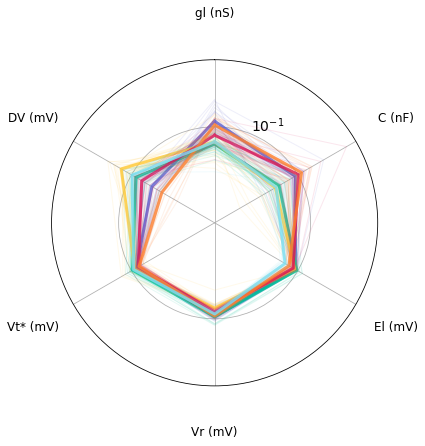

In [64]:
plot_radar(np.abs(df_biophys_exc[cols_bio]),cols_bio,np.array(df_biophys_exc.lables_bio),lims=(1e-2,5e-1),logscale=True,plot_neg_log=False,palette= CUSTOM_PAL_SORT_3,save=False,savepath=savepath+'exc_bio_radar.pdf')
plot_radar(np.abs(df_biophys_inh[cols_bio]),cols_bio,np.array(df_biophys_inh.lables_bio),lims=(1e-2,5e-1),logscale=True,plot_neg_log=False,palette= CUSTOM_PAL_SORT_3,save=False,savepath=savepath+'inh_bio_radar.pdf')

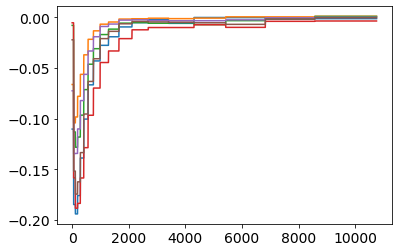

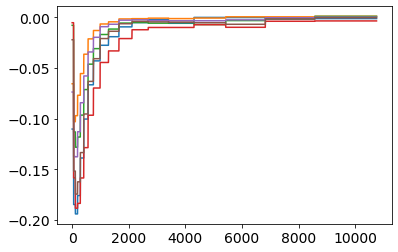

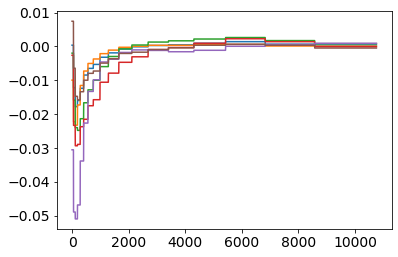

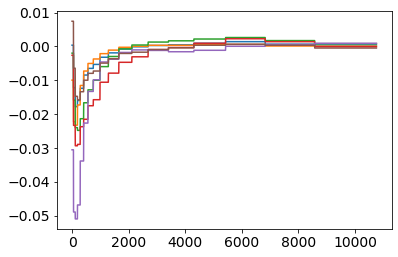

In [65]:
for i in set(df_biophys_exc['lables_bio_eta']):
    plt.plot(np.mean(df_biophys_exc[df_biophys_exc['lables_bio_eta']==i]['eta'],axis=0).T)
plt.show()
for i in set(df_biophys_exc['lables_eta']):
    plt.plot(np.mean(df_biophys_exc[df_biophys_exc['lables_eta']==i]['eta'],axis=0).T)
plt.show()
for i in set(df_biophys_inh['lables_bio_eta']):
    plt.plot(np.mean(df_biophys_inh[df_biophys_inh['lables_bio_eta']==i]['eta'],axis=0).T)
plt.show()

for i in set(df_biophys_inh['lables_eta']):
    plt.plot(np.mean(df_biophys_inh[df_biophys_inh['lables_eta']==i]['eta'],axis=0).T)
plt.show()

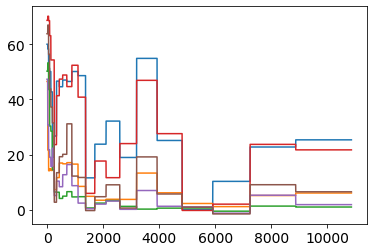

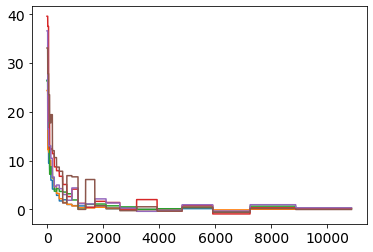

In [66]:
for i in set(df_biophys_exc['lables_bio_eta']):
    plt.plot(np.mean(df_biophys_exc[df_biophys_exc['lables_bio_eta']==i]['gamma_threshold'],axis=0).T)
plt.show()

for i in set(df_biophys_inh['lables_bio_eta']):
    plt.plot(np.mean(df_biophys_inh[df_biophys_inh['lables_bio_eta']==i]['gamma_threshold'],axis=0).T)
plt.show()

<ipython-input-177-519b80fb8949>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['C (nF)'] = np.log(np.float32(df_temp['C (nF)']))
<ipython-input-177-519b80fb8949>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['gl (nS)'] = np.log(np.float32(df_temp['gl (nS)']))
<ipython-input-177-519b80fb8949>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

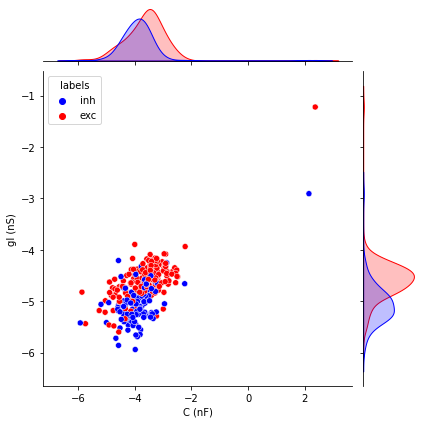

In [177]:
# plt.scatter(df_biophys_exc['C (nF)'] , df_biophys_exc['gl (nS)'],c='red')
# plt.scatter(df_biophys_inh['C (nF)'] , df_biophys_inh['gl (nS)'],c='blue')

# plt.xlabel('C (nF)',fontsize=14)
# plt.ylabel('gl (nS)',fontsize=14)
# plt.savefig(savepath+'g_vs_C.pdf',dpi=200)
def make_ei_labels(labels):
    ret_labels = []
    for i in labels :
        if i==0:
            ret_labels.append('inh')
        else:
            ret_labels.append('exc')
    return ret_labels
df_temp = df_acsf[['C (nF)','gl (nS)']]
df_temp['C (nF)'] = np.log(np.float32(df_temp['C (nF)']))
df_temp['gl (nS)'] = np.log(np.float32(df_temp['gl (nS)']))

df_temp.loc[:,'labels'] = make_ei_labels(df_acsf['labels_wave'].to_numpy())
sns.jointplot(data = df_temp, x='C (nF)', y='gl (nS)', hue='labels',palette=['blue','red'])



##  significance test passive

In [99]:
from sklearn.metrics.pairwise import cosine_similarity


In [355]:
data_exc = normalize(np.vstack(df_biophys_exc[cols_bio].to_numpy()))
data_inh = normalize(np.vstack(df_biophys_exc[cols_bio].to_numpy()))

sim_inh = cosine_similarity(data_inh,data_inh)[np.triu_indices_from(cosine_similarity(data_inh,data_inh),k=1)]
sim_exc = cosine_similarity(data_exc,data_exc)[np.triu_indices_from(cosine_similarity(data_exc,data_exc),k=1)]
sim_inh_exc = cosine_similarity(data_exc,data_inh).reshape(1,-1)[0]

In [354]:
np.mean(sim_inh_exc)

0.9841836695363948

In [34]:
df_temp  = pd.concat([df_biophys_exc,df_biophys_inh])
df_temp.labels_wave = np.concatenate([np.ones(len(df_biophys_exc)),np.zeros(len(df_biophys_inh))]) 

<Axes: >

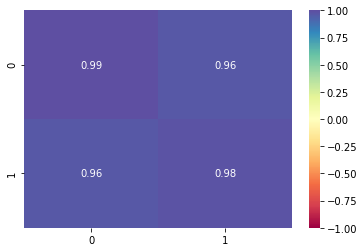

In [37]:
from sklearn.metrics.pairwise import cosine_similarity


cosine_mat = np.zeros((2,2))

for i in range(2):
    for j in range(2):

        if i==j:
            
            idx = np.tril_indices_from(cosine_similarity(normalize(np.vstack(df_temp[df_temp.labels_wave==i][cols_bio].to_numpy())),
                    normalize(np.vstack(df_temp[df_temp.labels_wave==j][cols_bio].to_numpy()))))
            
            data = cosine_similarity(normalize(np.vstack(df_temp[df_temp.labels_wave==i][cols_bio].to_numpy())),
                    normalize(np.vstack(df_temp[df_temp.labels_wave==j][cols_bio].to_numpy())))[idx]
            
            cosine_mat[i,j] = np.mean(data)

        else:

            cosine_mat[i,j] = np.mean(cosine_similarity(normalize(np.vstack(df_temp[df_temp.labels_wave==i][cols_bio].to_numpy())),
                    normalize(np.vstack(df_temp[df_temp.labels_wave==j][cols_bio].to_numpy()))))

sns.heatmap(cosine_mat, vmax=1, vmin=-1, annot=True, cmap = 'Spectral')
# plt.savefig(savepath+'EI_similarity.pdf',dpi=200)

In [356]:
import statsmodels.api as sm
print(sm.stats.anova_oneway([sim_inh_exc,sim_exc,sim_inh]))

statistic = 0.16777199584749036
pvalue = 0.8455472714259953
df = (2.0, 35491.55827213661)
df_num = 2.0
df_denom = 35491.55827213661
nobs_t = 66795.0
n_groups = 3
means = [0.98418367 0.98409677 0.98409677]
nobs = [33489. 16653. 16653.]
vars_ = [0.00037548 0.00037618 0.00037618]
use_var = unequal
welch_correction = True
tuple = (0.16777199584749036, 0.8455472714259953)


In [357]:
games_howell(sim_exc,sim_inh,sim_inh_exc)      

,mean_differences,degrees_freedom,t_values,p_values,std_err,up_conf,low_conf,group_comps
0,0.000000,33304.00000,0.000000,0.9,0.00015,3.314648,-3.314648,0 : 1
1,0.000087,33216.30889,0.472693,[0.8731162460178223],0.00013,3.314736,-3.314562,0 : 2
2,0.000087,33216.30889,0.472693,[0.8731162460178223],0.00013,3.314736,-3.314562,1 : 2


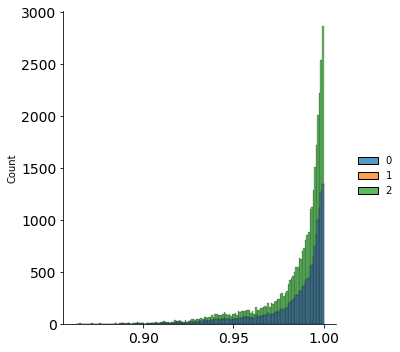

In [358]:
sns.displot([sim_inh,sim_exc,sim_inh_exc])

## significance test ETA

<Axes: >

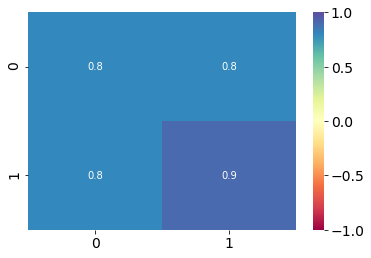

In [372]:
from sklearn.metrics.pairwise import cosine_similarity


cosine_mat = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        cosine_mat[i,j] = np.mean(cosine_similarity(normalize(np.vstack(df_temp[df_temp.labels_wave==i]['eta'].to_numpy())),
                  normalize(np.vstack(df_temp[df_temp.labels_wave==j]['eta'].to_numpy()))))

sns.heatmap(cosine_mat,vmax=1,vmin=-1,annot=True,cmap = 'Spectral')
# plt.savefig(savepath+'EI_similarity.pdf',dpi=200)

In [373]:
exc_eta  = normalize(np.vstack(df_biophys_exc['eta'].to_numpy()))
inh_eta  = normalize(np.vstack(df_biophys_inh['eta'].to_numpy()))


sim_inh = cosine_similarity(inh_eta,inh_eta)[np.triu_indices_from(cosine_similarity(inh_eta,inh_eta),k=1)]
sim_exc = cosine_similarity(exc_eta,exc_eta)[np.triu_indices_from(cosine_similarity(exc_eta,exc_eta),k=1)]
sim_inh_exc = cosine_similarity(exc_eta,inh_eta).reshape(1,-1)[0]

print(sm.stats.anova_oneway([sim_inh_exc,sim_exc,sim_inh]))

statistic = 2796.7762249757006
pvalue = 0.0
df = (2.0, 19349.411351075527)
df_num = 2.0
df_denom = 19349.411351075527
nobs_t = 46971.0
n_groups = 3
means = [0.7962029  0.90277313 0.79445963]
nobs = [22692. 16653.  7626.]
vars_ = [0.03644907 0.01378087 0.0385615 ]
use_var = unequal
welch_correction = True
tuple = (2796.7762249757006, 0.0)


In [374]:
games_howell(sim_inh,sim_exc,sim_inh_exc)

,mean_differences,degrees_freedom,t_values,p_values,std_err,up_conf,low_conf,group_comps
0,0.108314,10200.041337,44.654827,0.001,0.001715,3.423303,-3.206676,0 : 1
1,0.001743,12804.944032,0.675399,[0.7571669273532889],0.001825,3.316632,-3.313146,0 : 2
2,-0.106570,38257.169467,68.313372,0.001,0.001103,3.208059,-3.421199,1 : 2


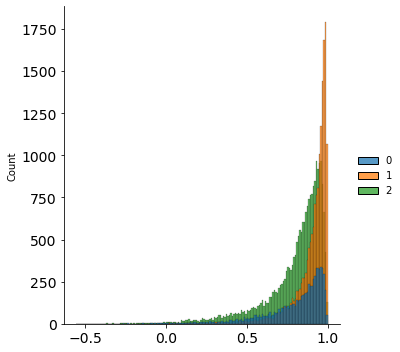

In [375]:
sns.displot([sim_inh,sim_exc,sim_inh_exc])

## MANOVA

In [25]:
df_temp.columns

Index(['tau_m (ms)', 'R (MOhm)', 'C (nF)', 'gl (nS)', 'El (mV)', 'Tref (ms)',
       'Vr (mV)', 'Vt* (mV)', 'DV (mV)', 'r_squared_V', 'r_squared_dV',
       'gamma', 'K', 'eta', 'gamma_threshold', 'cond', 'trial', 'exp_name',
       'labels_wave', 'lables_bio', 'type'],
      dtype='object')

In [26]:

df_temp.columns =  ['tau_m', 'R', 'C', 'gl', 'El', 'Tref',
       'Vr', 'Vt', 'DV', 'r_squared_V', 'r_squared_dV',
       'gamma', 'K', 'eta', 'gamma_threshold', 'cond', 'trial', 'exp_name',
       'labels_wave', 'lables_bio','type']

In [27]:
data_manova = df_temp
data_manova['type'] = data_manova['labels_wave'].map({0:'inh',1:'exc'})

from statsmodels.multivariate.manova import MANOVA
scaler = StandardScaler()
cols = ['C', 'gl', 'El', 'Vr', 'Vt', 'DV']

data_manova[cols] = scaler.fit_transform(normalize(data_manova[cols]))

# Apply MANOVA with the renamed columns
# manova = MANOVA.from_formula('C + gl + El + Vr + Vt + DV ~ type', data = data_manova)
# Y = XB^T+E

manova = MANOVA(endog=data_manova[cols].to_numpy(),
                exog=data_manova['labels_wave'].to_numpy())
result = manova.mv_test()
print(result)

                  Multivariate linear model
                                                             
-------------------------------------------------------------
           x0           Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.6722 6.0000 301.0000 24.4641 0.0000
         Pillai's trace 0.3278 6.0000 301.0000 24.4641 0.0000
 Hotelling-Lawley trace 0.4877 6.0000 301.0000 24.4641 0.0000
    Roy's greatest root 0.4877 6.0000 301.0000 24.4641 0.0000



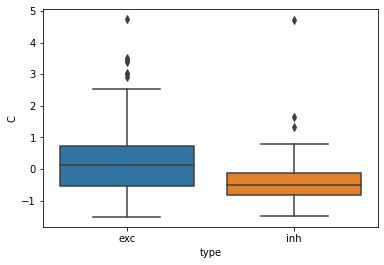

Ttest_indResult(statistic=6.416367638381892, pvalue=5.327716350253809e-10)


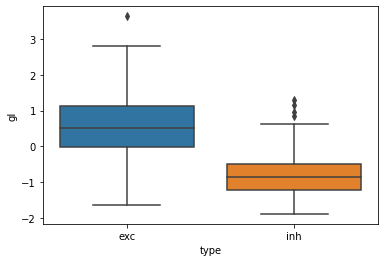

Ttest_indResult(statistic=15.44471421667694, pvalue=4.561341609290155e-40)


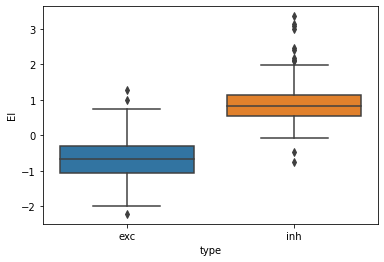

Ttest_indResult(statistic=-21.031579469029413, pvalue=4.632908847813203e-56)


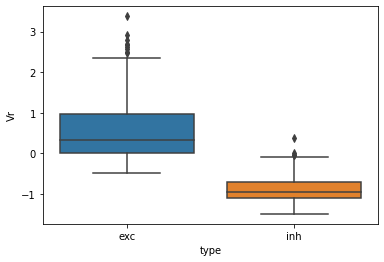

Ttest_indResult(statistic=21.703523225247583, pvalue=5.6391218651105266e-61)


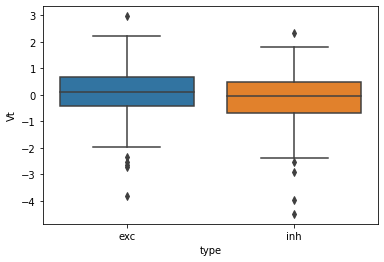

Ttest_indResult(statistic=2.2122771261216125, pvalue=0.027851350415999395)


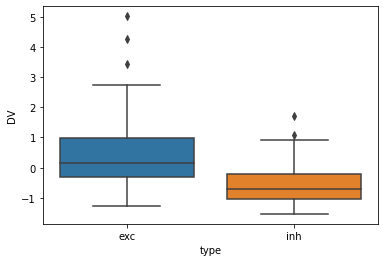

Ttest_indResult(statistic=10.6106375527857, pvalue=1.5709814558219063e-22)


In [31]:
from scipy.stats import ttest_ind
for i in ['C', 'gl', 'El', 'Vr', 'Vt', 'DV',]:
    sns.boxplot(data = data_manova,x='type',y=i)
    plt.show()
    rvs1 = data_manova[data_manova.type=='exc'][i]
    rvs2 = data_manova[data_manova.type=='inh'][i]

    print(ttest_ind(rvs1, rvs2, equal_var=False))


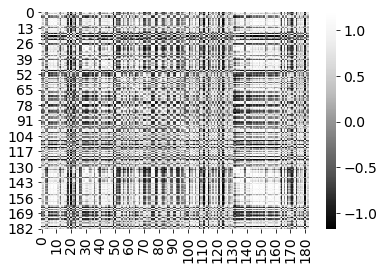

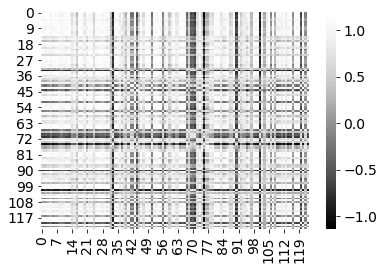

In [804]:
sns.heatmap(np.cov(data_manova[data_manova.type=='exc'][cols]),cmap='Greys_r')
plt.show()
sns.heatmap(np.cov(data_manova[data_manova.type=='inh'][cols]),cmap='Greys_r')
plt.show()

## CCA

CCA score:  -0.5579680953625284
CCA score:  -0.5902430501857064
CCA score:  -0.569885819666807
CCA score:  -0.5335243632109813
CCA score:  -0.9671745713677966
CCA score:  -0.5184040425570583
CCA score:  -0.585964786802776
CCA score:  -0.7834961319656202
CCA score:  -0.6929116200725343
CCA score:  -0.7515327379933714
-0.13362466903492243 0.13362466903492237


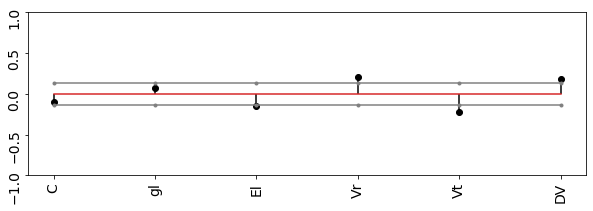

-0.23587713640393657 0.23587713640393657


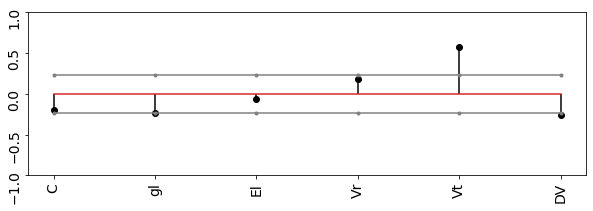

In [814]:

import numpy as np
from sklearn.cross_decomposition import CCA
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
scale = StandardScaler()
cols = ['C', 'gl', 'El', 'Vr', 'Vt', 'DV']

X_inh = data_manova[data_manova.type=='inh'][cols].to_numpy()
X_exc = data_manova[data_manova.type=='exc'][cols].to_numpy()

def perform_CCA(X,y,n_components=10):
    ca = CCA(n_components=n_components)
    ca.fit(X, y)
    X_c, Y_c = ca.transform(X,y)
    x_weights = ca.x_weights_
    score = ca.score(X , y)
    print('CCA score: ',score)
    return X_c,Y_c,ca

def return_ci(data,alpha):
    loadings  = data
    mean = np.mean(loadings)
    n = len(loadings)
    std = np.std(loadings)
    ci = (1.96)*(std/np.sqrt(n)) 
    print(mean - ci, mean + ci)
    return mean - ci, mean + ci

all_loadings_exc = []
all_loadings_inh = []

for i in range(10):

    _,_,ca_all_E_S = perform_CCA(X_inh,X_exc[np.random.randint(0,len(X_exc),len(X_inh))],n_components=len(cols))

    all_loadings_exc.append(ca_all_E_S.x_loadings_[:,1])
    all_loadings_inh.append(ca_all_E_S.x_loadings_[:,0])

plt.figure(figsize=[10,3])

loadings_exc = np.mean(np.vstack(all_loadings_exc),axis=0)
loadings_exc = loadings_exc -np.mean(loadings_exc)

loadings_inh = np.mean(np.vstack(all_loadings_inh),axis=0)
loadings_inh = loadings_inh -np.mean(loadings_inh)


ci_neg, ci_pos = return_ci(loadings_exc, alpha=0.05)
plt.stem(cols, loadings_exc,'black')
plt.tick_params(rotation=90)
plt.plot(np.repeat(ci_neg,len(cols)), c='grey', marker = '.')
plt.plot(np.repeat(ci_pos,len(cols)), c='grey', marker = '.')
plt.ylim(-1,1)
plt.savefig(savepath+'stem_bio_exc.pdf',dpi=200)
plt.show()

plt.figure(figsize=[10,3])
ci_neg, ci_pos = return_ci(loadings_inh, alpha=0.05)
plt.stem(cols, loadings_inh,'black')
plt.tick_params(rotation=90)
plt.plot(np.repeat(ci_neg,len(cols)),c='grey', marker = '.' )
plt.plot(np.repeat(ci_pos,len(cols)),c='grey', marker = '.' )
plt.ylim(-1,1)
plt.savefig(savepath+'stem_bio_inh.pdf',dpi=200)
plt.show()


# Spike Triggered Average

In [166]:
df_sta = pd.read_pickle('D:/CurrentClamp/all_stas_hidden_spikes_computed.pkl')
# df_sta = pd.read_pickle('D:/CurrentClamp/all_stas_normed_input.pkl')
# df_sta = pd.read_pickle('D:/CurrentClamp/all_stas_shifted.pkl')

df_sta.trial = df_sta.trial.apply(int)
df_sta = df_sta[~df_sta.exp_name.isin(discarded_exps)]
df_sta_acsf = df_sta[df_sta.cond.isin(['acsf','acsf_bic'])]

df_sta_acsf = df_sta_acsf[df_sta_acsf.exp_name.isin(set(data_wave_FN_acsf.exp_name))]
df_sta_acsf = df_sta_acsf[df_sta_acsf.trial==0]



In [174]:
df_sta_acsf['labels_wave'] =labels_wave 
df_sta_acsf_exc = df_sta_acsf[df_sta_acsf.labels_wave.isin([1,2,3,6,7])]
df_sta_acsf_inh = df_sta_acsf[df_sta_acsf.labels_wave.isin([0,4,5])]

In [162]:
df_sta_acsf.to_pickle('D:/Data For Publication/CCA/sta_with_labels.pkl')

In [181]:
# data_umap_scaler = StandardScaler()

# find_optimum_res(data_umap_scaler.fit_transform(normalize(np.vstack(df_sta_acsf_exc['sta'].to_numpy()))),save=True,savepath=savepath+'clsuter_stability_sta_exc.pdf')
# find_optimum_res(data_umap_scaler.fit_transform(normalize(np.vstack(df_sta_acsf_inh['sta'].to_numpy()))),save=True,savepath=savepath+'clsuter_stability_sta_inh.pdf')

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


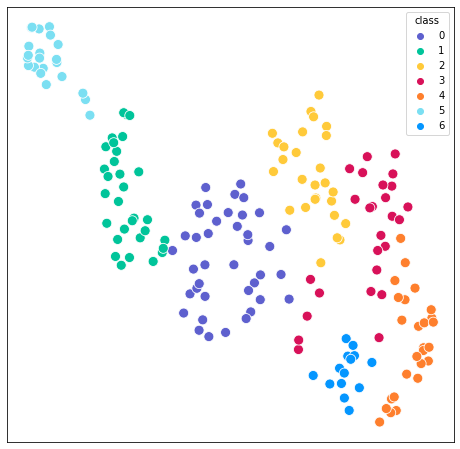

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


8


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


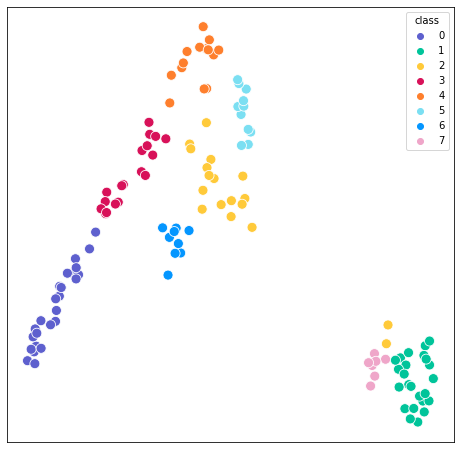

<ipython-input-188-e499b7fa012a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sta_acsf_exc['labels_sta'] =labels_sta_exc
<ipython-input-188-e499b7fa012a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sta_acsf_inh['labels_sta'] =labels_sta_inh


In [188]:
sta_exc = normalize(np.vstack(df_sta_acsf_exc['sta'].to_numpy()))
labels_sta_exc,mapper,reducer = plot_UMAP_clusters_single(sta_exc[:,],
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                        #   title='UMAP+Louvain for waveforms'
                          norm = False,
                          size= 100,
                          save=False,
                          savepath=savepath+'sta_cluster_exc.pdf'
                          )

sta_inh = normalize(np.vstack(df_sta_acsf_inh['sta'].to_numpy()))
labels_sta_inh,mapper,reducer = plot_UMAP_clusters_single(sta_inh[:,],
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                        #   title='UMAP+Louvain for waveforms'
                          norm = False,
                          size= 100,
                          save=False,
                          savepath=savepath+'sta_cluster_inh.pdf'
                          )

df_sta_acsf_exc['labels_sta'] =labels_sta_exc
df_sta_acsf_inh['labels_sta'] =labels_sta_inh

In [231]:
stas = normalize(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==1]['sta']))

exps = df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==1]['exp_name']

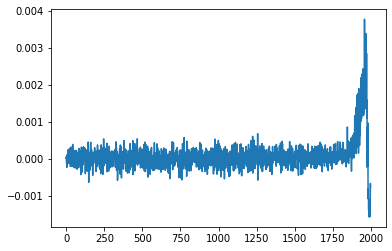

In [317]:
plt.plot(np.diff(sta_exc[134]))

In [275]:
from sklearn.metrics import auc
amps_exc = []
speed_exc = []
auc_exc = []
for sta in normalize(np.vstack(df_sta_acsf_exc['sta'].to_numpy())):
    # sta = np.mean(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta']).T,axis=1)[50*20:]
    amps_exc.append(np.max(sta))
    speed_exc.append(np.max(np.diff(sta,2)))
    auc_exc.append(auc(np.arange(-100,0,1/20),np.abs(sta)))

amps_inh = []
speed_inh = []
auc_inh = []
for sta in normalize(np.vstack(df_sta_acsf_inh['sta'].to_numpy())):
    # sta = np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:]
    amps_inh.append(np.max(sta))
    speed_inh.append(np.max(np.diff(sta,2)))
    auc_inh.append(auc(np.arange(-100,0,1/20),np.abs(sta)))



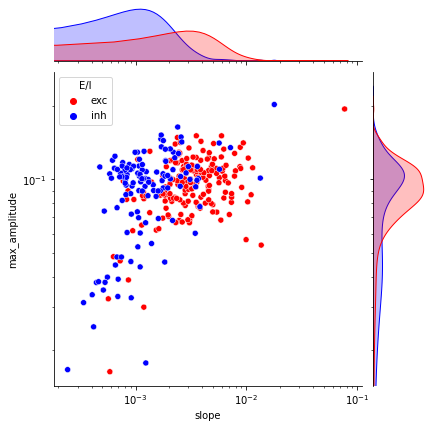

In [276]:
df_slope_amp = pd.DataFrame({'slope':np.concatenate([speed_exc,speed_inh]),
                   'max_amplitude':np.concatenate([amps_exc,amps_inh]),
                   'E/I':np.concatenate([np.repeat('exc',len(speed_exc)) , np.repeat('inh',len(speed_inh))])})

plt.rcParams.fontsize=14
# fig,ax = plt.subplots()
g = sns.jointplot(data=df_slope_amp, x="slope", y="max_amplitude", hue="E/I",palette=['red','blue'])
# ax.loglog()
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
# plt.savefig(savepath+'amp_slope_joint_plot.pdf',dpi=200)

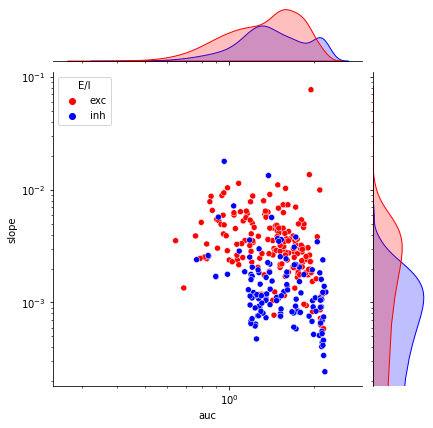

In [278]:
df_slope_amp = pd.DataFrame({'slope':np.concatenate([speed_exc,speed_inh]),
                   'max_amplitude':np.concatenate([amps_exc,amps_inh]),
                   'auc':np.concatenate([auc_exc,auc_inh]),
                   'E/I':np.concatenate([np.repeat('exc',len(speed_exc)) , np.repeat('inh',len(speed_inh))])})

plt.rcParams.fontsize=14
# fig,ax = plt.subplots()
g = sns.jointplot(data=df_slope_amp, x="auc", y="slope", hue="E/I",palette=['red','blue'])
# ax.loglog()
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')

In [279]:
from scipy import stats

print(stats.ttest_ind(df_slope_amp[df_slope_amp['E/I']=='exc']['slope'],df_slope_amp[df_slope_amp['E/I']=='inh']['slope'],equal_var=False))
print(stats.ttest_ind(df_slope_amp[df_slope_amp['E/I']=='exc']['max_amplitude'],df_slope_amp[df_slope_amp['E/I']=='inh']['max_amplitude'],equal_var=False))

print(stats.ttest_ind(df_slope_amp[df_slope_amp['E/I']=='exc']['auc'],df_slope_amp[df_slope_amp['E/I']=='inh']['auc'],equal_var=False))



Ttest_indResult(statistic=5.233298450587491, pvalue=3.539820800871851e-07)
Ttest_indResult(statistic=0.948192887596497, pvalue=0.34412778247027354)
Ttest_indResult(statistic=-2.05345058254112, pvalue=0.041054157858430196)


In [181]:
df_sta_temp = df_sta_acsf
df_sta_temp['labels_wave'] = binarize_EI_labels(labels_wave,e_vals =[1,2,3,6,7])

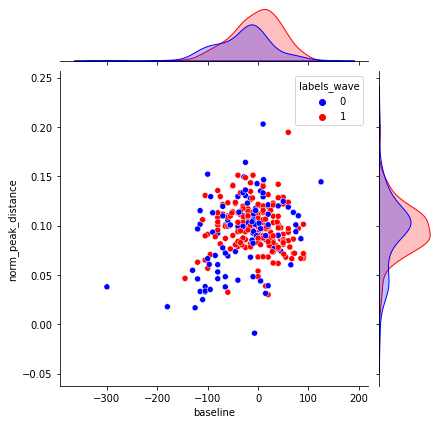

In [187]:


df_sta_temp['baseline'] = np.float32(df_sta_temp['baseline'].to_numpy()) 
df_sta_temp['peak_distance'] = np.float32(df_sta_temp['norm_peak_distance'].to_numpy()) 
# df_sta_temp['peak_calculated'] = np.float32(df_sta_temp['peak_calculated'].to_numpy()) 

sns.jointplot(data=df_sta_temp, x="baseline", y="norm_peak_distance", hue="labels_wave",palette=['blue','red'],marginal_ticks=False)
plt.xlabel('baseline',fontsize=14)
plt.ylabel('peak_calculated',fontsize=14)

plt.savefig(savepath+'baseline_vs_peak.pdf',dpi=200)


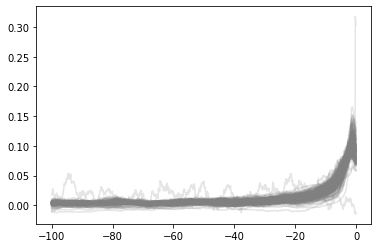

In [60]:
plt.plot(np.arange(-100,0,1/20), normalize(np.vstack(df_sta_acsf_exc['sta'])).T[:],c='grey',alpha=0.2)
plt.show()

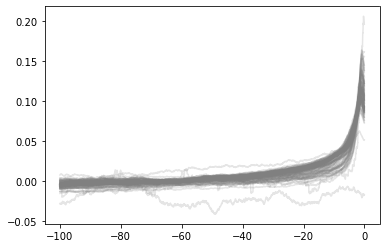

In [61]:
plt.plot(np.arange(-100,0,1/20), normalize(np.vstack(df_sta_acsf_inh['sta'])).T[:],c='grey',alpha=0.2)
plt.show()

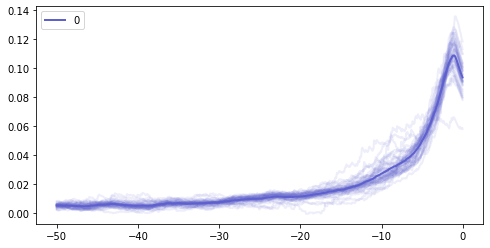

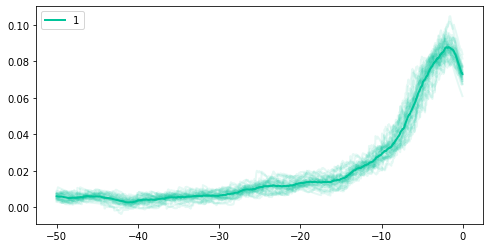

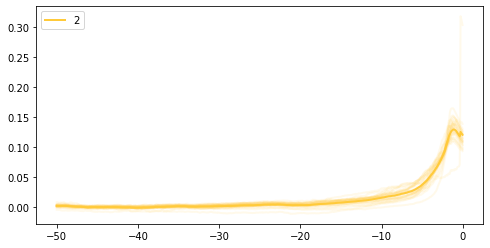

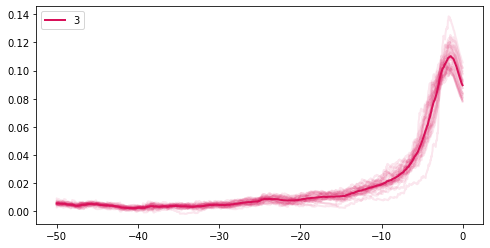

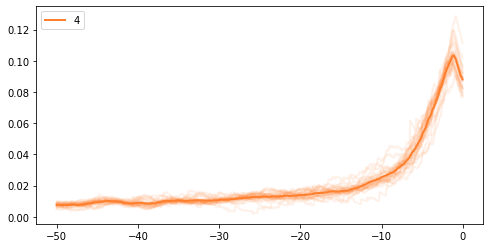

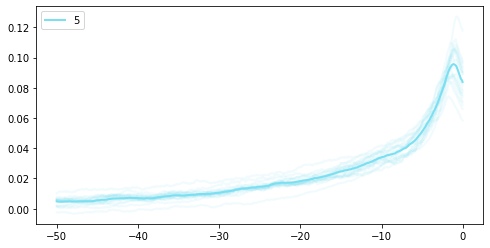

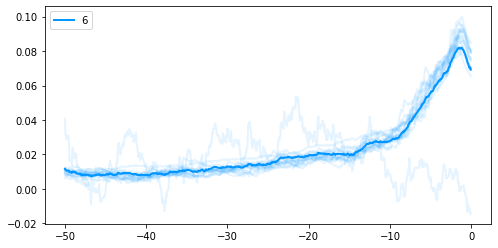

In [62]:
for i in set(df_sta_acsf_exc.labels_sta):
    fig,ax = plt.subplots(figsize=[8,4])
    plt.plot(np.arange(-50,0,1/20),normalize(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta'])).T[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,alpha=0.1)
    plt.plot(np.arange(-50,0,1/20),np.mean(normalize(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta'])).T,axis=1)[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
    plt.legend()
    plt.show()

# for i in set(df_sta_acsf_inh.labels_sta):
#     plt.plot(np.arange(0,50,1/20),np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:],c=coherence_colors[i],linewidth=2,label=i)
# plt.legend()    
# plt.show()

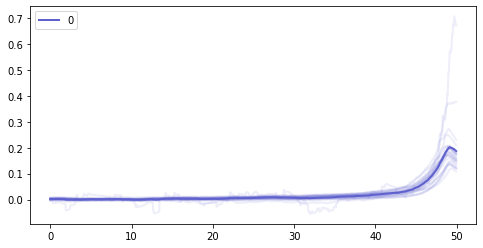

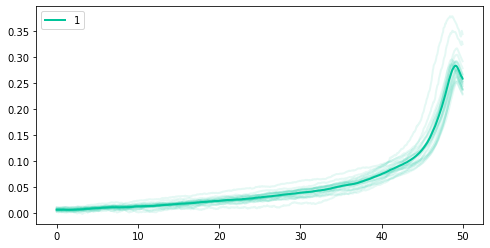

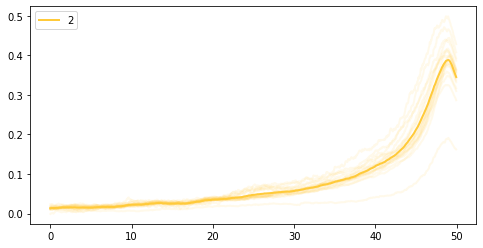

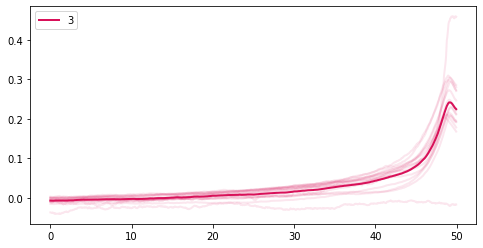

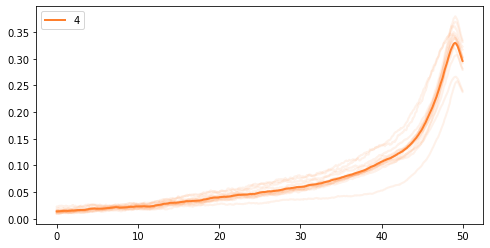

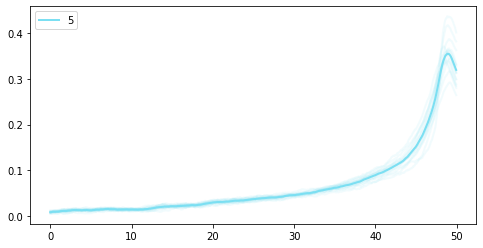

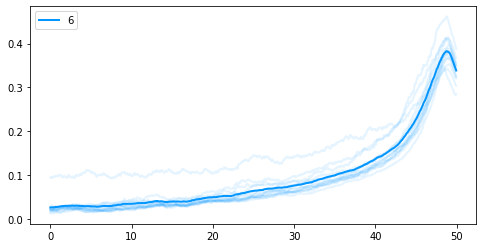

In [63]:
for i in set(df_sta_acsf_inh.labels_sta):
    fig,ax = plt.subplots(figsize=[8,4])
    plt.plot(np.arange(0,50,1/20),np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,alpha=0.1)
    plt.plot(np.arange(0,50,1/20),np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
    plt.legend()
    plt.show()

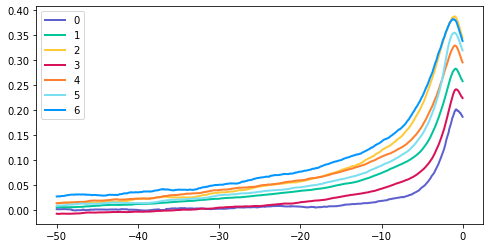

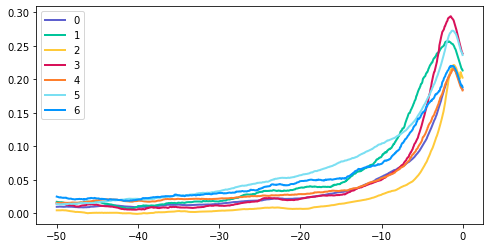

In [64]:
fig,ax = plt.subplots(figsize=[8,4])
for i in set(df_sta_acsf_inh.labels_sta):
    
    plt.plot(np.arange(-50,0,1/20),np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[-50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
# plt.ylim(-0.1,0.15)
plt.legend()
# plt.savefig(savepath+'sta_inh_50ms.pdf',dpi=200)
# plt.show()

fig,ax = plt.subplots(figsize=[8,4])
for i in set(df_sta_acsf_exc.labels_sta):
    plt.plot(np.arange(-50,0,1/20),np.mean(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta']).T,axis=1)[-50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
# plt.ylim(-0.1,0.15)
plt.legend()
# plt.savefig(savepath+'sta_exc_10ms.pdf',dpi=200)
# plt.show()

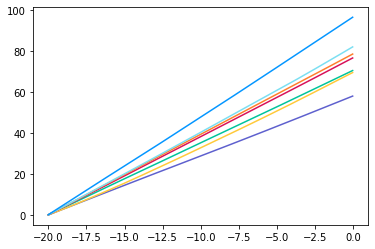

In [65]:
for  i in range(len(set(df_sta_acsf_exc.labels_sta))):
    data = normalize(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta']).T)
    plt.plot(np.arange(-20,0,1/20),np.cumsum(np.mean(data,axis=1)[-20*20:], axis=0, dtype=None, out=None),c=CUSTOM_PAL_SORT_3[i])
plt.savefig(savepath+'cumsum_exc_sta.pdf',dpi=200)

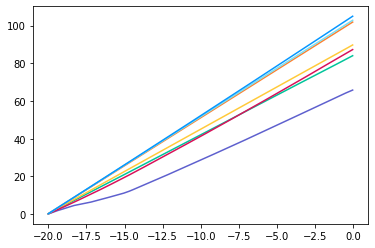

In [66]:
for  i in range(len(set(df_sta_acsf_inh.labels_sta))):
    data = normalize(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T)
    plt.plot(np.arange(-20,0,1/20),np.cumsum(np.mean(data,axis=1)[-20*20:], axis=0, dtype=None, out=None),c=CUSTOM_PAL_SORT_3[i])
plt.savefig(savepath+'cumsum_inh_sta.pdf',dpi=200)    

## significance test

In [328]:
from sklearn.metrics.pairwise import cosine_similarity

In [329]:
sta_exc = np.vstack(df_sta_acsf_exc['sta'])[-50*20:,:]
sta_inh = np.vstack(df_sta_acsf_inh['sta'])[-50*20:,:]

cosine_mat = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        if i ==0:
            data1 = sta_exc
            if j == 0:
                data2 = sta_exc
            else:
                data2 = sta_inh
        else:
            data1 = sta_inh
            if j == 0:
                data2 = sta_exc
            else:
                data2 = sta_inh            
        cosine_mat[i,j] = np.mean(cosine_similarity(data1,data2))


<Axes: >

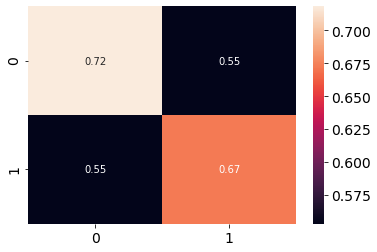

In [330]:
sns.heatmap(cosine_mat,annot=True)

In [332]:
data1 = cosine_similarity(sta_exc,sta_exc)[np.triu_indices_from(cosine_similarity(sta_exc,sta_exc))]
data2 = cosine_similarity(sta_inh,sta_inh)[np.triu_indices_from(cosine_similarity(sta_inh,sta_inh))]
data3 = cosine_similarity(sta_inh,sta_exc).reshape(1,-1)[0]
print(calcualte_cosine_sig(data1,data2,data3))

statistic = 1005.9034392076701
pvalue = 0.0
df = (2.0, 23121.78654346833)
df_num = 2.0
df_denom = 23121.78654346833
nobs_t = 48828.0
n_groups = 3
means = [0.71970767 0.674678   0.55311763]
nobs = [17391.  8001. 23436.]
vars_ = [0.11776403 0.11175403 0.17558281]
use_var = unequal
welch_correction = True
tuple = (1005.9034392076701, 0.0)


In [377]:
games_howell(data1,data2,data3)      

,mean_differences,degrees_freedom,t_values,p_values,std_err,up_conf,low_conf,group_comps
0,0.162936,9161.539599,65.313586,0.001,0.001764,3.477981,-3.152109,0 : 1
1,-0.054958,16398.682442,18.687064,0.001,0.002080,3.259845,-3.369761,0 : 2
2,-0.217894,29917.632997,120.768449,0.001,0.001276,3.096771,-3.532560,1 : 2


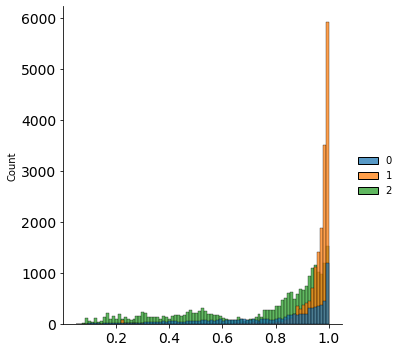

In [378]:
sns.displot([data1,data2,data3])

## STA Comparisons

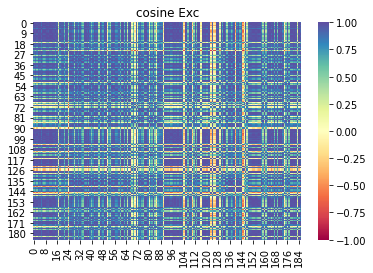

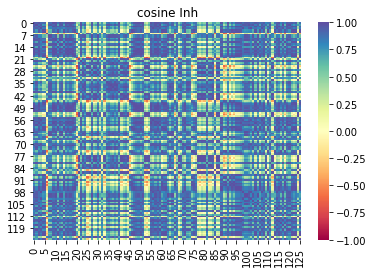

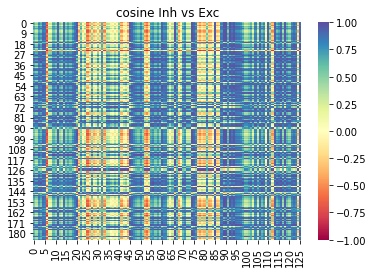

In [224]:

sns.heatmap(cosine_similarity(wave_exc,wave_exc),cmap='Spectral',vmax=1,vmin=-1)
plt.title('cosine Exc')
plt.savefig(savepath+'cosine_exc.pdf',dpi=200)
plt.show()
sns.heatmap(cosine_similarity(wave_inh,wave_inh),cmap='Spectral',vmax=1,vmin=-1)
plt.title('cosine Inh') 
plt.savefig(savepath+'cosine_inh.pdf',dpi=200)
plt.show()
sns.heatmap(cosine_similarity(wave_exc,wave_inh),cmap='Spectral',vmax=1,vmin=-1)
plt.title('cosine Inh vs Exc') 
plt.savefig(savepath+'cosine_exc_inh.pdf',dpi=200)
plt.show()


<Axes: >

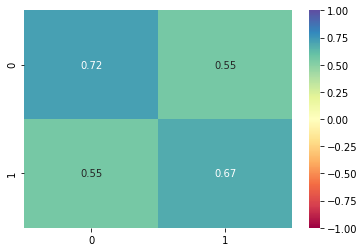

In [218]:
sns.heatmap(cosine_mat,vmax=1,vmin=-1,annot=True,cmap='Spectral')

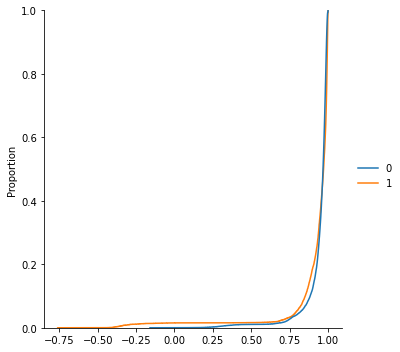

In [74]:
sns.displot([np.hstack(cosine_similarity(wave_exc,wave_exc)),np.hstack(cosine_similarity(wave_inh,wave_inh))],kind='ecdf')


In [32]:
amps_exc = []
acceleration_exc = []

for sta in np.vstack(df_sta_acsf_exc['sta']):
    # sta = np.mean(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta']).T,axis=1)[50*20:]
    amps_exc.append(np.max(sta))
    acceleration_exc.append(np.max(np.diff(sta,1)))



amps_inh = []
acceleration_inh = []
for sta in np.vstack(df_sta_acsf_inh['sta']):
    # sta = np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:]
    amps_inh.append(np.max(sta))
    acceleration_inh.append(np.max(np.diff(sta,1)))



In [67]:
df_slope_amp = pd.DataFrame({'slope':np.concatenate([acceleration_exc,acceleration_inh]),
                   'max_amplitude':np.concatenate([amps_exc,amps_inh]),
                   'E/I':np.concatenate([np.repeat('exc',len(acceleration_exc)) , np.repeat('inh',len(acceleration_inh))])})

plt.rcParams.fontsize=14

sns.jointplot(data=df_slope_amp, x="slope", y="max_amplitude", hue="E/I",palette=['blue','red'])


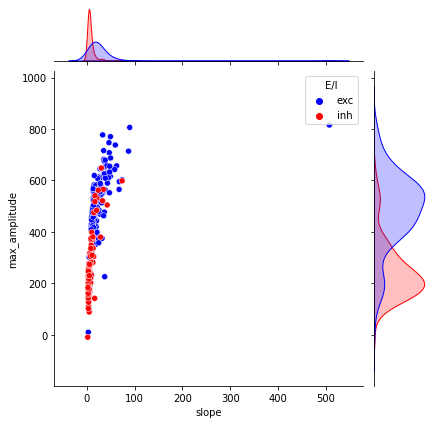

In [145]:
df_sta_comparison = pd.read_pickle('D:/CurrentClamp/all_stas_for_baseline_vs_amp.pkl')
df_sta_comparison.trial = df_sta_comparison.trial.apply(int)
df_sta_comparison = df_sta_comparison[~df_sta_comparison.exp_name.isin(discarded_exps)]
df_sta_acsf_comparison = df_sta_comparison[df_sta_comparison.cond.isin(['acsf','acsf_bic'])]
df_sta_acsf_comparison = df_sta_acsf_comparison[df_sta_acsf_comparison.exp_name.isin(set(data_wave_FN_acsf.exp_name))]
df_sta_acsf_comparison = df_sta_acsf_comparison[df_sta_acsf_comparison.trial==0]


In [149]:
df_sta['baseline'] = df_sta_comparison['baseline']

In [132]:
df_sta_acsf_comparison['labels_wave'] = binarize_EI_labels(labels_wave,e_vals=[1,2,3,6,7]) 

df_sta_acsf_exc = df_sta_acsf_comparison[df_sta_acsf_comparison.labels_wave.isin([1,2,3,6,7])]
df_sta_acsf_inh = df_sta_acsf_comparison[df_sta_acsf_comparison.labels_wave.isin([0,4,5])]

,sta,cond,exp_name,trial,baseline
0,"[-29.136803, -28.914057, -28.866486, -29.03143...",acsf,asli_18719_E2,0,-14
1,"[-32.869057, -33.12753, -33.20921, -33.50037, ...",m1-ago,asli_18719_E2,1,-19
2,"[-38.50977, -38.67939, -38.813385, -39.27503, ...",m1-ant,asli_18719_E2,2,-24
3,"[86.70841, 86.39632, 85.40984, 88.23137, 91.31...",acsf,asli_11719_E1,0,55
4,"[63.68802, 63.43242, 63.18577, 64.41218, 61.43...",m1-ago,asli_11719_E1,1,38
...,...,...,...,...,...
835,"[-108.715836, -108.300224, -108.20681, -108.06...",cirazoline,xuan_9919_E3,1,-50
836,"[-122.256165, -121.501526, -121.25651, -120.79...",agoanta,xuan_9919_E3,2,-65
837,"[-7.214985, -7.0553594, -7.281143, -6.8065333,...",acsf,xuan_9919_E4,0,2
838,"[-21.94919, -22.162203, -22.186674, -22.125116...",cirazoline,xuan_9919_E4,1,-10


In [136]:
df_sta['baseline'] = df_sta_acsf_comparison['baseline']

In [137]:
sta_norms_exc = normalize(np.vstack(df_sta_acsf_exc['sta'].to_numpy()))
peaks_exc = [np.max(i) for i in sta_norms_exc]

sta_norms_inh = normalize(np.vstack(df_sta_acsf_inh['sta'].to_numpy()))
peaks_inh = [np.max(i) for i in sta_norms_inh]


In [138]:
df_sta_acsf = df_sta_acsf.sort_values('labels_wave')
df_sta_acsf['peak_calculated'] = np.concatenate([peaks_inh,peaks_exc])

In [139]:
# plt.scatter(np.array(df_sta_acsf_exc['baseline']), np.array(df_sta_acsf_exc['peak_distance']))
# np.array(df_sta_acsf_exc['baseline'])
# plt.scatter(np.float32(np.array(df_sta_acsf_exc['baseline'])) , np.float32(np.array(df_sta_acsf_exc['peak_distance'])),alpha=0.5,c='red')
# plt.scatter(np.float32(np.array(df_sta_acsf_inh['baseline'])) , np.float32(np.array(df_sta_acsf_inh['peak_distance'])),alpha=0.5,c='blue')
# plt.xlabel('baseline')
# plt.ylabel('peak_distance')
# plt.legend(['exc','inh'])
# plt.show()
df_sta_acsf['baseline'] = np.float32(df_sta_acsf['baseline'].to_numpy()) 
df_sta_acsf['peak_distance'] = np.float32(df_sta_acsf['peak_distance'].to_numpy()) 
df_sta_acsf['peak_calculated'] = np.float32(df_sta_acsf['peak_calculated'].to_numpy()) 

sns.jointplot(data=df_sta_acsf, x="baseline", y="peak_calculated", hue="labels_wave",palette=['blue','red'],marginal_ticks=False)
plt.xlabel('baseline',fontsize=14)
plt.ylabel('peak_calculated',fontsize=14)
# plt.legend(['exc','inh'])
# plt.savefig(savepath+'baseline_vs_peak.pdf',dpi=200)
plt.show()
# np.float32(df_sta_acsf_exc['peak_distance'].to_numpy())

KeyError: 'baseline'

In [75]:
df_sta = pd.read_pickle('D:/CurrentClamp/all_stas_fleur.pkl')
df_sta.trial = df_sta.trial.apply(int)
df_sta = df_sta[~df_sta.exp_name.isin(discarded_exps)]
df_sta_acsf = df_sta[df_sta.cond.isin(['acsf','acsf_bic'])]

df_sta_acsf = df_sta_acsf[df_sta_acsf.exp_name.isin(set(data_wave_FN_acsf.exp_name))]
df_sta_acsf = df_sta_acsf[df_sta_acsf.trial==0]



In [76]:
df_sta_acsf['labels_wave'] =labels_wave 
df_sta_acsf_exc = df_sta_acsf[df_sta_acsf.labels_wave.isin([1,2,3,6,7])]
df_sta_acsf_inh = df_sta_acsf[df_sta_acsf.labels_wave.isin([0,4,5])]

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


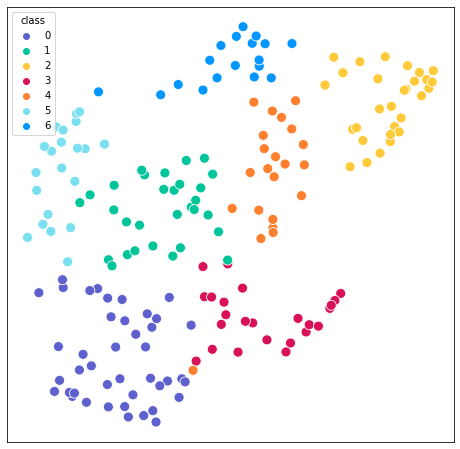

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


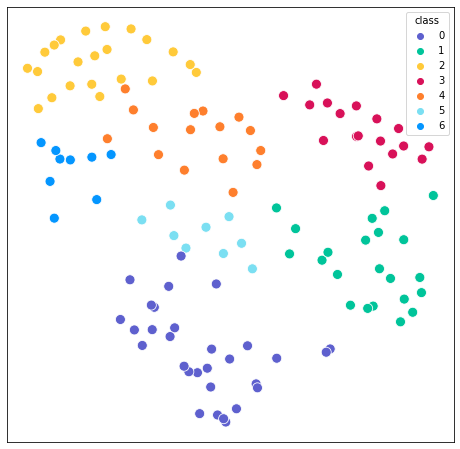

<ipython-input-77-81579ff23db0>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sta_acsf_exc['labels_sta'] =labels_sta_exc
<ipython-input-77-81579ff23db0>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sta_acsf_inh['labels_sta'] =labels_sta_inh


In [77]:
sta_exc = normalize(np.vstack(df_sta_acsf_exc['sta'].to_numpy()))
labels_sta_exc,mapper,reducer = plot_UMAP_clusters_single(sta_exc,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                        #   title='UMAP+Louvain for waveforms'
                          norm = False,
                          size= 100,
                          save=False,
                          savepath=savepath+'sta_cluster_exc.pdf'
                          )

sta_inh = normalize(np.vstack(df_sta_acsf_inh['sta'].to_numpy()))
labels_sta_inh,mapper,reducer = plot_UMAP_clusters_single(sta_inh,
                          20,
                          0.1,
                          random_state =30,
                          res_louvain = 1.,
                          c_list =CUSTOM_PAL_SORT_3,
                        #   title='UMAP+Louvain for waveforms'
                          norm = False,
                          size= 100,
                          save=False,
                          savepath=savepath+'sta_cluster_inh.pdf'
                          )

df_sta_acsf_exc['labels_sta'] =labels_sta_exc
df_sta_acsf_inh['labels_sta'] =labels_sta_inh

In [78]:
stas = np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==1]['sta'])
exps = df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==1]['exp_name']

In [79]:
amps_exc = []
acceleration_exc = []

for sta in np.vstack(df_sta_acsf_exc['sta']):
    # sta = np.mean(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta']).T,axis=1)[50*20:]
    amps_exc.append(np.max(sta))
    acceleration_exc.append(np.max(np.diff(sta,1)))



amps_inh = []
acceleration_inh = []
for sta in np.vstack(df_sta_acsf_inh['sta']):
    # sta = np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:]
    amps_inh.append(np.max(sta))
    acceleration_inh.append(np.max(np.diff(sta,1)))



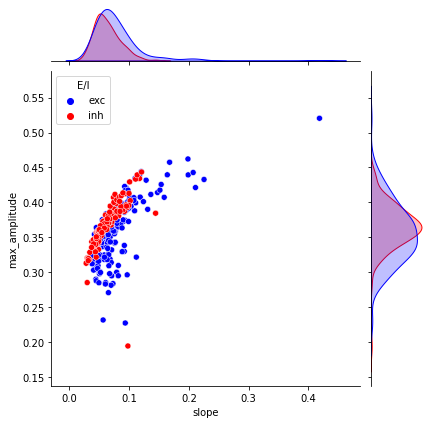

In [81]:
df_slope_amp = pd.DataFrame({'slope':np.concatenate([acceleration_exc,acceleration_inh]),
                   'max_amplitude':np.concatenate([amps_exc,amps_inh]),
                   'E/I':np.concatenate([np.repeat('exc',len(acceleration_exc)) , np.repeat('inh',len(acceleration_inh))])})

plt.rcParams.fontsize=14

sns.jointplot(data=df_slope_amp, x="slope", y="max_amplitude", hue="E/I",palette=['blue','red'])


In [139]:
len(np.vstack(df_sta_acsf_exc['sta'])[0])/20

5.55

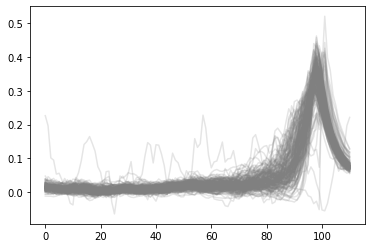

In [136]:
plt.plot( np.vstack(df_sta_acsf_exc['sta'].to_numpy()).T,c='grey',alpha=0.2)
plt.show()

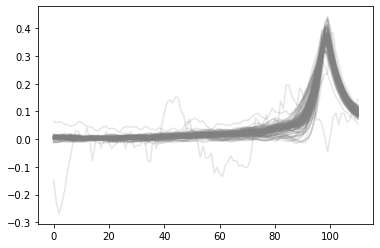

In [125]:
plt.plot(normalize(np.vstack(df_sta_acsf_inh['sta'])).T[:],c='grey',alpha=0.2)
plt.show()

In [ ]:
for i in set(df_sta_acsf_exc.labels_sta):
    fig,ax = plt.subplots(figsize=[8,4])
    plt.plot(np.arange(-50,0,1/20),normalize(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta'])).T[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,alpha=0.1)
    plt.plot(np.arange(-50,0,1/20),np.mean(normalize(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta'])).T,axis=1)[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
    plt.legend()
    plt.show()

# for i in set(df_sta_acsf_inh.labels_sta):
#     plt.plot(np.arange(0,50,1/20),np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:],c=coherence_colors[i],linewidth=2,label=i)
# plt.legend()    
# plt.show()

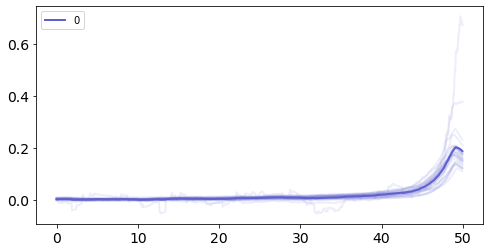

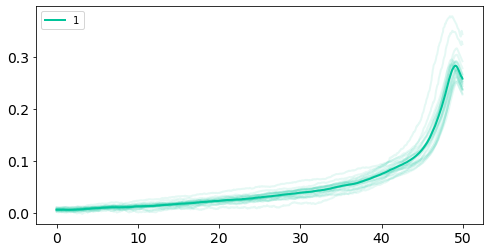

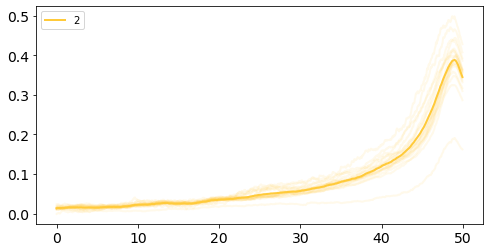

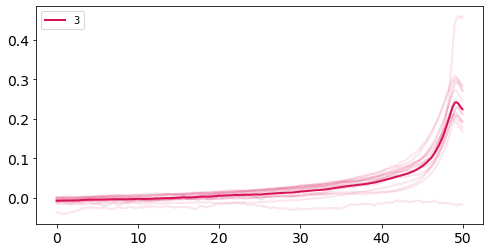

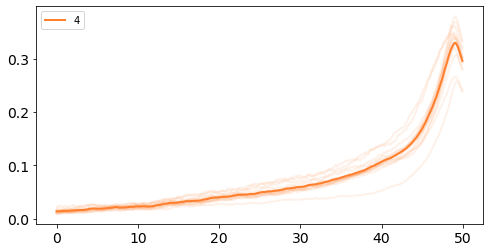

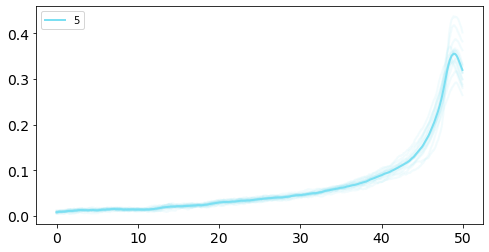

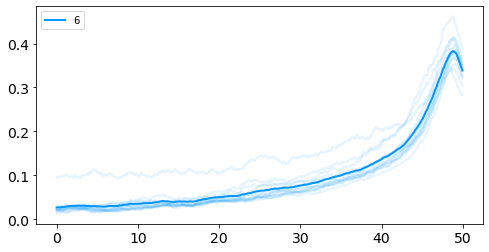

In [93]:
for i in set(df_sta_acsf_inh.labels_sta):
    fig,ax = plt.subplots(figsize=[8,4])
    plt.plot(np.arange(0,50,1/20),np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,alpha=0.1)
    plt.plot(np.arange(0,50,1/20),np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
    plt.legend()
    plt.show()

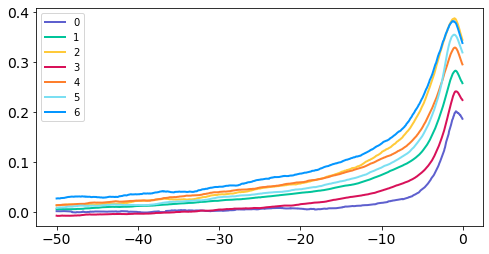

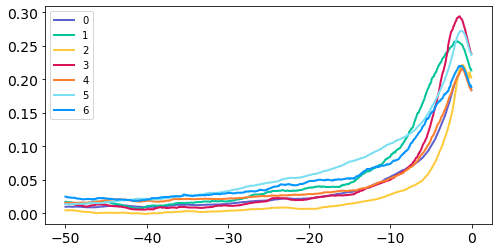

In [95]:
fig,ax = plt.subplots(figsize=[8,4])
for i in set(df_sta_acsf_inh.labels_sta):
    
    plt.plot(np.arange(-50,0,1/20),np.mean(np.vstack(df_sta_acsf_inh[df_sta_acsf_inh.labels_sta==i]['sta']).T,axis=1)[-50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
# plt.ylim(-0.1,0.15)
plt.legend()
# plt.savefig(savepath+'sta_inh_50ms.pdf',dpi=200)
# plt.show()

fig,ax = plt.subplots(figsize=[8,4])
for i in set(df_sta_acsf_exc.labels_sta):
    plt.plot(np.arange(-50,0,1/20),np.mean(np.vstack(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['sta']).T,axis=1)[-50*20:],c=CUSTOM_PAL_SORT_3[i],linewidth=2,label=i)
# plt.ylim(-0.1,0.15)
plt.legend()
# plt.savefig(savepath+'sta_exc_10ms.pdf',dpi=200)
# plt.show()

In [129]:
from sklearn.metrics.pairwise import cosine_similarity


In [97]:
def plot_cosine_mat(data1,data2,label1,label2):
    cosine_mat = np.zeros((len(set(label1)),len(set(label2))))
    sim_data = cosine_similarity(data1,data2)
    for i in set(label1):
        for j in set(label2):
            idx_FN = label1==i
            idx_SH = label2==j
            cosine_mat[i,j] = np.mean(sim_data[:,idx_FN][idx_SH])
    return cosine_mat
data1 = normalize(np.vstack(df_sta_acsf_inh['sta']))
data2 = normalize(np.vstack(df_sta_acsf_exc['sta']))
cosine_mat_inh = np.around(plot_cosine_mat(data1,data1,df_sta_acsf_inh.labels_sta,df_sta_acsf_inh.labels_sta),decimals=2)
cosine_mat_exc = np.around(plot_cosine_mat(data2,data2,df_sta_acsf_exc.labels_sta,df_sta_acsf_exc.labels_sta),decimals=2)


<Axes: >

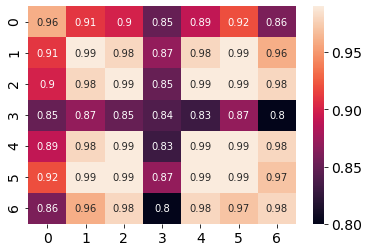

In [98]:
sns.heatmap(np.around(cos,decimals=2),annot=True)

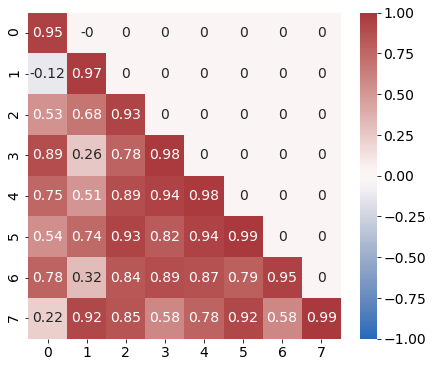

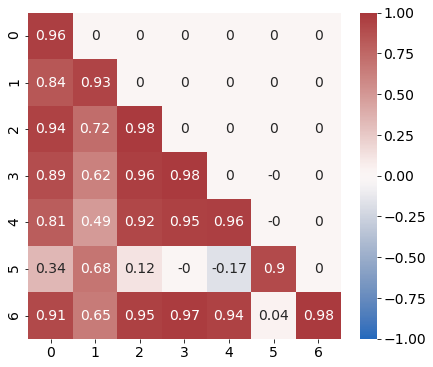

In [ ]:
plt.rcParams['font.size'] =14
fig,ax = plt.subplots(figsize=[7,6])
sns.heatmap(cosine_mat_inh*np.tril(np.ones_like(cosine_mat_inh)),cmap='vlag',vmin=-1,vmax=1,annot=True,ax=ax)
plt.savefig(savepath+'sta_cosine_inh.pdf',dpi=200)
plt.show()
fig,ax = plt.subplots(figsize=[7,6])

sns.heatmap(cosine_mat_exc*np.tril(np.ones_like(cosine_mat_exc)),cmap='vlag',vmin=-1,vmax=1,annot=True,ax=ax)
plt.savefig(savepath+'sta_cosine_exc.pdf',dpi=200)
plt.show()

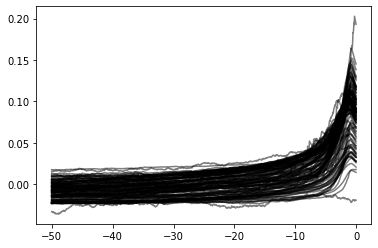

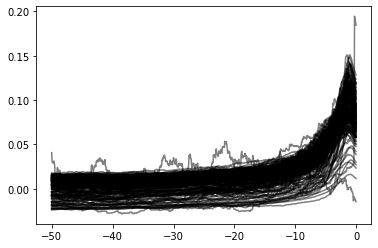

In [72]:
plt.plot(np.arange(-50,0,1/20),wave_inh.T[-50*20:,:],c='black',alpha=0.5)
plt.show()
plt.plot(np.arange(-50,0,1/20),wave_exc.T[-50*20:,:],c='black',alpha=0.5)
plt.show()

In [82]:
wave_exc = np.vstack(df_sta_acsf_exc['sta'])
wave_inh = np.vstack(df_sta_acsf_inh['sta'])

cosine_mat = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        if i ==0:
            data1 = wave_exc
            if j == 0:
                data2 = wave_exc
            else:
                data2 = wave_inh
        else:
            data1 = wave_inh
            if j == 0:
                data2 = wave_exc
            else:
                data2 = wave_inh            
        cosine_mat[i,j] = np.mean(cosine_similarity(data1,data2))


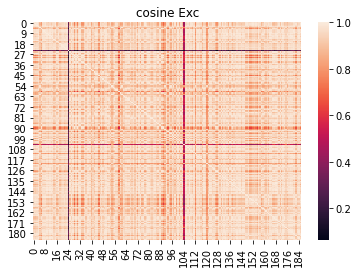

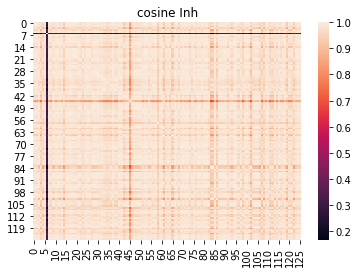

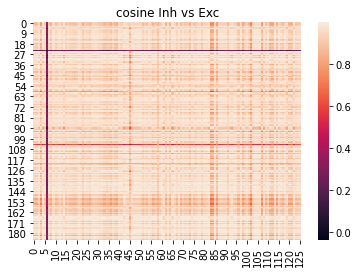

In [84]:

sns.heatmap(cosine_similarity(wave_exc,wave_exc),cmap=)
plt.title('cosine Exc')
plt.show()
sns.heatmap(cosine_similarity(wave_inh,wave_inh))
plt.title('cosine Inh') 

plt.show()
sns.heatmap(cosine_similarity(wave_exc,wave_inh))
plt.title('cosine Inh vs Exc') 

plt.show()

<Axes: >

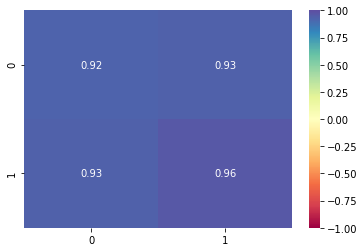

In [83]:
sns.heatmap(cosine_mat,vmax=1,vmin=-1,annot=True,cmap='Spectral')

# plt.savefig(savepath+'sta_EI_similarity_normalize_input.pdf',dpi=200)

In [163]:
len(np.concatenate([np.repeat('exc',len(np.hstack(cosine_similarity(wave_exc,wave_exc)))),np.repeat('inh',len(np.hstack(cosine_similarity(wave_inh,wave_inh))))]))

50472

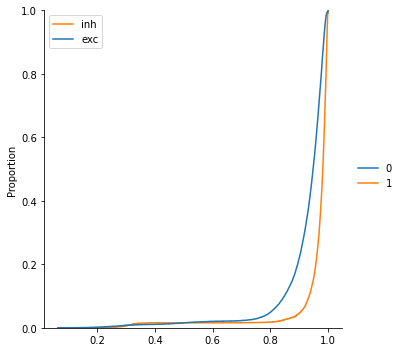

In [89]:

sns.displot([np.hstack(cosine_similarity(wave_exc,wave_exc)),np.hstack(cosine_similarity(wave_inh,wave_inh))],kind='ecdf')
plt.legend(['inh','exc'])

In [ ]:
wave_exc = normalize(np.vstack(ephys_exc[cols].to_numpy()))
wave_inh = normalize(np.vstack(ephys_inh[cols].to_numpy()))

cosine_mat = np.zeros((2,2))
for i,type_i in enumerate(['exc','inh']):
    for j,type_j in enumerate(['exc','inh']):
        if type_i =='exc':
            data1 = wave_exc
            if type_j == 'exc':
                data2 = wave_exc
            else:
                data2 = wave_inh
        elif type_i =='inh':
            data1 = wave_inh
            if type_j == 'inh':
                data2 = wave_inh
            else:
                data2 = wave_exc            
        cosine_mat[i,j] = np.mean(cosine_similarity(data1,data2))


In [ ]:
np.mean(cosine_similarity(wave_inh,wave_inh))

0.796117209037501

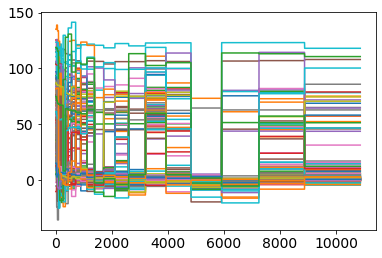

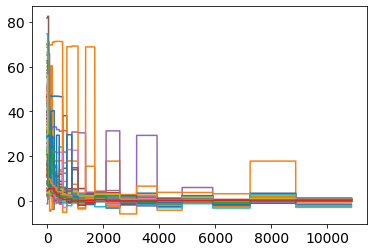

In [ ]:
plt.plot(np.vstack(df_biophys_exc['gamma_threshold'].to_numpy()).T)
plt.show()

plt.plot(np.vstack(df_biophys_inh['gamma_threshold'].to_numpy()).T)
plt.show()


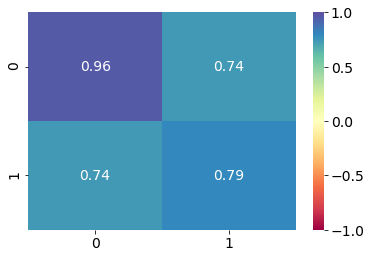

In [ ]:
sns.heatmap(cosine_mat,vmax=1,vmin=-1,annot=True,cmap='Spectral')
plt.savefig(savepath+'ephys_EI_comparison.pdf',dpi=200)

# Labels Matching 

In [ ]:
import pandas as pd 
def return_confusion_matrix_temp(df1,df2,label1_name,label2_name,vmin=0,vmax=100,figsize =[12,5],shuffle = False,save=False,savepath=None,palette='BrBG_r'):
    np.random.seed(42)
    if shuffle:
        fig,ax1 = plt.subplots(figsize =figsize )
        df = pd.DataFrame(columns=['label1','label2'])
        # df['exp_name1'] = df1.exp_name
        # df['exp_name2'] = df2.exp_name
        
        label1 = list(df1[label1_name])
        np.random.shuffle(label1)
        label2 = list(df2[label2_name])
        np.random.shuffle(label2)

        df['label1_sh'] = label1
        df['label2_sh'] = label2

        df['label1'] = np.array(df1[label1_name]) 
        df['label2'] = np.array(df2[label2_name])

        mat_orig = np.zeros((len(set(df1[label1_name])),len(set(df2[label2_name]))))
        for i in np.unique(df.label1):
            data_ = np.unique(df[df.label1==i]['label2'],return_counts=True)
            mat_orig[i,data_[0]] =(data_[1]/np.sum(data_[1])) 

        mat_sh = np.zeros((len(set(df['label1_sh'])),len(set(df['label2_sh']))))
        mat_sh[:,:] = int(100/len(set(df2[label2_name])))
        # for i in np.unique(df.label1_sh):
        #     data_ = np.unique(df[df.label1_sh==i]['label2_sh'],return_counts=True)
        #     mat_sh[i,data_[0]] =(data_[1]/np.sum(data_[1]))*100 


        sns.heatmap(np.around(mat_orig,2),cmap=palette,annot=True,ax=ax1,vmin=vmin,vmax=vmax) 
        plt.xlabel(label1_name)
        plt.ylabel(label2_name)
        if save:
            plt.savefig(savepath,dpi=300)
        else:
            plt.show()

    else:
        df = pd.DataFrame(columns=['label1','label2'])
        # df['exp_name1'] = df1.exp_name
        # df['exp_name2'] = df2.exp_name
        df['label1'] = np.array(df1[label1_name])
        df['label2'] = np.array(df2[label2_name])

        mat = np.zeros((len(set(df1[label1_name])),len(set(df2[label2_name]))))

        for i in np.unique(df.label1):
            data_ = np.unique(df[df.label1==i]['label2'],return_counts=True)
            mat[i,data_[0]] =(data_[1]/np.sum(data_[1]))*100 

        sns.heatmap(np.around(mat,2),cmap=palette,annot=True,vmin=vmin,vmax=vmax) 


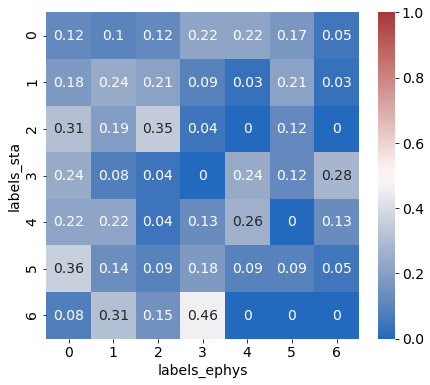

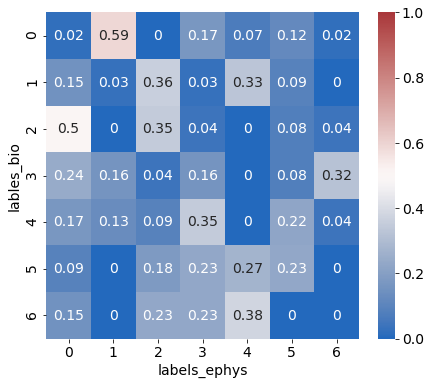

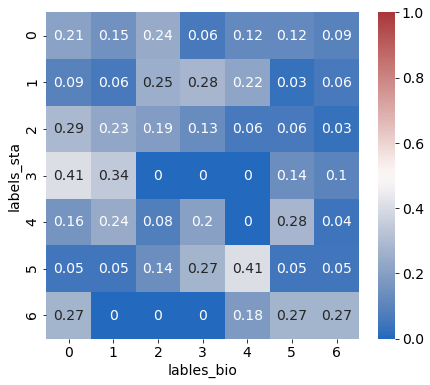

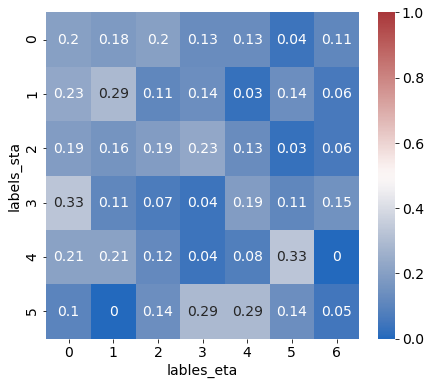

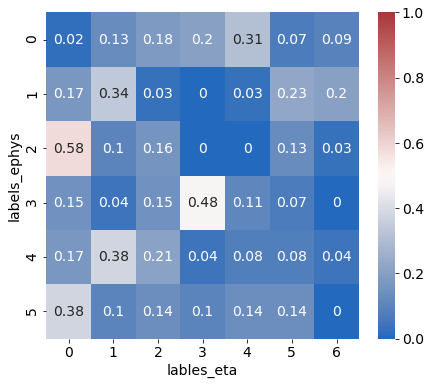

In [ ]:
from plot_utils import * 

conf_df_exc_ephys = ephys_exc[ephys_exc.exp_name.isin(set(df_biophys_exc.exp_name))]
conf_df_exc_ephys =conf_df_exc_ephys.drop_duplicates('exp_name')
conf_df_exc_sta = df_sta_acsf_exc[df_sta_acsf_exc.exp_name.isin(set(df_biophys_exc.exp_name))]
conf_df_exc_bio = df_biophys_exc.drop_duplicates('exp_name')
conf_df_exc_eta = df_biophys_exc.drop_duplicates('exp_name')

plt.rcParams['font.size']=14
return_confusion_matrix_temp(conf_df_exc_ephys, conf_df_exc_sta,  'labels_ephys','labels_sta'  ,palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'exc_ephys_sta.pdf')
return_confusion_matrix_temp(conf_df_exc_ephys, conf_df_exc_bio,  'labels_ephys','lables_bio'  ,palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'exc_ephys_bio.pdf')
return_confusion_matrix_temp(conf_df_exc_bio  , conf_df_exc_sta,  'lables_bio'  ,'labels_sta'  ,palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'exc_bio_sta.pdf')
return_confusion_matrix_temp(conf_df_exc_eta  , conf_df_exc_sta,  'lables_eta'  ,'labels_sta'  ,palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'exc_eta_sta.pdf')
return_confusion_matrix_temp(conf_df_exc_eta  , conf_df_exc_ephys,'lables_eta'  ,'labels_ephys',palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'exc_eta_ephys.pdf')


In [ ]:
all = np.concatenate((np.concatenate((conf_df_exc_bio[cols_bio].to_numpy(),conf_df_exc_ephys[cols].to_numpy()),axis=1),np.vstack(conf_df_exc_sta['sta'])),axis=1)


(183, 2027)

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


7


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


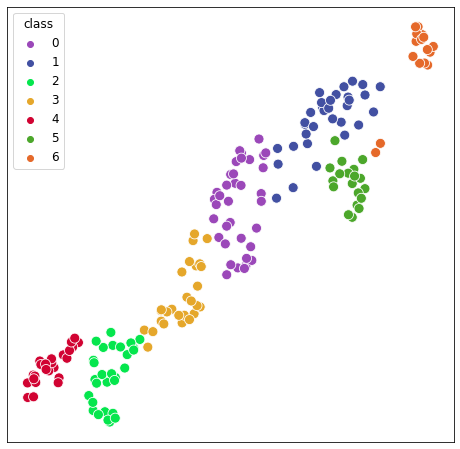

In [ ]:
waves = normalize(all,axis=0)

labels_wave,mapper,reducer = plot_UMAP_clusters_single(waves,
                          20,
                          0.1,
                          random_state =42,
                          res_louvain = 1.,
                          c_list =coherence_colors,
                          norm=False,
                          save=False,
                          savepath = savepath+'wave_cluster.pdf',
                          size=100
                          )

In [ ]:
conf_df_exc_bio

np.concatenate((conf_df_exc_bio.to_numpy(),conf_df_exc_ephys.to_numpy()),axis=0)

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 17 and the array at index 1 has size 28

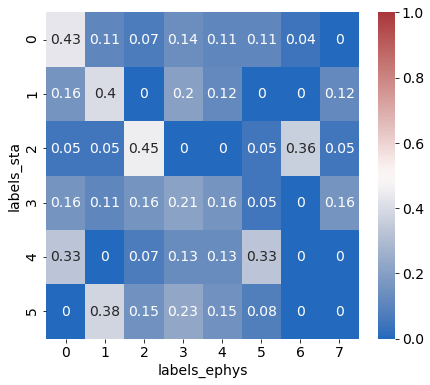

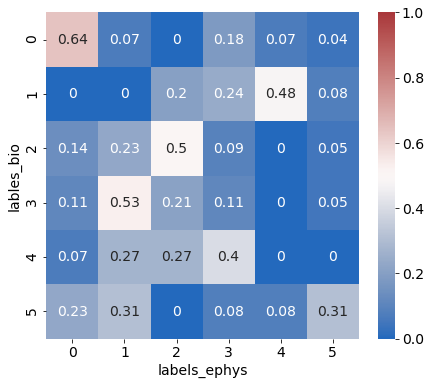

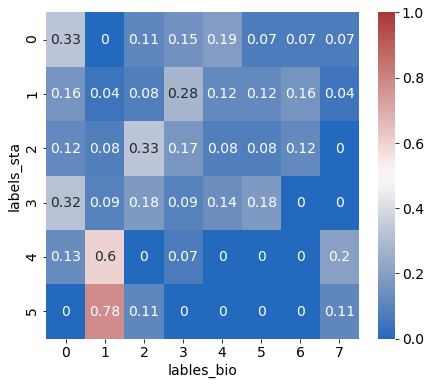

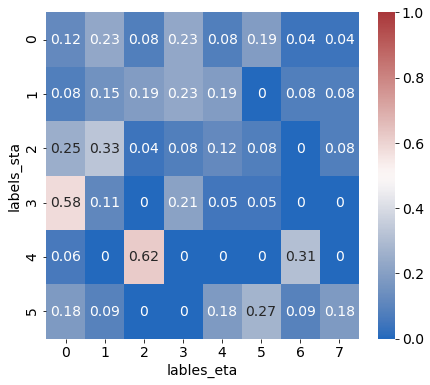

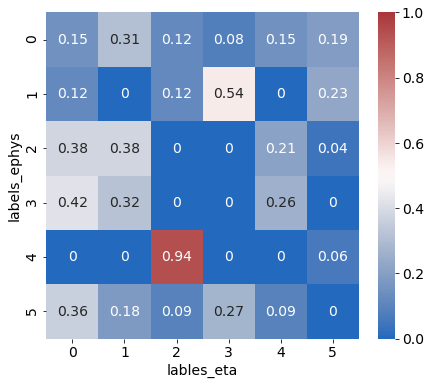

In [ ]:
exps_in_common =   (set(ephys_inh.exp_name) & set(df_sta_acsf_inh.exp_name)) & set(df_biophys_inh.exp_name) 
plt.rcParams['font.size']=14

conf_df_inh_ephys = ephys_inh[ephys_inh.exp_name.isin(exps_in_common)]
conf_df_inh_sta = df_sta_acsf_inh[df_sta_acsf_inh.exp_name.isin(exps_in_common)]
conf_df_inh_sta = conf_df_inh_sta.drop_duplicates('exp_name')
conf_df_inh_bio = df_biophys_inh[df_biophys_inh.exp_name.isin(exps_in_common)]
conf_df_inh_eta = df_biophys_inh[df_biophys_inh.exp_name.isin(exps_in_common)]

return_confusion_matrix_temp(conf_df_inh_ephys, conf_df_inh_sta, 'labels_ephys','labels_sta',palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'inh_ephys_sta.pdf')
return_confusion_matrix_temp(conf_df_inh_ephys, conf_df_inh_bio, 'labels_ephys','lables_bio',palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'inh_ephys_bio.pdf')
return_confusion_matrix_temp(conf_df_inh_bio  , conf_df_inh_sta, 'lables_bio'  ,'labels_sta',palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'inh_bio_sta.pdf')
return_confusion_matrix_temp(conf_df_inh_eta  , conf_df_inh_sta,  'lables_eta'  ,'labels_sta'  ,palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'inh_eta_sta.pdf')
return_confusion_matrix_temp(conf_df_inh_eta  , conf_df_inh_ephys,'lables_eta'  ,'labels_ephys',palette='vlag',vmin=0,vmax=1,figsize=[7,6],shuffle=True,save=True,savepath=savepath+'inh_eta_ephys.pdf')


In [ ]:
conf_df_inh_bio.columns

cols_bio = ['tau_m (ms)', 'R (MOhm)', 'C (nF)', 'gl (nS)', 'El (mV)', 'Tref (ms)',
       'Vr (mV)', 'Vt* (mV)', 'DV (mV)']

In [ ]:
fig,ax = plt.subplots(figsize = [20,20],)
sns.heatmap(conf_df_inh_ephys[cols_ephys].corr(),annot=True)

NameError: name 'plt' is not defined

In [ ]:
from sklearn.cross_decomposition import CCA
y = np.vstack(conf_df_inh_sta['sta'].to_numpy())
X = np.vstack(conf_df_inh_ephys[cols_ephys].to_numpy())
cca = CCA(n_components=len(cols_ephys))
cca.fit(X, y)
CCA(n_components=1)
X_c, Y_c = cca.transform(X,y)

cca.score(X,y)

-0.7563903235647585

In [ ]:
from sklearn.cross_decomposition import CCA
X = np.vstack(conf_df_inh_sta['sta'].to_numpy())
y = np.vstack(conf_df_inh_bio[cols_bio].to_numpy())
cca = CCA(n_components=1)
cca.fit(X, y)
CCA(n_components=1)
X_c, Y_c = cca.transform(X,y)

cca.score(X,y)

0.1393384391118384

In [ ]:
from sklearn.cross_decomposition import CCA
X = np.vstack(conf_df_inh_ephys[cols_ephys].to_numpy())
y = np.vstack(conf_df_inh_bio[cols_bio].to_numpy())
cca = CCA(n_components=len(cols_bio))
cca.fit(X, y)
X_c, Y_c = cca.transform(X,y)

cca.score(X,y)

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\cross_decomposition\_pls.py:305: UserWarning: Y residual is constant at iteration 8
  warnings.warn(f"Y residual is constant at iteration {k}")


0.4509245265323294

In [ ]:
conf_df_inh_ephys_sorted = conf_df_inh_ephys.sort_values('labels_ephys')
conf_df_inh_bio_sorted = conf_df_inh_bio.sort_values('lables_bio')
conf_df_inh_sta_sorted = conf_df_inh_sta.sort_values('labels_sta')
conf_df_inh_eta_sorted = conf_df_inh_eta.sort_values('lables_eta')


conf_df_exc_ephys_sorted = conf_df_exc_ephys.sort_values('labels_ephys')
conf_df_exc_bio_sorted = conf_df_exc_bio.sort_values('lables_bio')
conf_df_exc_sta_sorted = conf_df_exc_sta.sort_values('labels_sta')
conf_df_exc_eta_sorted = conf_df_exc_eta.sort_values('lables_eta')


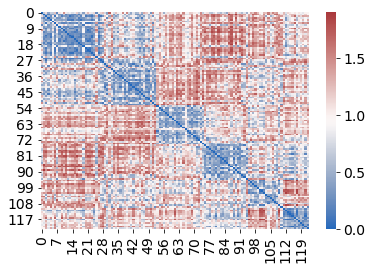

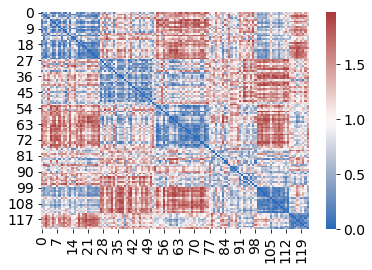

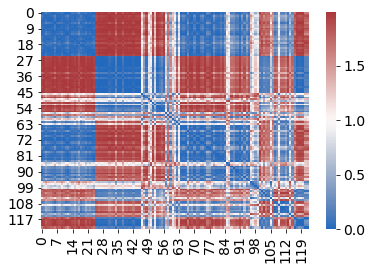

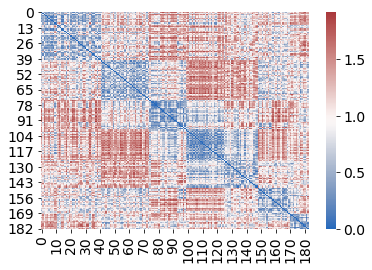

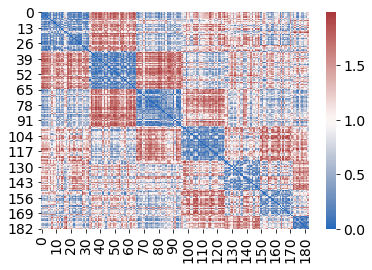

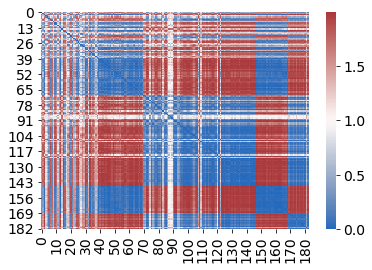

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

# Example data (replace these with your actual data)
# electrophysiological_data = 
# biophysical_data = 
# spike_triggered_average_data = 

# Step 1: Normalize the data
scaler = StandardScaler()
ephys_data_inh = scaler.fit_transform(conf_df_inh_ephys_sorted[cols])
bio_data_inh = scaler.fit_transform(conf_df_inh_bio_sorted[cols_bio])
sta_data_inh = scaler.fit_transform(np.vstack(conf_df_inh_sta_sorted['sta'].to_numpy()))

ephys_data_exc = scaler.fit_transform(conf_df_exc_ephys_sorted[cols])
bio_data_exc = scaler.fit_transform(conf_df_exc_bio_sorted[cols_bio])
sta_data_exc = scaler.fit_transform(np.vstack(conf_df_exc_sta_sorted['sta'].to_numpy()))


# Step 2: Calculate pairwise distances within each modality
def calculate_pairwise_distances(data, metric='cosine'):
    return squareform(pdist(data, metric)) , pdist(data, metric) 

electrophysiological_distances_mat_inh , electrophysiological_distances_inh = calculate_pairwise_distances(ephys_data_inh)
biophysical_distances_mat_inh,biophysical_distances_inh  = calculate_pairwise_distances(bio_data_inh)
sta_distance_mat_inh,sta_distance_inh = calculate_pairwise_distances(sta_data_inh)

electrophysiological_distances_mat_exc , electrophysiological_distances_exc = calculate_pairwise_distances(ephys_data_exc)
biophysical_distances_mat_exc,biophysical_distances_exc  = calculate_pairwise_distances(bio_data_exc)
sta_distance_mat_exc,sta_distance_exc = calculate_pairwise_distances(sta_data_exc)


sns.heatmap(electrophysiological_distances_mat_inh,cmap='vlag')
plt.show()
sns.heatmap(biophysical_distances_mat_inh,cmap='vlag')
plt.show()
sns.heatmap(sta_distance_mat_inh,cmap='vlag')
plt.show()


sns.heatmap(electrophysiological_distances_mat_exc,cmap='vlag')
plt.show()
sns.heatmap(biophysical_distances_mat_exc,cmap='vlag')
plt.show()
sns.heatmap(sta_distance_mat_exc,cmap='vlag')
plt.show()


In [ ]:
from sklearn.cross_decomposition import CCA

# Assuming you want to compare 22D vs 2000D and 22D vs 8D
cca = CCA(n_components=2)
cca_22d_2000d = cca.fit(ephys_data, sta_data).transform(ephys_data, sta_data)
cca_22d_8d = cca.fit(ephys_data, bio_data).transform(ephys_data, bio_data)

# cca_22d_2000d and cca_22d_8d now contain the transformed data for comparison


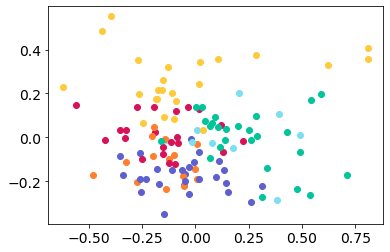

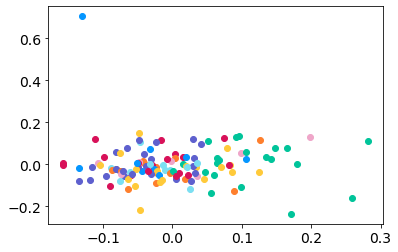

In [ ]:
# plt.scatter(cca_22d_8d[0],cca_22d_8d[1])
for i,j in enumerate(conf_df_inh_bio.lables_bio):
    plt.scatter(cca_22d_8d[0][i,0],cca_22d_8d[0][i,1],c=CUSTOM_PAL_SORT_3[j])
plt.show()
for i,j in enumerate(conf_df_inh_sta.labels_sta):    
    plt.scatter(cca_22d_2000d[0][i,0],cca_22d_2000d[0][i,1],c=CUSTOM_PAL_SORT_3[j])
plt.show()    

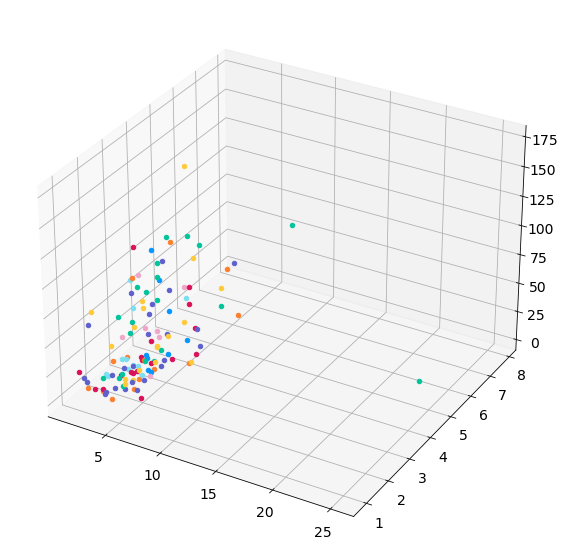

In [ ]:
ax = plt.figure(figsize=[10,10]).add_subplot(projection='3d')
for i,j in enumerate(conf_df_inh_sta.labels_sta):
    ax.scatter(electrophysiological_distances[i] ,biophysical_distances[i] ,sta_distance[i],c=CUSTOM_PAL_SORT_3[j])

In [ ]:
label_ephys_inh = list(conf_df_inh_ephys.labels_ephys)
label_sta_inh = list(conf_df_inh_sta.labels_sta)
label_bio_inh = list(conf_df_inh_bio.lables_bio)

df_labels_inh = pd.DataFrame({'label_ephys':list(label_ephys_inh),
                              'label_sta' :  list(label_sta_inh),
                              'label_bio' :  list(label_bio_inh),
                              'exp_name':    list(conf_df_inh_bio.exp_name)})
    

label_ephys_exc = list(conf_df_exc_ephys.labels_ephys)
label_sta_exc = list(conf_df_exc_sta.labels_sta)
label_bio_exc = list(conf_df_exc_bio.lables_bio)

df_labels_exc = pd.DataFrame({'label_ephys':list(label_ephys_exc),
                              'label_sta' :  list(label_sta_exc),
                              'label_bio' :  list(label_bio_exc),
                              'exp_name':    list(conf_df_exc_bio.exp_name)})
    


<Axes: >

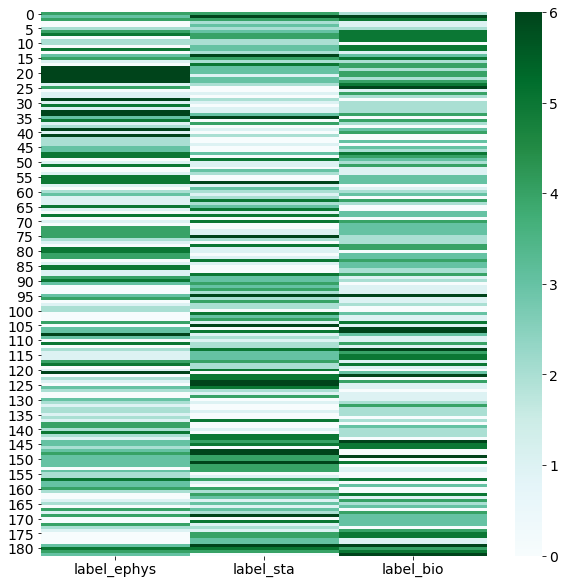

In [ ]:
plt.figure(figsize=[10,10])
sns.heatmap(df_labels_exc[df_labels_exc.columns[:-1]],cmap='BuGn')

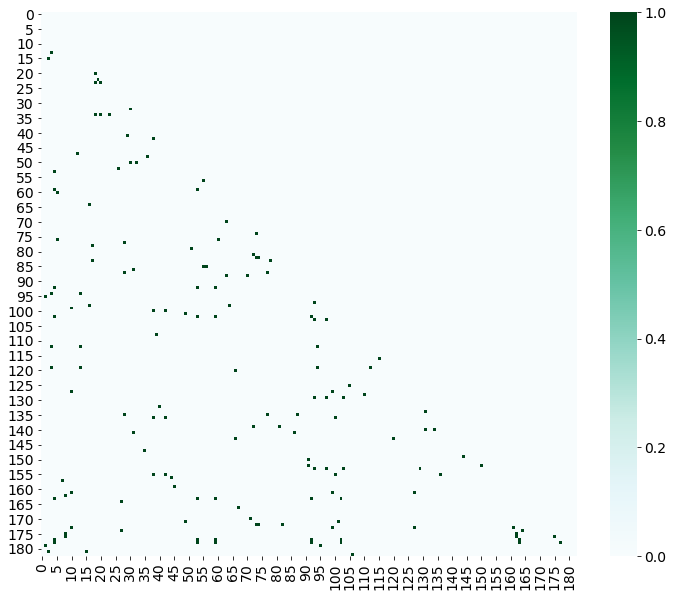

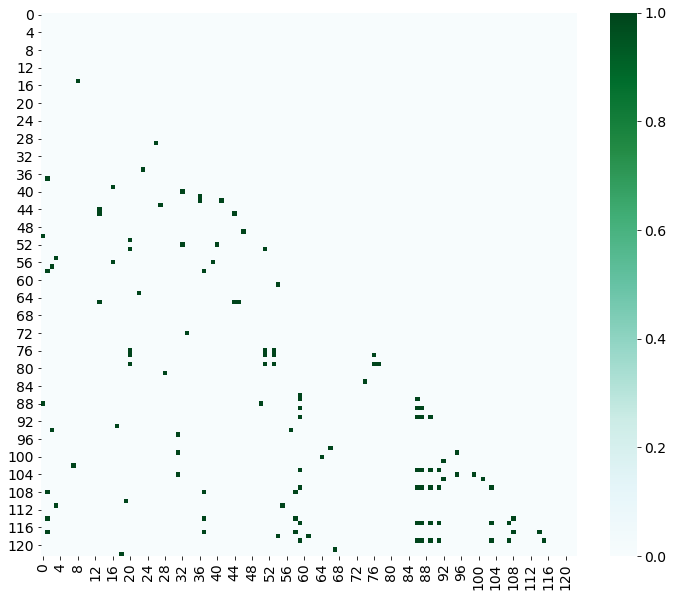

In [ ]:
def co_association_matrix(labels):
    n = len(labels)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i>j:
                if i!=j:
                    if labels[i] == labels[j]:
                        matrix[i, j] = 1
    return matrix
mat1 = co_association_matrix(df_labels_exc['label_ephys'])
mat2 = co_association_matrix(df_labels_exc['label_bio'])
mat3 = co_association_matrix( df_labels_exc['label_sta'])
mat_exc = np.int32((mat1+mat2+mat3)/3)

plt.figure(figsize=[12,10])

sns.heatmap(mat_exc,cmap='BuGn')
plt.show()

mat1 = co_association_matrix(df_labels_inh['label_ephys'])
mat2 = co_association_matrix(df_labels_inh['label_bio'])
mat3 = co_association_matrix( df_labels_inh['label_sta'])
mat_inh = np.int32((mat1+mat2+mat3)/3)

plt.figure(figsize=[12,10])

sns.heatmap(mat_inh,cmap='BuGn')
plt.show()

In [ ]:
np.sum(mat_exc,axis=1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 2, 0, 1, 1, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 1, 2,
       2, 0, 0, 0, 3, 0, 2, 1, 0, 1, 2, 1, 2, 1, 4, 2, 0, 0, 0, 0, 1, 0,
       0, 0, 3, 0, 0, 0, 1, 0, 0, 4, 1, 0, 0, 0, 0, 1, 0, 2, 1, 3, 0, 0,
       1, 0, 1, 3, 3, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0, 1, 0, 1, 1, 0, 2, 4,
       0, 4, 1, 1, 0, 1, 0, 3, 1, 5, 1, 0, 1, 0, 0, 0, 1, 2, 3, 4, 2, 2,
       3, 6, 7, 2, 0, 2, 1])

<Axes: >

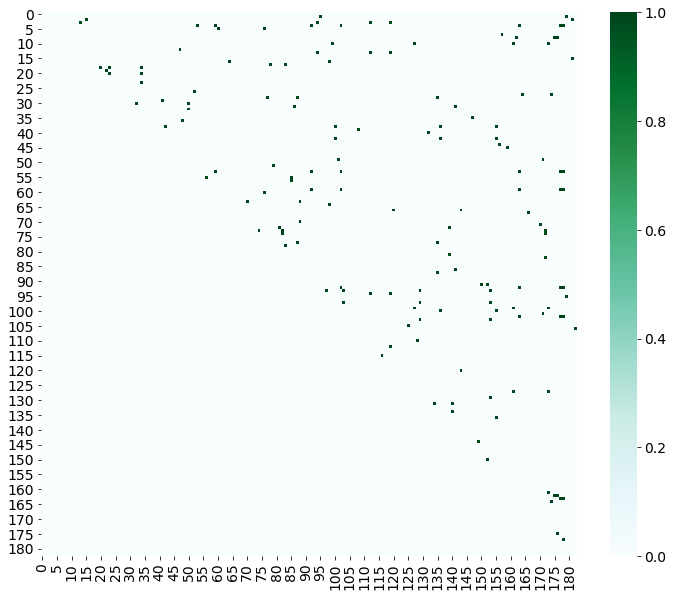

In [ ]:
plt.figure(figsize=[12,10])
sns.heatmap(consensus,cmap='BuGn')

127

In [ ]:
row_3,col_3 =np.where(consensus==3)
row_2,col_2 =np.where(consensus==2)

exps_consensus_3 = set(np.concatenate([df_labels_exc.exp_name[row_3],df_labels_exc.exp_name[col_3]]))
exps_consensus_2 = set(np.concatenate([df_labels_exc.exp_name[row_2],df_labels_exc.exp_name[col_2]]))

print(len(exps_consensus_3)/len(df_labels_exc))
print(len(exps_consensus_2)/len(df_labels_exc))


0.6939890710382514
0.9289617486338798


In [ ]:
def mahalanobis(x=None, data=None, cov=None):
    x = np.array(x,dtype=np.float32)
    x_mu = x - np.mean(x,axis=0)
    if not cov:
        cov = np.cov(x.T)
    inv_covmat = np.linalg.inv(cov)
    left = np.dot(x_mu, inv_covmat)
    mahal = np.dot(left, x_mu.T)
    return mahal.diagonal()


cols_ephys = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr',
       'time_to_first_spike', 'mean_isi', 'median_isi', 'max_isi', 'min_isi',
       'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
       'mean_width', 'median_width', 'max_width', 'min_width',
       'mean_amplitude', 'median_amplitude', 'min_amplitude', 'max_amplitude',]




exps_in_common =   (set(ephys_inh.exp_name) & set(df_sta_acsf_inh.exp_name)) & set(df_biophys_inh.exp_name) 

conf_df_inh_ephys = ephys_inh[ephys_inh.exp_name.isin(exps_in_common)]
conf_df_inh_sta = df_sta_acsf_inh[df_sta_acsf_inh.exp_name.isin(exps_in_common)]
conf_df_inh_sta = conf_df_inh_sta.drop_duplicates('exp_name')
conf_df_inh_bio = df_biophys_inh[df_biophys_inh.exp_name.isin(exps_in_common)]

m_dist_ephys  = mahalanobis(x= conf_df_inh_ephys[cols_ephys].values,data = conf_df_inh_ephys)
m_dist_sta    = mahalanobis(x= np.vstack(conf_df_inh_sta['sta'].values),data = conf_df_inh_sta)
m_dist_bio    = mahalanobis(x= np.vstack(conf_df_inh_bio[cols_bio].values),data = conf_df_inh_bio)



conf_df_inh_ephys['m_dist'] = m_dist_ephys

conf_df_inh_sta['m_dist'] = m_dist_sta

conf_df_inh_bio['m_dist'] = m_dist_bio


<ipython-input-237-1207e45187db>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  conf_df_inh_ephys['m_dist'] = m_dist_ephys
<ipython-input-237-1207e45187db>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  conf_df_inh_bio['m_dist'] = m_dist_bio


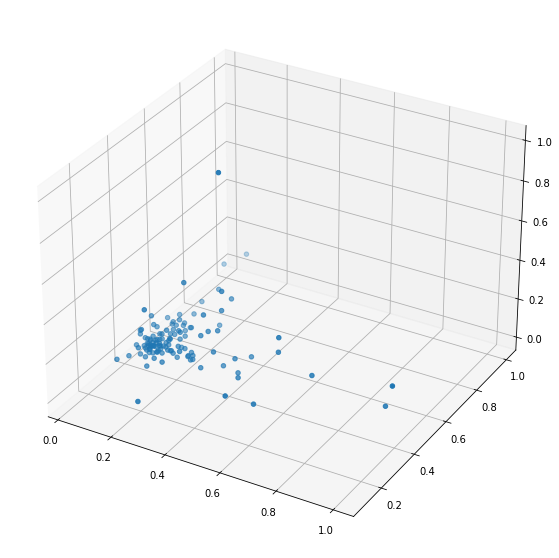

In [ ]:
ax = plt.figure(figsize=[10,10]).add_subplot(projection='3d')
ax.scatter(conf_df_inh_ephys['m_dist']/np.max(conf_df_inh_ephys['m_dist']) ,conf_df_inh_sta['m_dist']/np.max(conf_df_inh_sta['m_dist']),conf_df_inh_bio['m_dist']/np.max(conf_df_inh_bio['m_dist']))

<Axes: >

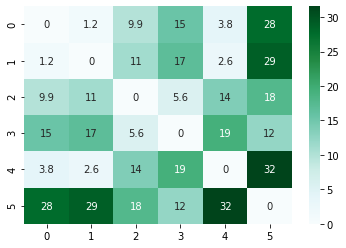

In [ ]:
centers = []
for i in set(ephys_exc.labels_ephys):

    centers.append(np.mean(ephys_exc[ephys_exc.labels_ephys==i]['m_dist']))


inter_clus_dist = np.zeros((len(centers),len(centers)))
for i in range(len(centers)):
    for j in range(len(centers)):
        if i!=j:
            inter_clus_dist[i,j] = np.abs(centers[i]-centers[j])

inter_clus_dist = np.zeros((len(centers),len(centers)))
for i in range(len(centers)):
    for j in range(len(centers)):
        if i!=j:
            inter_clus_dist[i,j] = np.abs(centers[i]-centers[j])


sns.heatmap(inter_clus_dist,cmap='BuGn',annot=True)

<Axes: >

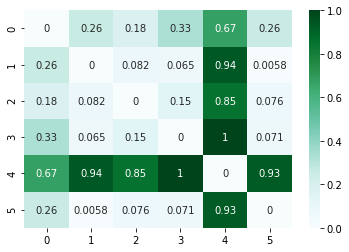

In [ ]:
centers = []
for i in set(df_sta_acsf_exc.labels_sta):

    centers.append(np.mean(df_sta_acsf_exc[df_sta_acsf_exc.labels_sta==i]['m_dist']))


inter_clus_dist = np.zeros((len(centers),len(centers)))
for i in range(len(centers)):
    for j in range(len(centers)):
        if i!=j:
            inter_clus_dist[i,j] = np.abs(centers[i]-centers[j])

inter_clus_dist = np.zeros((len(centers),len(centers)))
for i in range(len(centers)):
    for j in range(len(centers)):
        if i!=j:
            inter_clus_dist[i,j] = np.abs(centers[i]-centers[j])


sns.heatmap(inter_clus_dist/np.max(inter_clus_dist),cmap='BuGn',annot=True)

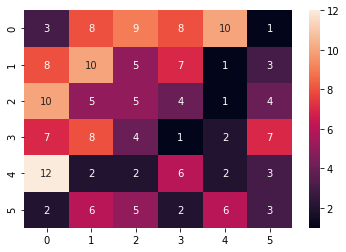

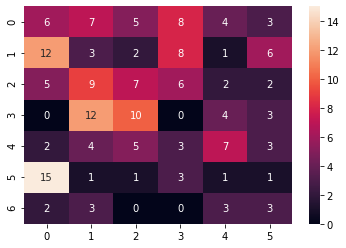

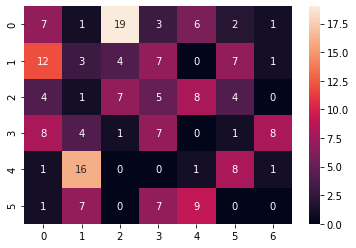

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
sns.heatmap(contingency_matrix(label_ephys_exc,label_sta_exc),annot=True)
plt.show()
sns.heatmap(contingency_matrix(label_bio_exc,label_sta_exc),annot=True)
plt.show()
sns.heatmap(contingency_matrix(label_ephys_exc,label_bio_exc),annot=True)
plt.show()

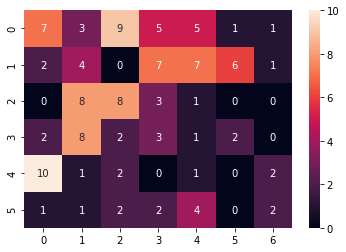

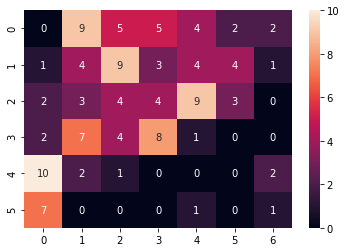

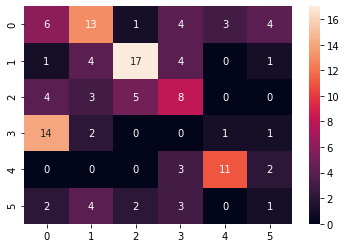

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
sns.heatmap(contingency_matrix(label_ephys_inh,label_sta_inh),annot=True)
plt.show()
sns.heatmap(contingency_matrix(label_bio_inh,label_sta_inh),annot=True)
plt.show()
sns.heatmap(contingency_matrix(label_ephys_inh,label_bio_inh),annot=True)
plt.show()

In [ ]:

exps_in_common =   (set(ephys_inh.exp_name) & set(df_sta_acsf_inh.exp_name)) & set(df_biophys_inh.exp_name) 

conf_df_inh_ephys = ephys_inh[ephys_inh.exp_name.isin(exps_in_common)]
conf_df_inh_sta = df_sta_acsf_inh[df_sta_acsf_inh.exp_name.isin(exps_in_common)]
conf_df_inh_sta = conf_df_inh_sta.drop_duplicates('exp_name')
conf_df_inh_bio = df_biophys_inh[df_biophys_inh.exp_name.isin(exps_in_common)]
conf_df_inh_eta = df_biophys_inh[df_biophys_inh.exp_name.isin(exps_in_common)]

# return_confusion_matrix(conf_df_inh_ephys, conf_df_inh_sta, 'labels_ephys','labels_sta',shuffle=True)
# return_confusion_matrix(conf_df_inh_ephys, conf_df_inh_bio, 'labels_ephys','lables_bio',shuffle=True)
# return_confusion_matrix(conf_df_inh_bio  , conf_df_inh_sta, 'lables_bio'  ,'labels_sta',shuffle=True)

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

print('Inh: Rand Score        Mututal info score')
print((adjusted_rand_score(conf_df_inh_ephys.labels_ephys,conf_df_inh_sta.labels_sta) , #conf_df_inh_sta.labels_sta
adjusted_mutual_info_score(conf_df_inh_ephys.labels_ephys,conf_df_inh_sta.labels_sta)))

print((adjusted_rand_score(conf_df_inh_ephys.labels_ephys,conf_df_inh_bio.lables_bio) ,
adjusted_mutual_info_score(conf_df_inh_ephys.labels_ephys,conf_df_inh_bio.lables_bio)))


print((adjusted_rand_score(conf_df_inh_sta.labels_sta,conf_df_inh_bio.lables_bio) ,
adjusted_mutual_info_score(conf_df_inh_sta.labels_sta,conf_df_inh_bio.lables_bio)))


print((adjusted_rand_score(conf_df_inh_eta.lables_eta,conf_df_inh_sta.labels_sta) ,
adjusted_mutual_info_score(conf_df_inh_eta.lables_eta,conf_df_inh_sta.labels_sta)))


print((adjusted_rand_score(conf_df_inh_eta.lables_eta,conf_df_inh_ephys.labels_ephys) ,
adjusted_mutual_info_score(conf_df_inh_eta.lables_eta,conf_df_inh_ephys.labels_ephys)))


print('Exc: Rand Score        Mututal info score')

print((adjusted_rand_score(conf_df_exc_ephys.labels_ephys,conf_df_exc_sta.labels_sta) , #conf_df_exc_sta.labels_sta
adjusted_mutual_info_score(conf_df_exc_ephys.labels_ephys,conf_df_exc_sta.labels_sta)))

print((adjusted_rand_score(conf_df_exc_ephys.labels_ephys,conf_df_exc_bio.lables_bio) ,
adjusted_mutual_info_score(conf_df_exc_ephys.labels_ephys,conf_df_exc_bio.lables_bio)))


print((adjusted_rand_score(conf_df_exc_sta.labels_sta,conf_df_exc_bio.lables_bio) ,
adjusted_mutual_info_score(conf_df_exc_sta.labels_sta,conf_df_exc_bio.lables_bio)))

print((adjusted_rand_score(conf_df_exc_eta.lables_eta,conf_df_exc_sta.labels_sta) ,
adjusted_mutual_info_score(conf_df_exc_eta.lables_eta,conf_df_exc_sta.labels_sta)))

print((adjusted_rand_score(conf_df_exc_eta.lables_eta,conf_df_exc_ephys.labels_ephys) ,
adjusted_mutual_info_score(conf_df_exc_eta.lables_eta,conf_df_exc_ephys.labels_ephys)))




Inh: Rand Score        Mututal info score
(0.10999882939531264, 0.1681381841290732)
(0.18769956685227215, 0.22980867588550888)
(0.0645358831418919, 0.12252198998970418)
(0.090750571708019, 0.1471678691070663)
(0.18892533070740597, 0.28315271957810473)
Exc: Rand Score        Mututal info score
(0.030743181024791025, 0.07715598596661565)
(0.1616323183286777, 0.21285722931541898)
(0.05330314464249515, 0.09956571683254403)
(0.01200847924762805, 0.029888038050166328)
(0.10060498462794683, 0.14636084149674627)


<ipython-input-208-58c524f26bcd>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(bar_labels, **{'rotation':30})


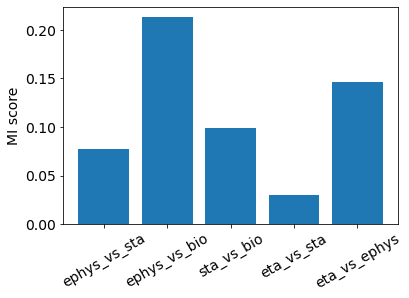

In [ ]:
y_exc = [0.1681381841290732, 0.22980867588550888, 0.12252198998970418, 0.1471678691070663, 0.28315271957810473]
y_inh = [0.0771559859666156, 0.21285722931541898, 0.09956571683254403, 0.0298880380501663, 0.14636084149674627]

fig, ax = plt.subplots()

fruits = ['ephys_vs_sta', 'ephys_vs_bio', 'sta_vs_bio', 'eta_vs_sta','etavs_ephys']
counts = y_inh
bar_labels = ['ephys_vs_sta', 'ephys_vs_bio', 'sta_vs_bio', 'eta_vs_sta','eta_vs_ephys']
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

ax.bar(fruits, counts, )
ax.set_xticklabels(bar_labels, **{'rotation':30})
ax.set_ylabel('MI score')
# ax.set_title('Fruit supply by kind and color')
# ax.legend(title='Fruit color')
# plt.savefig(savepath+'inh_labels_MI.pdf',dpi=200)
plt.show()

In [ ]:
def return_mi_rand_score(label1,label2,frac): maximum mean discrepancy
    frac = frac
    idx = list(np.random.randint(0,len(label1),int(len(label1)*frac)))
    rand_scores = [] 
    MI_scores = [] 
    for i in range(10):
        rand_scores.append(adjusted_rand_score(np.array(label1)[idx],np.array(label2)[idx]))
        MI_scores.append(adjusted_mutual_info_score(np.array(label1)[idx],np.array(label2)[idx]))
    return rand_scores,MI_scores


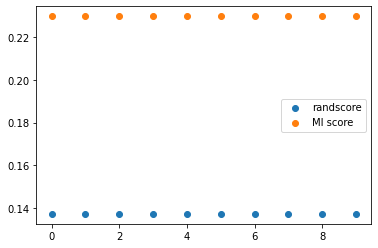

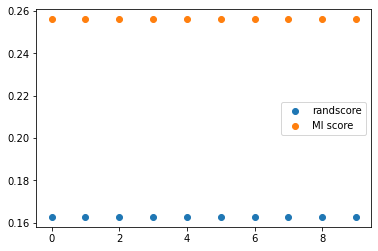

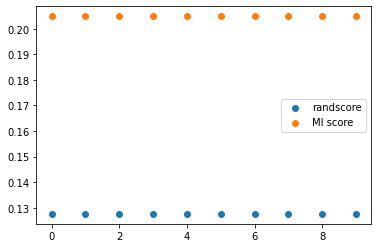

In [ ]:
randscore,miscore = return_mi_rand_score(conf_df_inh_ephys.labels_ephys,conf_df_inh_sta.labels_sta,frac=0.9)
plt.scatter(np.arange(len(randscore)),randscore,label='randscore')
plt.scatter(np.arange(len(miscore)),miscore,label='MI score')
plt.legend()
plt.show()

randscore,miscore = return_mi_rand_score(conf_df_inh_ephys.labels_ephys,conf_df_inh_bio.lables_bio,frac=0.9)
plt.scatter(np.arange(len(randscore)),randscore,label='randscore')
plt.scatter(np.arange(len(miscore)),miscore,label='MI score')
plt.legend()
plt.show()

randscore,miscore = return_mi_rand_score(conf_df_inh_bio.lables_bio,conf_df_inh_sta.labels_sta,frac=0.9)
plt.scatter(np.arange(len(randscore)),randscore,label='randscore')
plt.scatter(np.arange(len(miscore)),miscore,label='MI score')
plt.legend()
plt.show()

In [ ]:
from xg_boost_classifier import * 

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mean accuracy 80.51421166552745


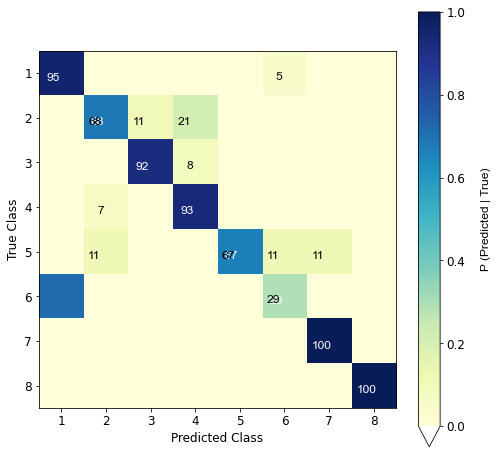

In [ ]:
_= return_xg_boost_trees_classification(data_wave_FN_acsf['waveform'],data_wave_FN_acsf.labels_wave)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mean accuracy 94.28571428571429
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mean accuracy 82.83013283013284


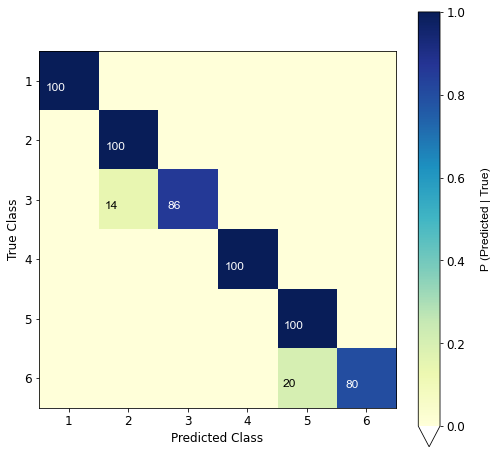

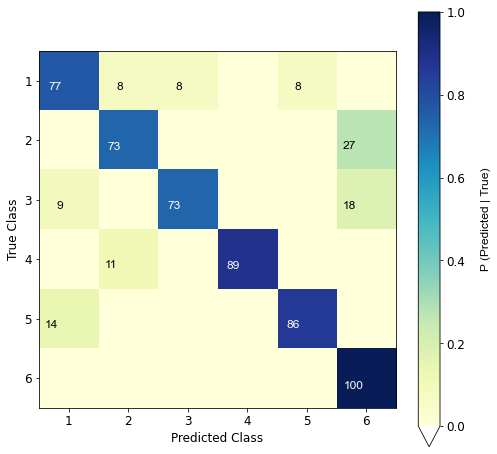

In [ ]:
_=return_xg_boost_trees_classification(conf_df_inh_ephys[conf_df_inh_ephys.columns[:-6]].to_numpy(),conf_df_inh_ephys.labels_ephys)
_=return_xg_boost_trees_classification(conf_df_exc_ephys[conf_df_exc_ephys.columns[:-6]].to_numpy(),conf_df_exc_ephys.labels_ephys)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Mean accuracy 71.42857142857143
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mean accuracy 89.36507936507935


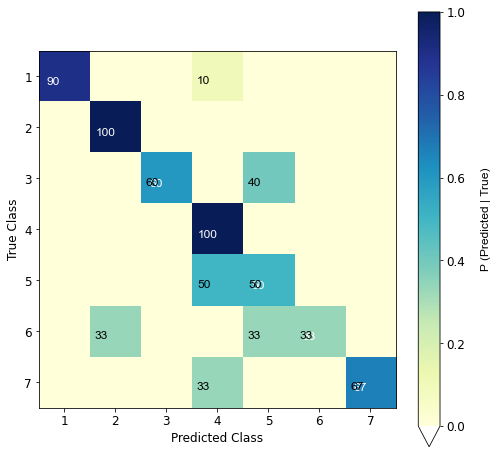

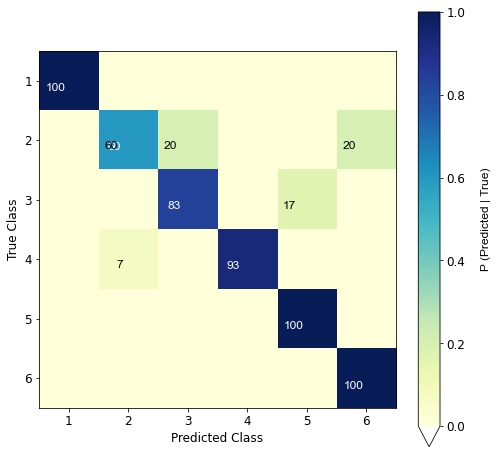

In [ ]:
_=return_xg_boost_trees_classification(conf_df_inh_sta['sta'].to_numpy(),conf_df_inh_sta.labels_sta)
_=return_xg_boost_trees_classification(conf_df_exc_sta['sta'].to_numpy(),conf_df_exc_sta.labels_sta)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mean accuracy 71.13095238095237
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mean accuracy 81.75824175824175


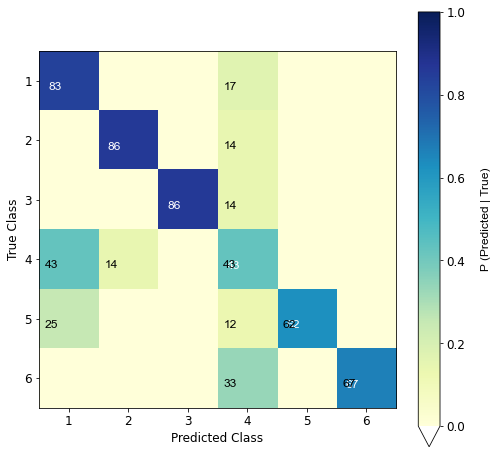

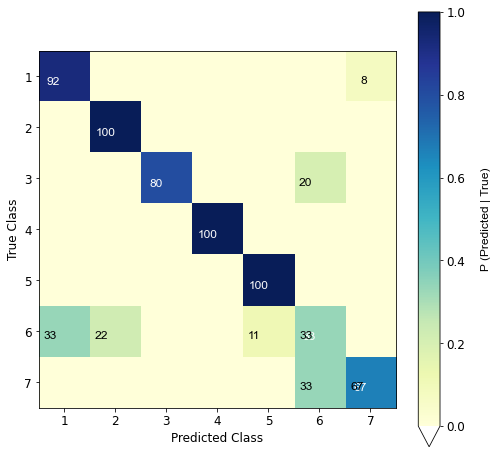

In [ ]:

cols_bio = ['C (nF):', 'gl (nS):', 'El (mV):','Vr (mV):', 'Vt* (mV):', 'DV (mV):']

_ = return_xg_boost_trees_classification(conf_df_inh_bio[cols_bio].to_numpy(),conf_df_inh_bio.lables_bio)
_ = return_xg_boost_trees_classification(conf_df_exc_bio[cols_bio].to_numpy(),conf_df_exc_bio.lables_bio)


## CCA

In [ ]:
import numpy as np
from sklearn.cross_decomposition import CCA
from scipy.stats import zscore
from sklearn.model_selection import train_test_split


X_ephys = normalize(conf_df_inh_ephys[conf_df_inh_ephys.columns[:-6]].to_numpy(),axis=0)
X_sta = np.vstack(conf_df_inh_sta['sta'].to_numpy())
X_bio = normalize(np.vstack(conf_df_inh_bio[cols_bio].to_numpy()),axis=0)

X_train_ephys, X_test_ephys, y_train_sta, y_test_sta = train_test_split(X_ephys, X_sta, test_size=0.3, random_state=42)
X_train_ephys, X_test_ephys, y_train_bio, y_test_bio = train_test_split(X_ephys, X_bio, test_size=0.3, random_state=42)
X_train_bio, X_test_bio, y_train_sta, y_test_sta = train_test_split(X_bio, X_sta, test_size=0.3, random_state=42)


def perform_CCA(X,y,n_components=10):
    ca = CCA(n_components=n_components)
    ca.fit(X, y)
    X_c, Y_c = ca.transform(X,y)
    x_weights = ca.x_weights_
    score = ca.score(X , y)
    print(score)
    return X_c,Y_c,ca


_,_,ca_all_E_S = perform_CCA(X_ephys,X_sta,n_components=22)
_,_,ca_all_E_B = perform_CCA(X_ephys,X_bio,n_components=6)
_,_,ca_all_S_B = perform_CCA(X_bio,X_sta,n_components=6)


-1.1226876039749683
0.3881159193642692
-50.20246564725727


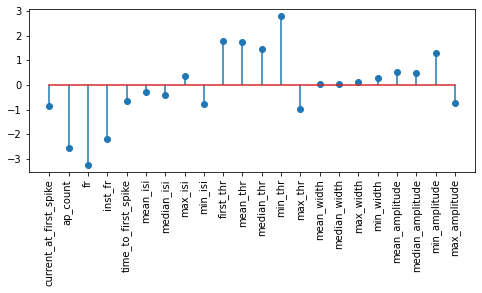

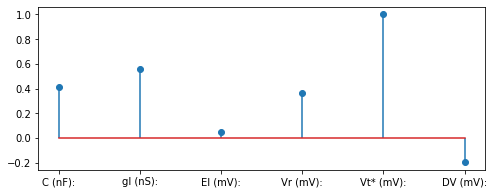

In [ ]:
fig,ax1 = plt.subplots(1, figsize=[8,3])
fig,ax2 = plt.subplots(1, figsize=[8,3])

ax1.stem(ca_all_E_B.x_loadings_[:,0])
ax1.set_xticks(np.arange(0,22),conf_df_inh_ephys.columns[:-6],rotation=90)
# ax1.set_xticks([])

ax2.stem(ca_all_E_B.y_loadings_[:,0])
ax2.set_xticks(np.arange(0,6),cols_bio[:])
# ax2.tight_layout=True
plt.show()
